# Spectral Feature Difficulty Analysis — DDP runs (`data/new_experiments_ddp`)
Companion to `feature_difficulty_analysis_ddp.ipynb`. That notebook asked which **molecular** features make test
compounds hard to elucidate; this one asks the same question of the **input EI spectra**.

> Generated from `spectral_difficulty_analysis.ipynb` by a build script (rules + DDP-specific cells). Edit the source
> notebook and rebuild rather than editing this one by hand.

Differences from the non-DDP notebook:

* **Kernel.** The prediction pickles are written on LUMI with RDKit 2026.03 / NumPy 2.x — run this notebook in the
  **`diffms_lumi`** env (`envs/build_local_env.sh`).
* **Data layout.** `data/new_experiments_ddp/expN/expN_{pred,true}_r<rank>_<batch>.pkl`, one pickle per rank and
  per-rank batch. Shards are re-interleaved into `DistributedSampler` order and the padding duplicates are dropped
  (see `feature_difficulty_analysis_ddp.ipynb` for details).
* **Outcomes.** 100 candidates per molecule, ranked by occurrence exactly like `K_ACC_Collection.update()`. Each
  molecule stores the rank of the true structure, so top-k hits are available for any k; `TOP_K` in the setup cell
  picks the hit/miss split used throughout (every "top-10" of the original becomes top-`TOP_K`). Top-1 Tanimoto uses
  the top-*ranked* candidate (canonicalised from its InChI), matching `tanimoto_at_1` logged by the test step.
* **Same test set.** All four DDP experiments are evaluated on the same, identically ordered test set (checked in
  Section 1), so the spectrum linkage, spectral and ATMOMACCS features, PCA and spectral clusters are identical across
  experiments; only the outcomes differ.
* The prediction shards only store `(pred_mols, true_mol)`, so each test molecule is linked back to its NEIMS spectrum
  **by structure** (canonical SMILES, falling back to InChIKey for tautomers such as amide ↔ imidic acid that change
  during graph reconstruction). The spectrum pickle is the same as in the non-DDP notebook.
* Hit-dependent figures and CSVs carry `_top{TOP_K}` in their filenames.

Sections
1. Load predictions and per-molecule outcomes
2. Link test molecules to spectra
3. Interpretable spectral features
4. Hit vs miss distributions
5. Cross-experiment effect-size summary
6. Top-1 Tanimoto correlations
7. Are the spectral effects just molecular size or structure? (partial correlations, MW-stratified hit rates)
8. Predictive value: molecular (RDKit descriptors + ATMOMACCS) vs spectral vs combined features
9. Spectral space: PCA + k-means of binned spectra
10. Spectral novelty and ambiguity: nearest neighbours in the training library
11. Example spectra: hits vs misses of similar mass
12. Save results
13. Findings

In [1]:
import sys, os, re, time, warnings, pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, DataStructs, rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from scipy import stats

sys.path.insert(0, '..')
sys.path.insert(0, '../src')
from src.utils import is_valid, canonical_mol_from_inchi
from ATMOMACCS_no_binary import pyGenATMOKeys, pyGenMACCSKeys

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

EXP_BASE  = 'data/new_experiments_ddp_fixed'
DATA_DIR  = '../data/neims/gecko_new_mixed_augment_atmomaccs_test/mist_inputs'
SPEC_PKL  = f'{DATA_DIR}/df_neims_gecko_new_mixed_augment_atmomaccs_test_3_9_22.pkl'
SPLIT_TSV = f'{DATA_DIR}/split_random_guarded.tsv'   # split used by the experiment configs
OUT_DIR   = 'spectral_difficulty_analysis_ddp'
PLOT_DPI  = 150
HIT_COLOR, MISS_COLOR = '#4a90d9', '#e05c5c'
os.makedirs(OUT_DIR, exist_ok=True)

# The one knob: every hit/miss split, plot title and hit-dependent output filename uses TOP_K.
# Outcomes are cached as the rank of the true structure, so changing TOP_K needs no reload.
TOP_K = 10
HIT   = f'hit_top{TOP_K}'
HR    = f'hit_rate_top{TOP_K}'
K_REPORT = sorted({1, 10, TOP_K})          # hit columns added to every per-molecule table

# Name prefixes in the collated spectrum pickle
TEST_PREFIXES = ['wang', 'ferraz-caetano', 'li', 'kruger-confined']   # experimental-structure test sets
REF_PREFIXES  = ['gecko_new', 'mix_aug']                              # training libraries

fs = 11
plt.rcParams.update({'font.size': fs})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

# Morgan r=2, 2048 bits — same bits as the legacy Morgan bit-vector call in src/metrics (K_TanimotoSimilarity)
morgan_fp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048).GetFingerprint

def exp_tag(exp_name):
    return exp_name.split(':')[0]

import rdkit
print(f'Setup complete.  rdkit {rdkit.__version__}, numpy {np.__version__}   TOP_K = {TOP_K}')

/root/anaconda3/envs/diffms_lumi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.  rdkit 2026.03.3, numpy 2.1.3   TOP_K = 10


## 1. Load experiment predictions and per-molecule outcomes
Same DDP loading and scoring logic as `feature_difficulty_analysis_ddp.ipynb`: valid candidates → InChI → ranked by
generation count. Candidates are discarded right after scoring (100 candidate Mols × 7.5k molecules × 4 experiments
does not fit in memory); the per-molecule outcomes are cached in `OUT_DIR`. Scoring takes ~10 minutes without the cache.

`true_rank` is the 1-based position of the true InChI in the ranking (`inf` if never generated), so
`hit_top{k} = true_rank <= k`.

In [2]:
_PRED_RE = re.compile(r'^(?P<prefix>.+)_r(?P<rank>\d+)_(?P<batch>\d+)\.pkl$')

def score_molecule(pred_mols, true_mol):
    """Rank of the true structure among count-ranked valid candidates, and top-1 Tanimoto (tanimoto_at_1)."""
    true_inchi = Chem.MolToInchi(true_mol)
    inchis = [Chem.MolToInchi(mol) for mol in pred_mols if is_valid(mol)]
    ranked = [inchi for inchi, _ in Counter(inchis).most_common()]
    true_rank = ranked.index(true_inchi) + 1 if true_inchi in ranked else np.inf
    tan = 0.0
    if ranked:
        try:
            tan = DataStructs.TanimotoSimilarity(morgan_fp(canonical_mol_from_inchi(ranked[0])), morgan_fp(true_mol))
        except Exception:
            pass
    return true_inchi, true_rank, tan

def load_ddp_outcomes(exp, base=EXP_BASE):
    """Score every rank/batch shard of a DDP run; return per-molecule outcomes in DistributedSampler order."""
    d = os.path.join(base, exp)
    pred_prefix, true_prefix = f'{exp}_pred', f'{exp}_true'
    shards = {}   # rank -> {batch: filename}
    for f in os.listdir(d):
        m = _PRED_RE.match(f)
        if m and m.group('prefix') == pred_prefix:
            shards.setdefault(int(m.group('rank')), {})[int(m.group('batch'))] = f
    if not shards:
        raise FileNotFoundError(f'No {pred_prefix}_r*_*.pkl shards in {d}')
    world = len(shards)
    if sorted(shards) != list(range(world)):
        raise ValueError(f'Ranks are not contiguous 0..{world-1}: {sorted(shards)}')

    t0 = time.time()
    per_rank = {}
    for rank in sorted(shards):
        rows = []
        for b in sorted(shards[rank]):
            pf = shards[rank][b]
            with open(os.path.join(d, pf), 'rb') as fh:
                preds = pkl.load(fh)
            with open(os.path.join(d, pf.replace(pred_prefix, true_prefix, 1)), 'rb') as fh:
                trues = pkl.load(fh)
            if len(preds) != len(trues):
                raise ValueError(f'{pf}: {len(preds)} preds vs {len(trues)} trues')
            for p, t in zip(preds, trues):
                if t is None:   # skipped by the test-step metrics too; kept here so the interleaving stays aligned
                    rows.append({'true_inchi': None})
                    continue
                true_inchi, true_rank, tan = score_molecule(p, t)
                rows.append({'true_smiles': Chem.MolToSmiles(t), 'true_inchikey': Chem.MolToInchiKey(t),
                             'true_inchi': true_inchi, 'true_rank': true_rank, 'tanimoto_top1': tan,
                             'n_generated': len(p)})
            del preds, trues
        per_rank[rank] = rows
        if (rank + 1) % 8 == 0:
            print(f'  {exp}: ranks 0-{rank} scored  ({time.time()-t0:.0f}s)', flush=True)

    # rank r's j-th sample is global position r + world*j
    lens = {len(v) for v in per_rank.values()}
    if len(lens) != 1:
        raise ValueError(f'Ranks hold different numbers of samples: { {r: len(v) for r, v in per_rank.items()} }')
    n_per_rank = lens.pop()
    rows = [None] * (world * n_per_rank)
    for r, rr in per_rank.items():
        for j, row in enumerate(rr):
            rows[r + world * j] = row
    # DistributedSampler pads to a multiple of world by repeating the first pad (< world) indices
    keys, pad = [r['true_inchi'] for r in rows], 0
    for k in range(world - 1, 0, -1):
        if keys[-k:] == keys[:k]:
            pad = k
            break
    odf = pd.DataFrame(rows[:len(rows) - pad])
    odf['global_pos'] = np.arange(len(odf))
    n_none = odf['true_inchi'].isna().sum()
    odf = odf[odf['true_inchi'].notna()].reset_index(drop=True)
    print(f'  {exp}: world={world}  raw={len(rows):,}  -> {len(odf):,} after dropping {pad} padding duplicate(s) '
          f'and {n_none} unparseable true molecule(s)  ({time.time()-t0:.0f}s)')
    return odf

EXP_CONFIGS = {
    'Exp1: Only Gecko':                     dict(exp='exp1'),
    'Exp2: Only Augmented':                 dict(exp='exp2'),
#    'Exp3: Augmented + Gecko (sequential)': dict(exp='exp3'),
    'Exp4: Augmented + Gecko (parallel)':   dict(exp='exp4'),
}

OUTCOME_CACHE = f'{OUT_DIR}/outcomes_cache.pkl'
if os.path.exists(OUTCOME_CACHE):
    with open(OUTCOME_CACHE, 'rb') as fh:
        exp_outcomes = pkl.load(fh)
    print(f'Loaded cached outcomes from {OUTCOME_CACHE}')
else:
    exp_outcomes = {exp_name: load_ddp_outcomes(**cfg) for exp_name, cfg in EXP_CONFIGS.items()}
    with open(OUTCOME_CACHE, 'wb') as fh:
        pkl.dump(exp_outcomes, fh)

for exp_name, odf in exp_outcomes.items():
    for k in K_REPORT:
        odf[f'hit_top{k}'] = odf['true_rank'] <= k
    print(f'{exp_name}: n={len(odf):,}  ' + '  '.join(f'top{k}={odf[f"hit_top{k}"].mean():.4f}' for k in K_REPORT)
          + f'  tanimoto_top1_mean={odf.tanimoto_top1.mean():.4f}')

# All experiments should share the same, identically ordered test set
ref_name, ref = next(iter(exp_outcomes.items()))
for exp_name, odf in exp_outcomes.items():
    same = len(odf) == len(ref) and (odf['true_inchi'].values == ref['true_inchi'].values).all()
    print(f'{exp_name}: same test set and order as {exp_tag(ref_name)}: {same}')

  exp1: ranks 0-7 scored  (30s)
  exp1: ranks 0-15 scored  (61s)
  exp1: ranks 0-23 scored  (92s)
  exp1: ranks 0-31 scored  (122s)
  exp1: world=32  raw=7,552  -> 7,535 after dropping 17 padding duplicate(s) and 0 unparseable true molecule(s)  (122s)
  exp2: ranks 0-7 scored  (33s)
  exp2: ranks 0-15 scored  (67s)
  exp2: ranks 0-23 scored  (100s)
  exp2: ranks 0-31 scored  (133s)
  exp2: world=32  raw=7,552  -> 7,535 after dropping 17 padding duplicate(s) and 0 unparseable true molecule(s)  (133s)
  exp4: ranks 0-7 scored  (32s)
  exp4: ranks 0-15 scored  (64s)
  exp4: ranks 0-23 scored  (98s)
  exp4: ranks 0-31 scored  (135s)
  exp4: world=32  raw=7,552  -> 7,535 after dropping 17 padding duplicate(s) and 0 unparseable true molecule(s)  (135s)
Exp1: Only Gecko: n=7,535  top1=0.1206  top10=0.2437  tanimoto_top1_mean=0.2990
Exp2: Only Augmented: n=7,535  top1=0.1806  top10=0.3748  tanimoto_top1_mean=0.3920
Exp4: Augmented + Gecko (parallel): n=7,535  top1=0.2345  top10=0.4758  tanimot

## 2. Link test molecules to their spectra
The collated NEIMS pickle holds `(SMILES, spec, name)`; `spec` is an `(n_peaks, 2)` array of unit-mass m/z and
intensity (base peak = 999). Test spectra come from the four experimental-structure sets; the `gecko_new` and
`mix_aug` rows marked `train` in `split_random_guarded.tsv` are the training libraries (used in Section 10).

Linkage: canonical SMILES → spectrum; if that fails, InChIKey (standard InChI normalises mobile-H tautomers).

In [3]:
# The collated pickle was written with NumPy 2; alias its module path so NumPy 1.x can unpickle it
import numpy.core, numpy.core.multiarray, numpy.core.numeric
sys.modules.setdefault('numpy._core', numpy.core)
sys.modules.setdefault('numpy._core.multiarray', numpy.core.multiarray)
sys.modules.setdefault('numpy._core.numeric', numpy.core.numeric)

spec_df = pd.read_pickle(SPEC_PKL)
spec_df['prefix'] = spec_df['name'].str.rsplit('_', n=1).str[0]
spec_df = spec_df.merge(pd.read_csv(SPLIT_TSV, sep='\t')[['name', 'split']], on='name', how='left')
print(spec_df.groupby(['prefix', 'split'], dropna=False).size().to_string())

test_spec = spec_df[spec_df['prefix'].isin(TEST_PREFIXES)].reset_index(drop=True)
test_spec['mol'] = [Chem.MolFromSmiles(s) for s in test_spec['SMILES']]
test_spec = test_spec[test_spec['mol'].notna()].reset_index(drop=True)
test_spec['can'] = [Chem.MolToSmiles(m) for m in test_spec['mol']]
test_spec['inchikey'] = [Chem.MolToInchiKey(m) for m in test_spec['mol']]

can_to_idx = {s: i for i, s in enumerate(test_spec['can'])}
ik_to_idx  = {k: i for i, k in enumerate(test_spec['inchikey'])}

def link_to_spectrum(odf):
    idx, how = [], []
    for s, k in zip(odf['true_smiles'], odf['true_inchikey']):
        if s in can_to_idx:
            idx.append(can_to_idx[s]); how.append('smiles')
        elif k in ik_to_idx:
            idx.append(ik_to_idx[k]); how.append('inchikey')
        else:
            idx.append(-1); how.append('unmatched')
    return np.array(idx), np.array(how)

link_rows = []
for exp_name, odf in exp_outcomes.items():
    idx, how = link_to_spectrum(odf)
    odf['spec_idx'], odf['link'] = idx, how
    c = Counter(how)
    link_rows.append({'Experiment': exp_name, 'n': len(odf), **c,
                      'coverage': 1 - c['unmatched'] / len(odf),
                      f'hit{TOP_K} (matched)': odf.loc[idx >= 0, HIT].mean(),
                      f'hit{TOP_K} (unmatched)': odf.loc[idx < 0, HIT].mean()})
display(pd.DataFrame(link_rows).round(4))

prefix           split
ferraz-caetano   test       2293
gecko_new        train    171504
                 val        5120
kruger-confined  test        538
li               test       1534
mix_aug          train    282295
                 val        5117
                 NaN          68
wang             test       3171


,Experiment,n,smiles,inchikey,unmatched,coverage,hit10 (matched),hit10 (unmatched)
0,Exp1: Only Gecko,7535,7368,120,47,0.9938,0.2451,0.0213
1,Exp2: Only Augmented,7535,7368,120,47,0.9938,0.3758,0.2128
2,Exp4: Augmented + Gecko (parallel),7535,7368,120,47,0.9938,0.4772,0.2553


## 3. Interpretable spectral features
Computed on the relative spectrum (base peak = 1). *M* is the nominal mass of the molecular ion (most-abundant
isotopes), i.e. where the M⁺· peak should be.

| Feature | Meaning | Why it may matter |
|---|---|---|
| `nPeaks`, `nPeaks_5pct` | non-zero peaks / peaks ≥ 5 % | information content |
| `nPeaks_HighMass` | peaks ≥ 1 % above M/2 | large fragments constrain the skeleton |
| `M_rel_inten` | M⁺· intensity (% of base) | no molecular ion → formula/size is ambiguous |
| `MaxMz_frac` | highest ≥ 1 % peak / M | how far the observed spectrum reaches toward M |
| `BasePeakMz`, `BasePeak_frac` | base-peak m/z (absolute, relative to M) | small base peaks are generic |
| `WeightedMz_frac` | intensity-weighted mean m/z / M | where the signal sits |
| `HighMass_inten_frac` | intensity fraction above M/2 | |
| `LowMz_inten_frac` | intensity fraction below m/z 50 | small, non-specific ions |
| `Top1_inten_frac`, `Top5_inten_frac` | intensity concentration | one dominant ion vs. rich pattern |
| `Entropy`, `NormEntropy` | Shannon entropy (nats), entropy / ln(nPeaks) | spectral complexity/flatness |
| `Generic_inten_frac` | intensity at ubiquitous EI ions (15, 26–29, 31, 39, 41–45, 55, 57, 69, 77, 91) | uninformative signal |
| `NOx_inten_frac` | intensity at m/z 30 (NO⁺) and 46 (NO₂⁺) | nitrate/nitro marker (N–O groups were hard structurally) |
| `EvenMz_inten_frac` | intensity on even m/z | nitrogen rule / odd-electron rearrangement ions |

Molecular features for confound control are computed on the test molecule, as in the molecular notebook:
* **RDKit descriptors** (17: MW, LogP, TPSA, ring counts, element counts, ...);
* **ATMOMACCS v5** integer counts: 167 MACCS keys + 38 ATMO keys (names from `explained_patterns_v5.csv` and
  `explained_atmo_patterns_v5.csv`). Keys that are constant in the test set, or exact duplicates of an earlier key,
  are dropped (the same masking the molecular notebook uses before its PCA).

In [4]:
GENERIC_IONS = np.array([15, 26, 27, 28, 29, 31, 39, 41, 42, 43, 44, 45, 55, 57, 69, 77, 91])
NOX_IONS     = np.array([30, 46])
PT = Chem.GetPeriodicTable()

SPEC_COLS = ['nPeaks', 'nPeaks_5pct', 'nPeaks_HighMass', 'M_rel_inten', 'MaxMz_frac',
             'BasePeakMz', 'BasePeak_frac', 'WeightedMz_frac', 'HighMass_inten_frac', 'LowMz_inten_frac',
             'Top1_inten_frac', 'Top5_inten_frac', 'Entropy', 'NormEntropy',
             'Generic_inten_frac', 'NOx_inten_frac', 'EvenMz_inten_frac']

def nominal_mass(mol):
    return int(sum(PT.GetMostCommonIsotope(a.GetAtomicNum()) + a.GetTotalNumHs() for a in mol.GetAtoms()))

def compute_spectral_features(spec, M):
    spec = spec[spec[:, 1] > 0]            # some NEIMS spectra carry zero-intensity peaks
    mz  = spec[:, 0].astype(int)
    rel = spec[:, 1].astype(float) / spec[:, 1].max()
    p   = rel / rel.sum()
    sig = rel >= 0.01
    order = np.argsort(rel)[::-1]
    base_mz = mz[order[0]]
    ent = -(p * np.log(p)).sum()
    return {
        'NominalMass':         M,
        'nPeaks':              len(mz),
        'nPeaks_5pct':         int((rel >= 0.05).sum()),
        'nPeaks_HighMass':     int((sig & (mz > M / 2)).sum()),
        'M_rel_inten':         100 * rel[mz == M].sum(),
        'MaxMz_frac':          mz[sig].max() / M,
        'BasePeakMz':          base_mz,
        'BasePeak_frac':       base_mz / M,
        'WeightedMz_frac':     (p * mz).sum() / M,
        'HighMass_inten_frac': p[mz > M / 2].sum(),
        'LowMz_inten_frac':    p[mz < 50].sum(),
        'Top1_inten_frac':     p[order[:1]].sum(),
        'Top5_inten_frac':     p[order[:5]].sum(),
        'Entropy':             ent,
        'NormEntropy':         ent / np.log(len(mz)) if len(mz) > 1 else 0.0,
        'Generic_inten_frac':  p[np.isin(mz, GENERIC_IONS)].sum(),
        'NOx_inten_frac':      p[np.isin(mz, NOX_IONS)].sum(),
        'EvenMz_inten_frac':   p[mz % 2 == 0].sum(),
    }

DESC_KEYS = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'ArRings', 'NonArRings', 'AllRings', 'Fsp3',
             'nC', 'nO', 'nN', 'nHalogen', 'nS', 'FormalCharge', 'HeavyAtoms', 'O_C_ratio', 'N_C_ratio']
DESC_COLS = [k for k in DESC_KEYS if k not in ('AllRings', 'FormalCharge')]

# ATMOMACCS v5: MACCS keys first, then ATMO keys (same order as pyGenATMOMACCS)
ATMO_NAMES      = pd.read_csv('explained_atmo_patterns_v5.csv', index_col=0)['Name'].tolist()
MACCS_QUESTIONS = pd.read_csv('explained_patterns_v5.csv')['Question'].str.strip().tolist()
MACCS_RAW = [f'MACCS_{i}' for i in range(len(MACCS_QUESTIONS))]   # some questions repeat, so use ids
ATMO_RAW  = [f'ATMO: {n}' for n in ATMO_NAMES]
FEATURE_LABELS = {c: f'MACCS {i}: {q[:45]}' for i, (c, q) in enumerate(zip(MACCS_RAW, MACCS_QUESTIONS))}
flabel = lambda c: FEATURE_LABELS.get(c, c)

def compute_atmomaccs(mol):
    vals = np.concatenate([np.array(list(pyGenMACCSKeys(mol)), dtype=float),
                           np.asarray(pyGenATMOKeys(mol), dtype=float)])
    return dict(zip(MACCS_RAW + ATMO_RAW, vals))

def compute_rdkit_descriptors(mol):
    '''Same panel as feature_difficulty_analysis.ipynb.'''
    n_ar = rdMolDescriptors.CalcNumAromaticRings(mol)
    n_r  = rdMolDescriptors.CalcNumRings(mol)
    n_c  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    n_o  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    n_n  = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7)
    return {
        'MW': Descriptors.ExactMolWt(mol), 'LogP': Descriptors.MolLogP(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol), 'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol), 'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'ArRings': n_ar, 'NonArRings': max(0, n_r - n_ar), 'AllRings': n_r,
        'Fsp3': rdMolDescriptors.CalcFractionCSP3(mol), 'nC': n_c, 'nO': n_o, 'nN': n_n,
        'nHalogen': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in (9, 17, 35, 53)),
        'nS': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 16),
        'FormalCharge': Chem.rdmolops.GetFormalCharge(mol), 'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'O_C_ratio': n_o / max(n_c, 1), 'N_C_ratio': n_n / max(n_c, 1),
    }

# Features are properties of the test spectrum/molecule, so compute them once per spectrum
fp_failed = []
def safe_atmomaccs(i, mol):
    try:
        return compute_atmomaccs(mol)
    except Exception as e:
        fp_failed.append(i)
        print(f'[ATMOMACCS] spectrum {i}: {type(e).__name__}: {e}')
        return dict.fromkeys(MACCS_RAW + ATMO_RAW, 0.0)

spec_feat_df = pd.DataFrame([
    {**compute_spectral_features(s, nominal_mass(m)), **compute_rdkit_descriptors(m), **safe_atmomaccs(i, m)}
    for i, (s, m) in enumerate(zip(test_spec['spec'], test_spec['mol']))
])

# Drop ATMOMACCS keys that are constant in the test set or exact duplicates of an earlier key
fp_df = spec_feat_df[MACCS_RAW + ATMO_RAW]
fp_df = fp_df.loc[:, fp_df.nunique() > 1]
ATMOMACCS_COLS = fp_df.T.drop_duplicates().index.tolist()
ATMO_COLS      = [c for c in ATMOMACCS_COLS if c.startswith('ATMO: ')]
MOL_COLS       = DESC_COLS + ATMOMACCS_COLS
print(f'ATMOMACCS failures: {len(fp_failed)};  kept {len(ATMOMACCS_COLS)} of {len(MACCS_RAW + ATMO_RAW)} keys '
      f'({len(ATMOMACCS_COLS) - len(ATMO_COLS)} MACCS, {len(ATMO_COLS)} ATMO);  molecular features: {len(MOL_COLS)}')

# One analysis DataFrame per experiment (matched molecules only)
exp_dfs = {}
for exp_name, odf in exp_outcomes.items():
    m = odf[odf['spec_idx'] >= 0].reset_index(drop=True)
    adf = pd.concat([m, spec_feat_df.iloc[m['spec_idx']].reset_index(drop=True)], axis=1)
    exp_dfs[exp_name] = adf
    print(f'{exp_name}: n={len(adf):,}  hit{TOP_K}={adf[HIT].mean():.3f}  '
          f'M+ absent (<1%): {(adf.M_rel_inten < 1).mean():.1%}')

display(spec_feat_df[SPEC_COLS].describe().T.round(3))

ATMOMACCS failures: 0;  kept 175 of 205 keys (141 MACCS, 34 ATMO);  molecular features: 192
Exp1: Only Gecko: n=7,488  hit10=0.245  M+ absent (<1%): 38.1%
Exp2: Only Augmented: n=7,488  hit10=0.376  M+ absent (<1%): 38.1%
Exp4: Augmented + Gecko (parallel): n=7,488  hit10=0.477  M+ absent (<1%): 38.1%


,count,mean,std,min,25%,50%,75%,max
nPeaks,7536.0,74.240,46.030,5.000,44.000,61.000,89.000,474.000
nPeaks_5pct,7536.0,56.317,35.818,5.000,33.000,45.000,68.000,382.000
nPeaks_HighMass,7536.0,24.737,18.431,0.000,12.000,20.000,32.000,186.000
M_rel_inten,7536.0,27.455,34.535,0.000,0.000,10.511,47.848,100.000
MaxMz_frac,7536.0,0.934,0.118,0.339,0.875,1.003,1.010,1.188
BasePeakMz,7536.0,75.228,51.249,14.000,43.000,57.000,91.000,462.000
BasePeak_frac,7536.0,0.464,0.266,0.050,0.256,0.377,0.626,1.021
WeightedMz_frac,7536.0,0.444,0.118,0.148,0.364,0.429,0.513,0.992
HighMass_inten_frac,7536.0,0.331,0.201,0.000,0.177,0.301,0.463,1.000
LowMz_inten_frac,7536.0,0.349,0.218,0.000,0.162,0.314,0.505,1.000


## 4. Spectral feature distributions: hit vs miss
Effect size is the rank-biserial correlation *r* = 2U/(n₁n₂) − 1 (positive → larger in hits). With n ≈ 7 000, p-values are small for almost anything, so rank by |r|.

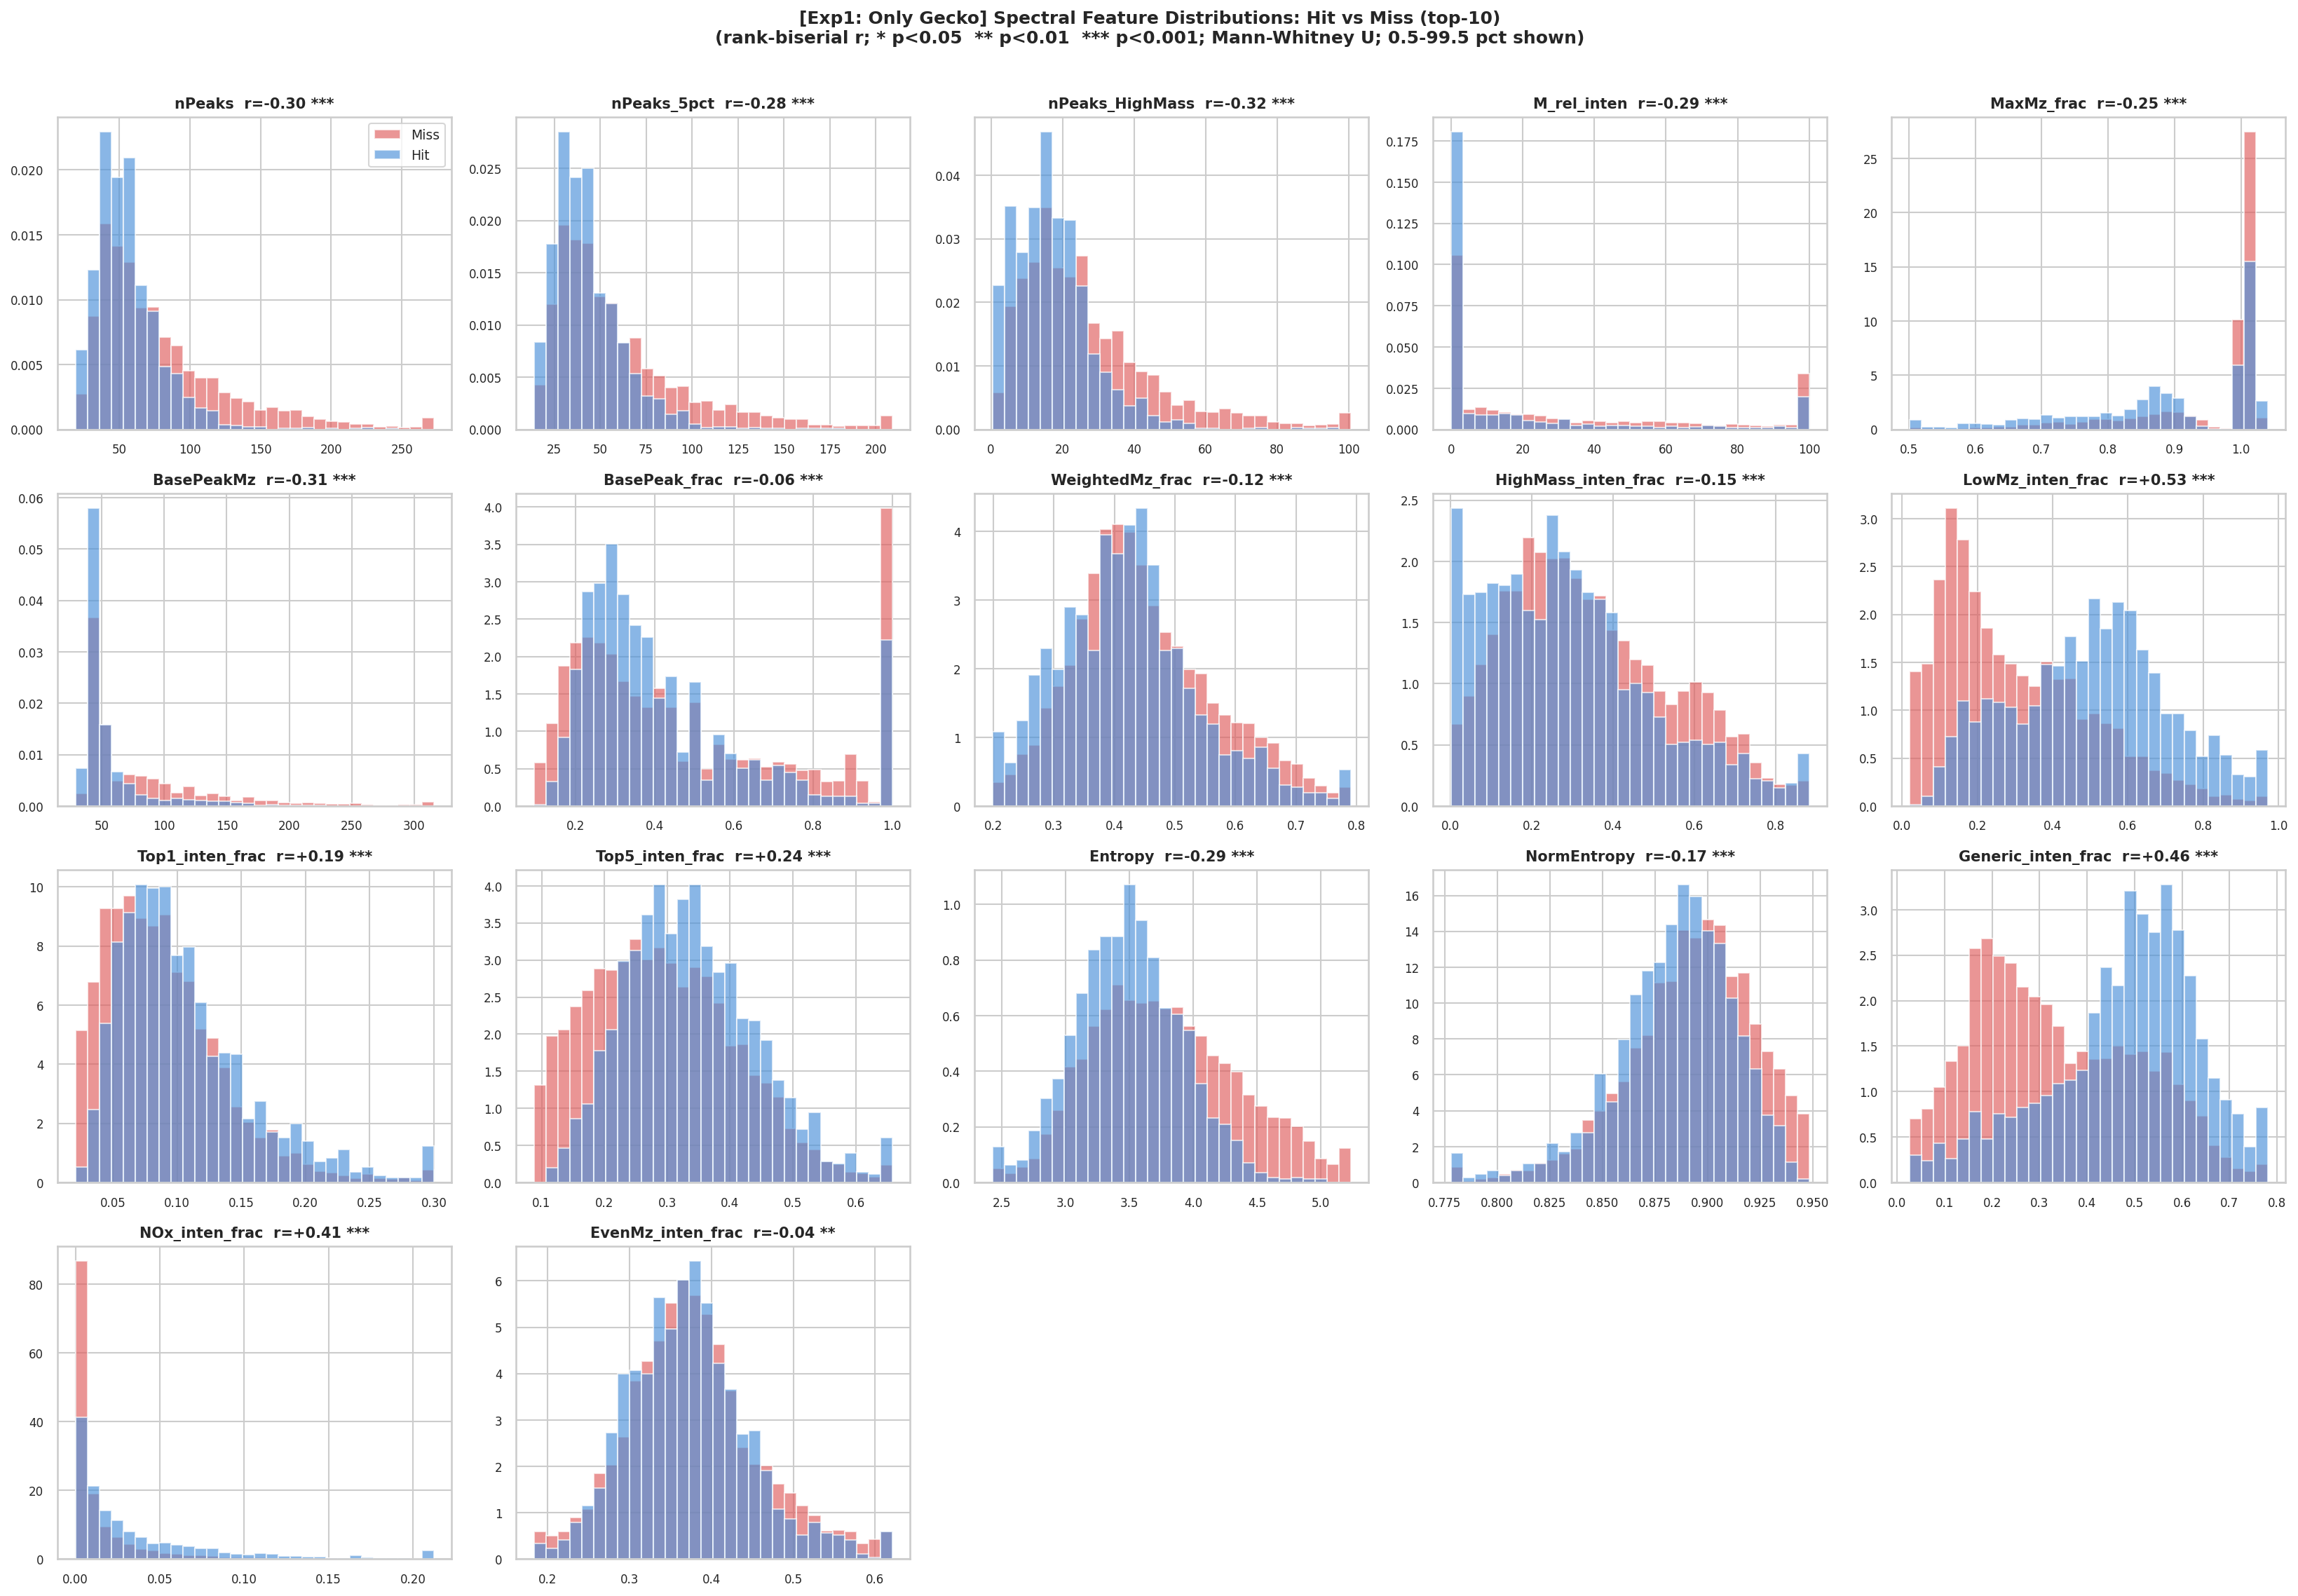


=== Exp1: Only Gecko ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
LowMz_inten_frac,0.511,0.251,0.502,0.300,0.529,0.000
Generic_inten_frac,0.502,0.305,0.477,0.333,0.462,0.000
NOx_inten_frac,0.018,0.004,0.036,0.013,0.412,0.000
nPeaks_HighMass,16.000,22.000,17.332,27.091,-0.316,0.000
BasePeakMz,43.000,57.000,55.649,81.262,-0.314,0.000
nPeaks,52.000,65.000,55.969,79.986,-0.300,0.000
M_rel_inten,0.000,15.516,16.959,30.782,-0.291,0.000
Entropy,3.491,3.733,3.493,3.784,-0.288,0.000
nPeaks_5pct,39.000,49.000,42.809,60.546,-0.280,0.000


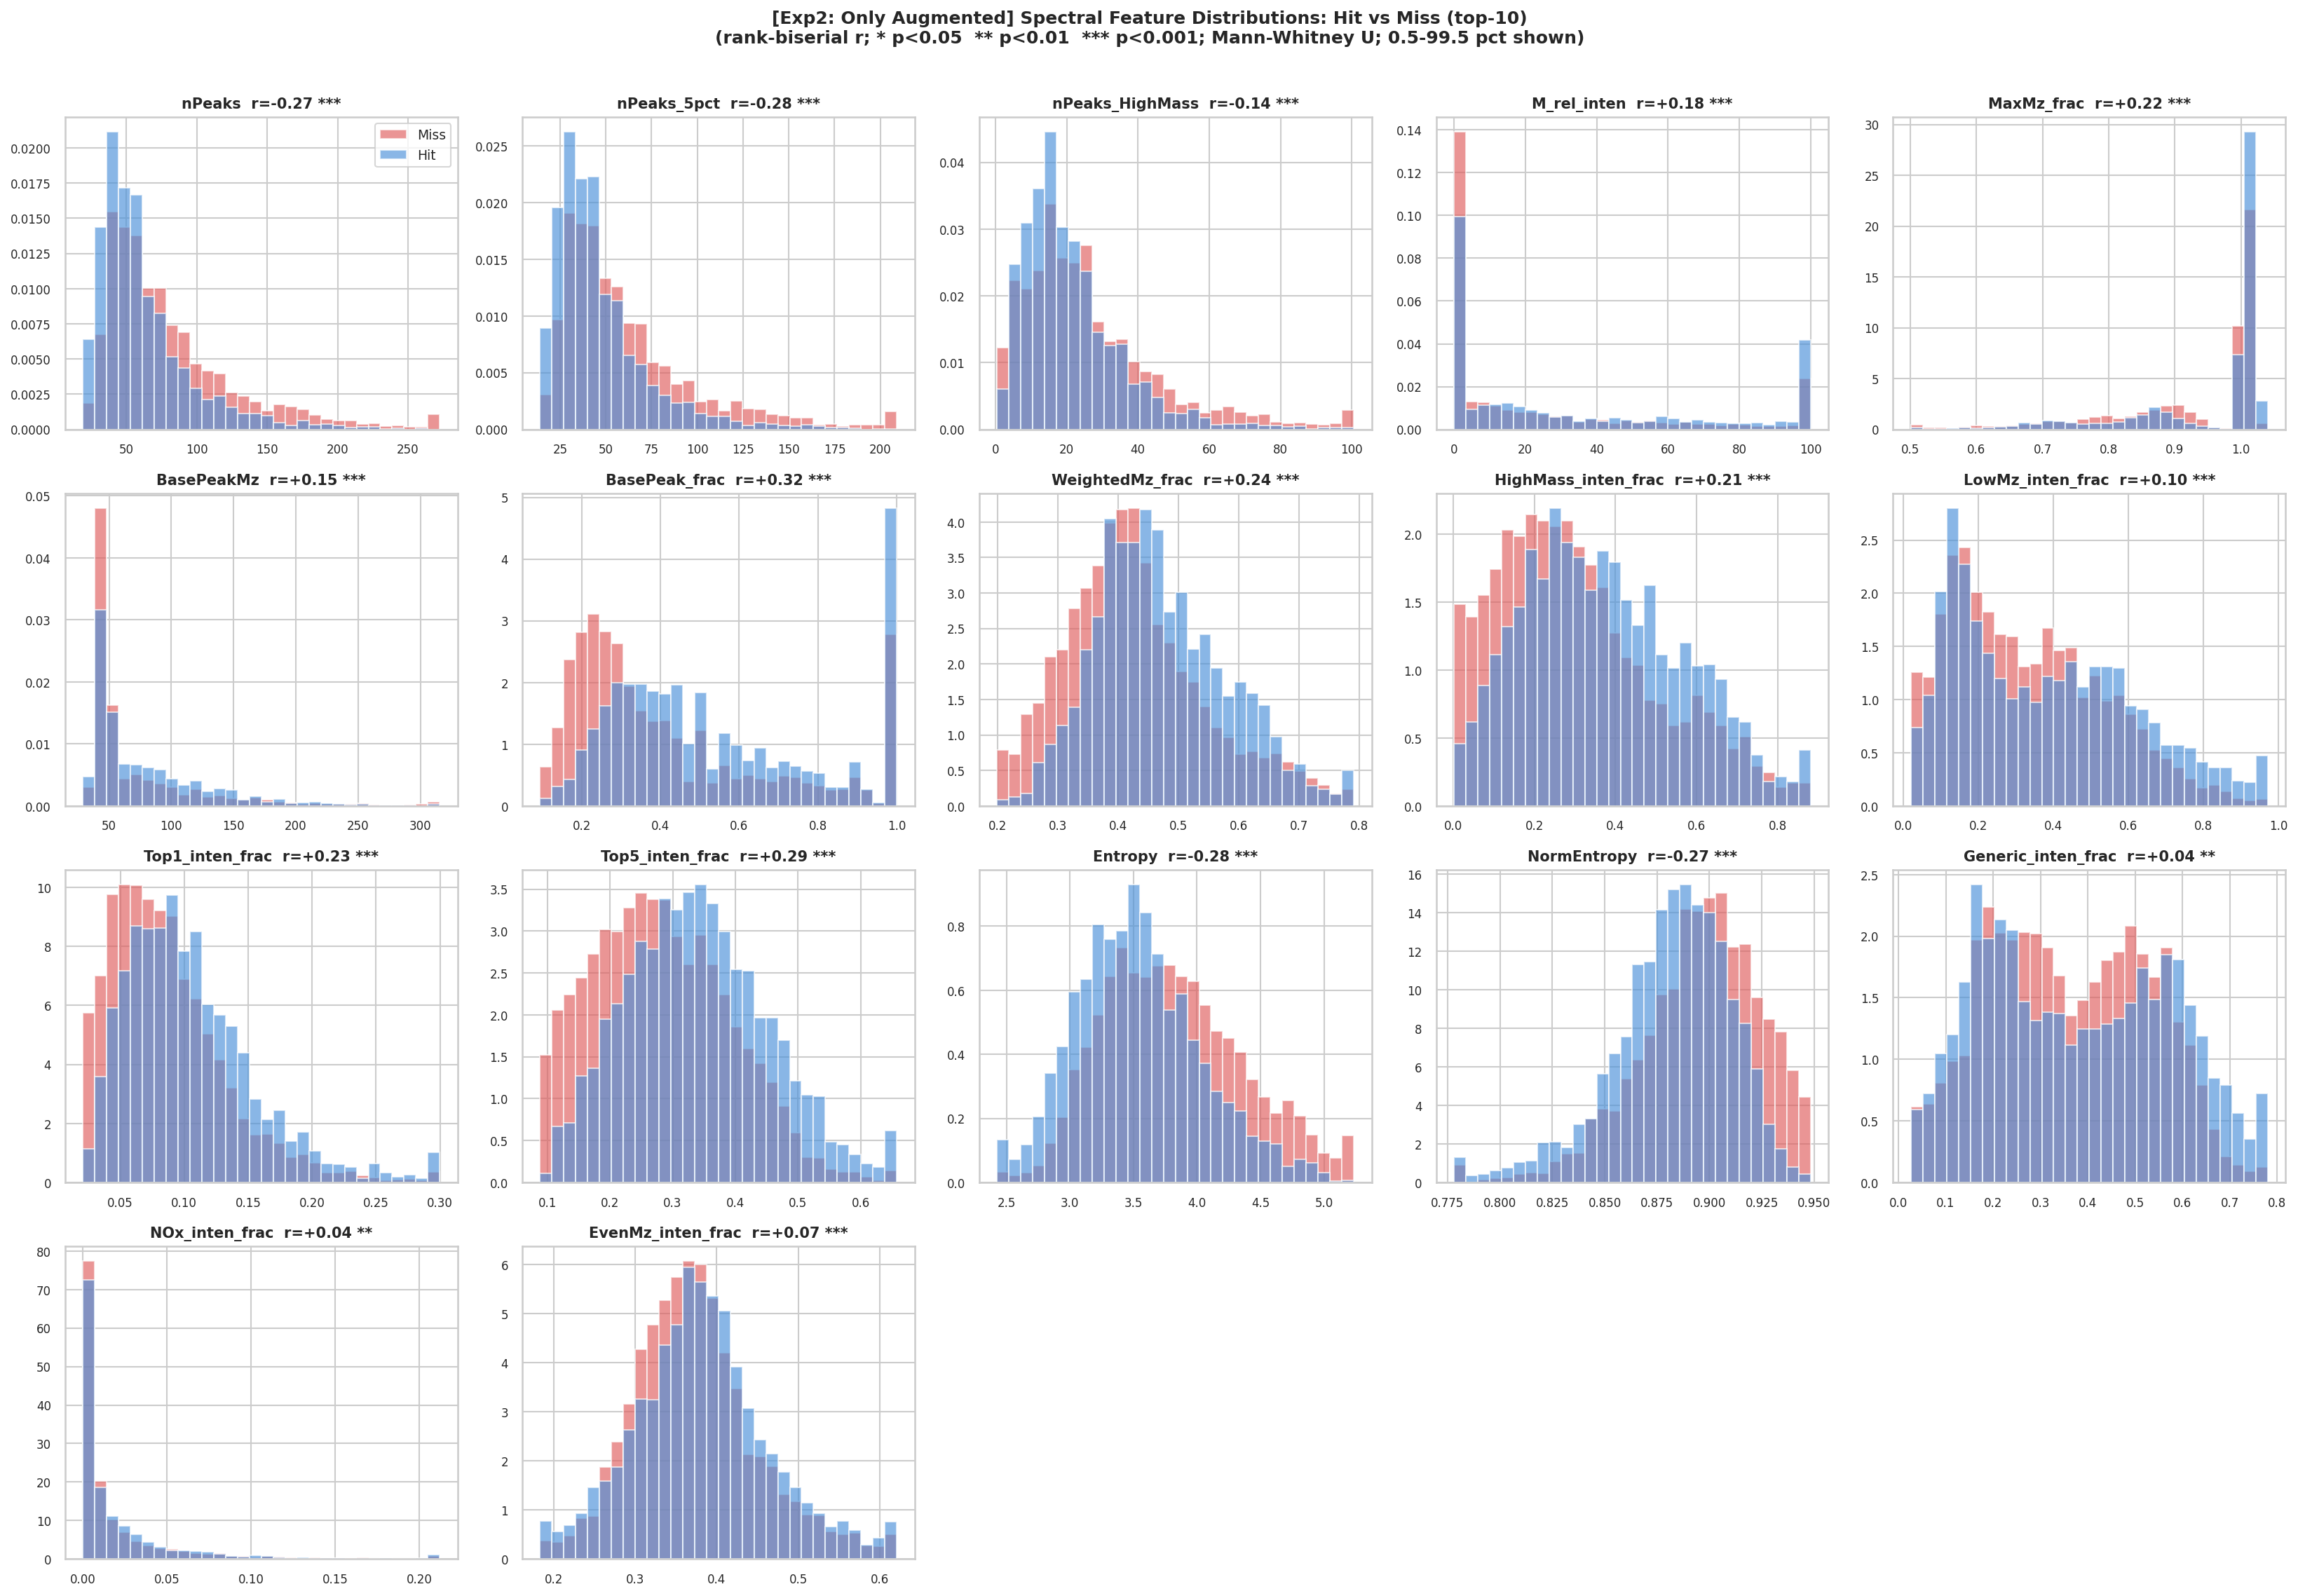


=== Exp2: Only Augmented ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
BasePeak_frac,0.469,0.324,0.540,0.417,0.324,0.000
Top5_inten_frac,0.334,0.274,0.341,0.282,0.285,0.000
Entropy,3.502,3.769,3.536,3.819,-0.285,0.000
nPeaks_5pct,40.000,51.000,46.306,62.156,-0.275,0.000
nPeaks,53.000,67.000,61.822,81.493,-0.272,0.000
NormEntropy,0.885,0.898,0.882,0.895,-0.271,0.000
WeightedMz_frac,0.458,0.413,0.473,0.427,0.243,0.000
Top1_inten_frac,0.095,0.078,0.105,0.086,0.232,0.000
MaxMz_frac,1.007,1.000,0.950,0.925,0.220,0.000


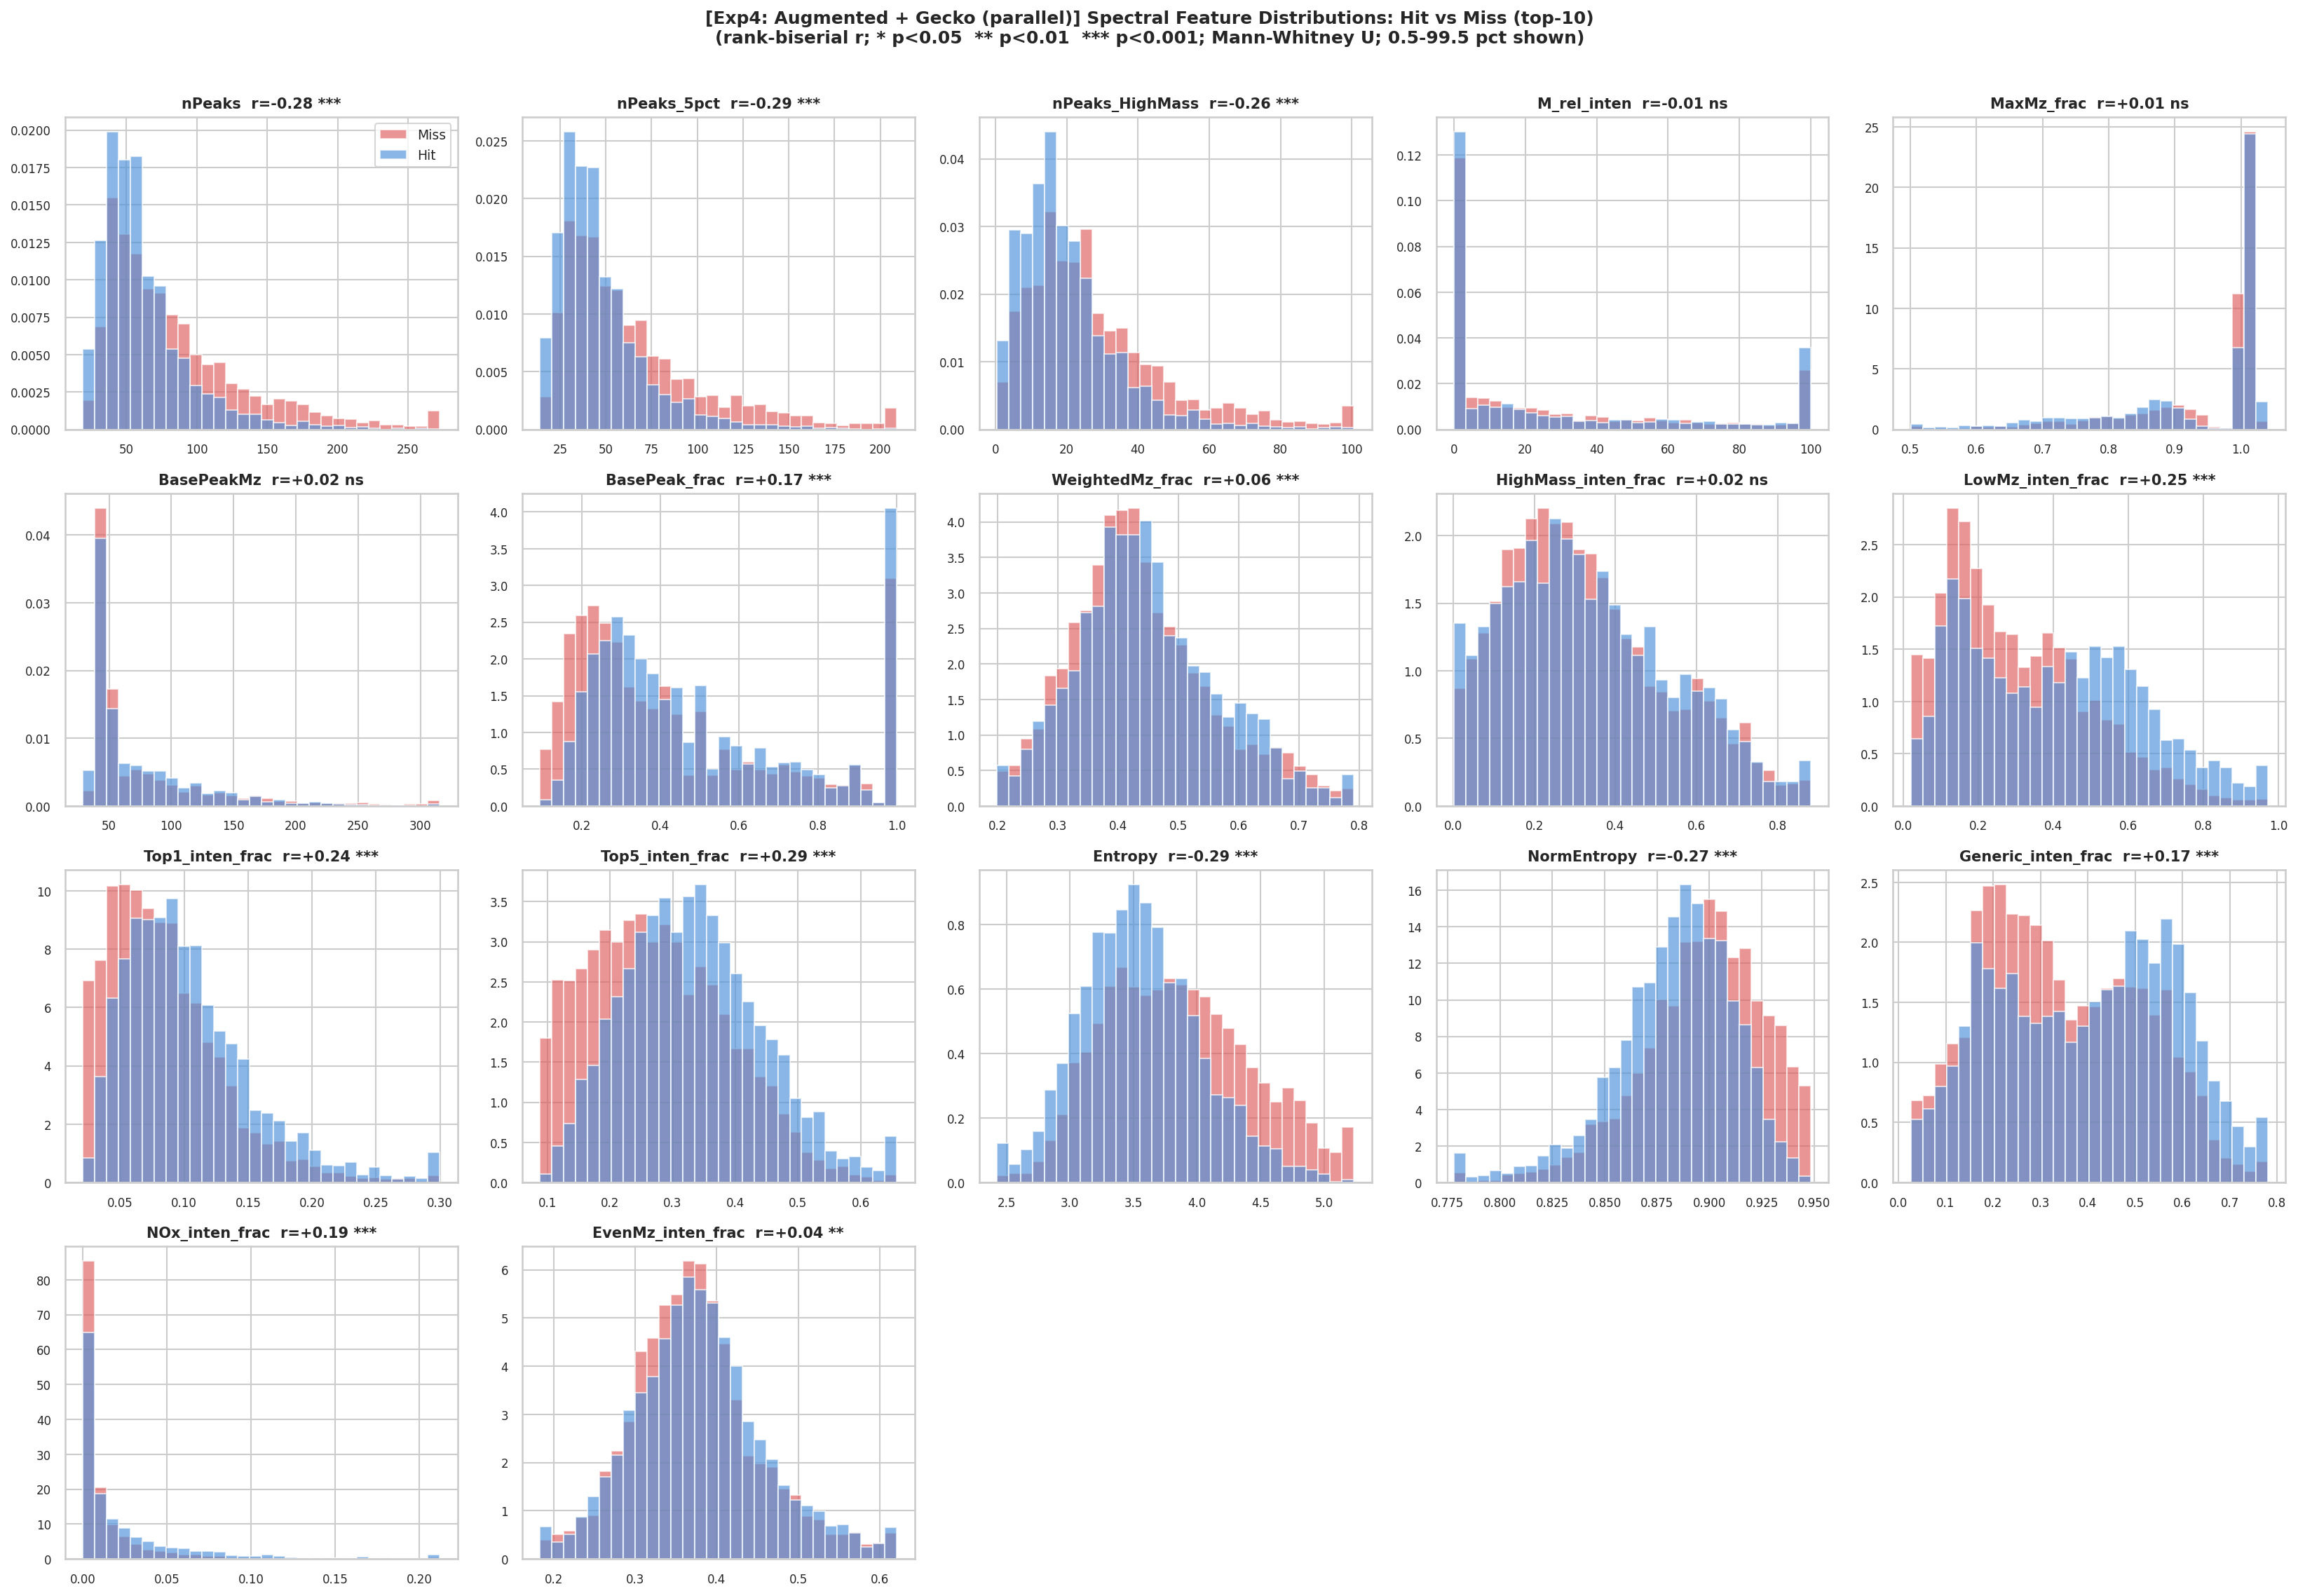


=== Exp4: Augmented + Gecko (parallel) ===


,Median (Hit),Median (Miss),Mean (Hit),Mean (Miss),r_rb,p-value
Feature,,,,,,
Entropy,3.531,3.813,3.555,3.856,-0.294,0.000
nPeaks_5pct,40.000,53.000,46.595,64.965,-0.286,0.000
Top5_inten_frac,0.327,0.265,0.335,0.276,0.286,0.000
nPeaks,54.000,70.000,62.039,85.109,-0.282,0.000
NormEntropy,0.887,0.900,0.883,0.897,-0.272,0.000
nPeaks_HighMass,17.000,24.000,20.273,28.740,-0.260,0.000
LowMz_inten_frac,0.394,0.261,0.402,0.302,0.247,0.000
Top1_inten_frac,0.094,0.076,0.104,0.084,0.244,0.000
NOx_inten_frac,0.009,0.004,0.025,0.014,0.190,0.000


In [5]:
def hit_miss_stats(adf, cols, outcome=HIT):
    hit, miss = adf[adf[outcome]], adf[~adf[outcome]]
    rows = []
    for col in cols:
        h, m = hit[col].dropna(), miss[col].dropna()
        U, p = stats.mannwhitneyu(h, m, alternative='two-sided')
        rows.append({'Feature': col, 'Median (Hit)': h.median(), 'Median (Miss)': m.median(),
                     'Mean (Hit)': h.mean(), 'Mean (Miss)': m.mean(),
                     'r_rb': 2 * U / (len(h) * len(m)) - 1, 'p-value': p})
    return pd.DataFrame(rows).sort_values('r_rb', key=np.abs, ascending=False)

exp_hm_stats = {}
for exp_name, adf in exp_dfs.items():
    hit, miss = adf[adf[HIT]], adf[~adf[HIT]]
    st = hit_miss_stats(adf, SPEC_COLS).set_index('Feature')
    exp_hm_stats[exp_name] = st

    fig, axes = plt.subplots(4, 5, figsize=(22, 15), dpi=PLOT_DPI)
    axes = axes.flatten()
    for ax, col in zip(axes, SPEC_COLS):
        lo, hi = np.nanpercentile(adf[col], [0.5, 99.5])
        bins = np.linspace(lo, hi, 31) if hi > lo else 30
        ax.hist(miss[col].clip(lo, hi), bins=bins, alpha=0.65, color=MISS_COLOR, label='Miss', density=True)
        ax.hist(hit[col].clip(lo, hi),  bins=bins, alpha=0.65, color=HIT_COLOR,  label='Hit',  density=True)
        ax.set_title(f"{col}  r={st.loc[col, 'r_rb']:+.2f} {sig_stars(st.loc[col, 'p-value'])}",
                     fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)
    for ax in axes[len(SPEC_COLS):]:
        ax.axis('off')
    axes[0].legend(fontsize=9)
    fig.suptitle(f'[{exp_name}] Spectral Feature Distributions: Hit vs Miss (top-{TOP_K})\n'
                 f'(rank-biserial r; * p<0.05  ** p<0.01  *** p<0.001; Mann-Whitney U; 0.5-99.5 pct shown)',
                 y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/hist_{exp_name.split(':')[0]}_top{TOP_K}.png", bbox_inches='tight')
    plt.show()

    print(f'\n=== {exp_name} ===')
    display(st.round(3))

## 5. Cross-experiment summary
Rank-biserial effect size of each spectral feature on top-`TOP_K` success, for every experiment side by side.

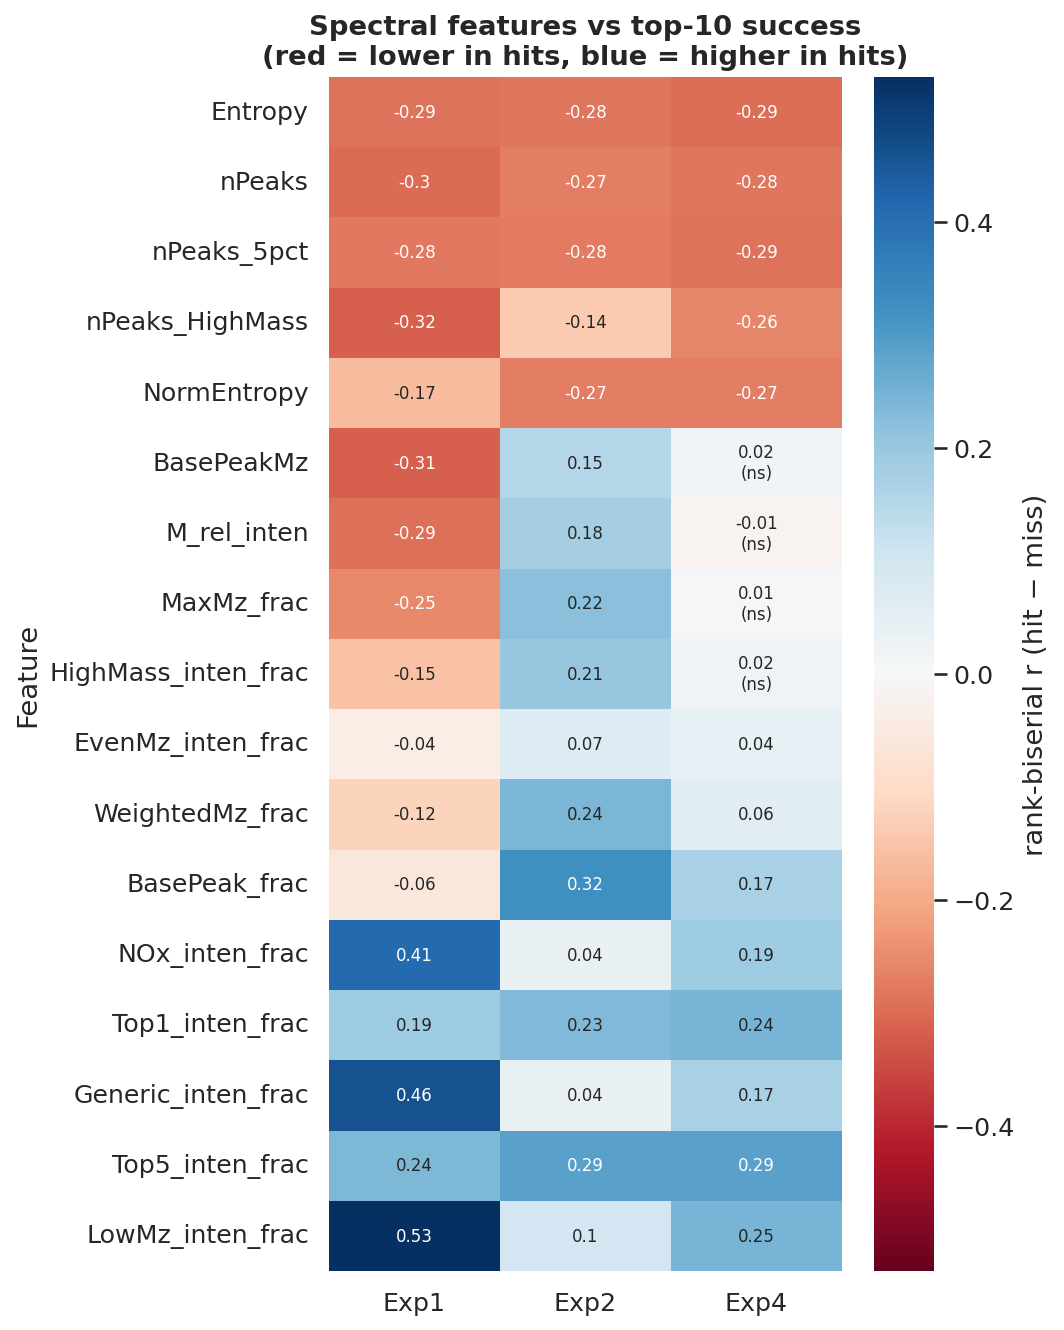

In [6]:
rb_mat = pd.DataFrame({e.split(':')[0]: s['r_rb'] for e, s in exp_hm_stats.items()}).loc[SPEC_COLS]
p_mat  = pd.DataFrame({e.split(':')[0]: s['p-value'] for e, s in exp_hm_stats.items()}).loc[SPEC_COLS]
annot  = rb_mat.round(2).astype(str) + p_mat.map(lambda p: '' if p < 0.05 else '\n(ns)')
order  = rb_mat.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(7, 9), dpi=PLOT_DPI)
lim = np.abs(rb_mat.values).max()
sns.heatmap(rb_mat.loc[order], annot=annot.loc[order], fmt='', cmap='RdBu', center=0, vmin=-lim, vmax=lim,
            cbar_kws={'label': 'rank-biserial r (hit − miss)'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title(f'Spectral features vs top-{TOP_K} success\n(red = lower in hits, blue = higher in hits)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/effect_size_heatmap_top{TOP_K}.png', bbox_inches='tight')
plt.show()

## 6. Top-1 Tanimoto similarity: spectral feature correlations
Spearman ρ between each spectral feature and the top-1 Tanimoto similarity (graded outcome; uses all molecules, not just hits).

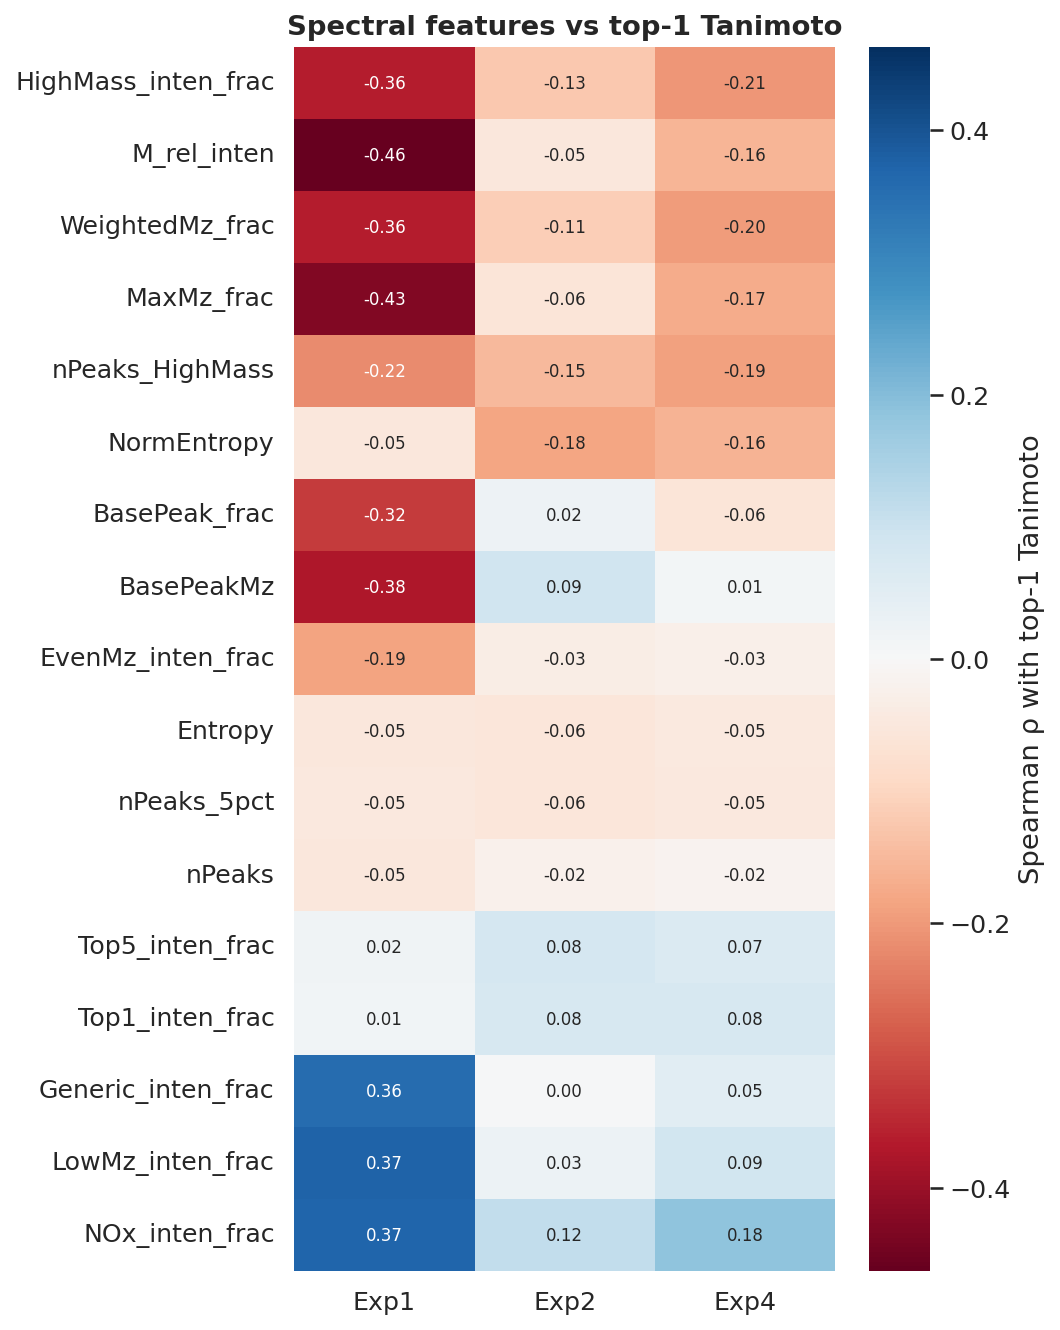

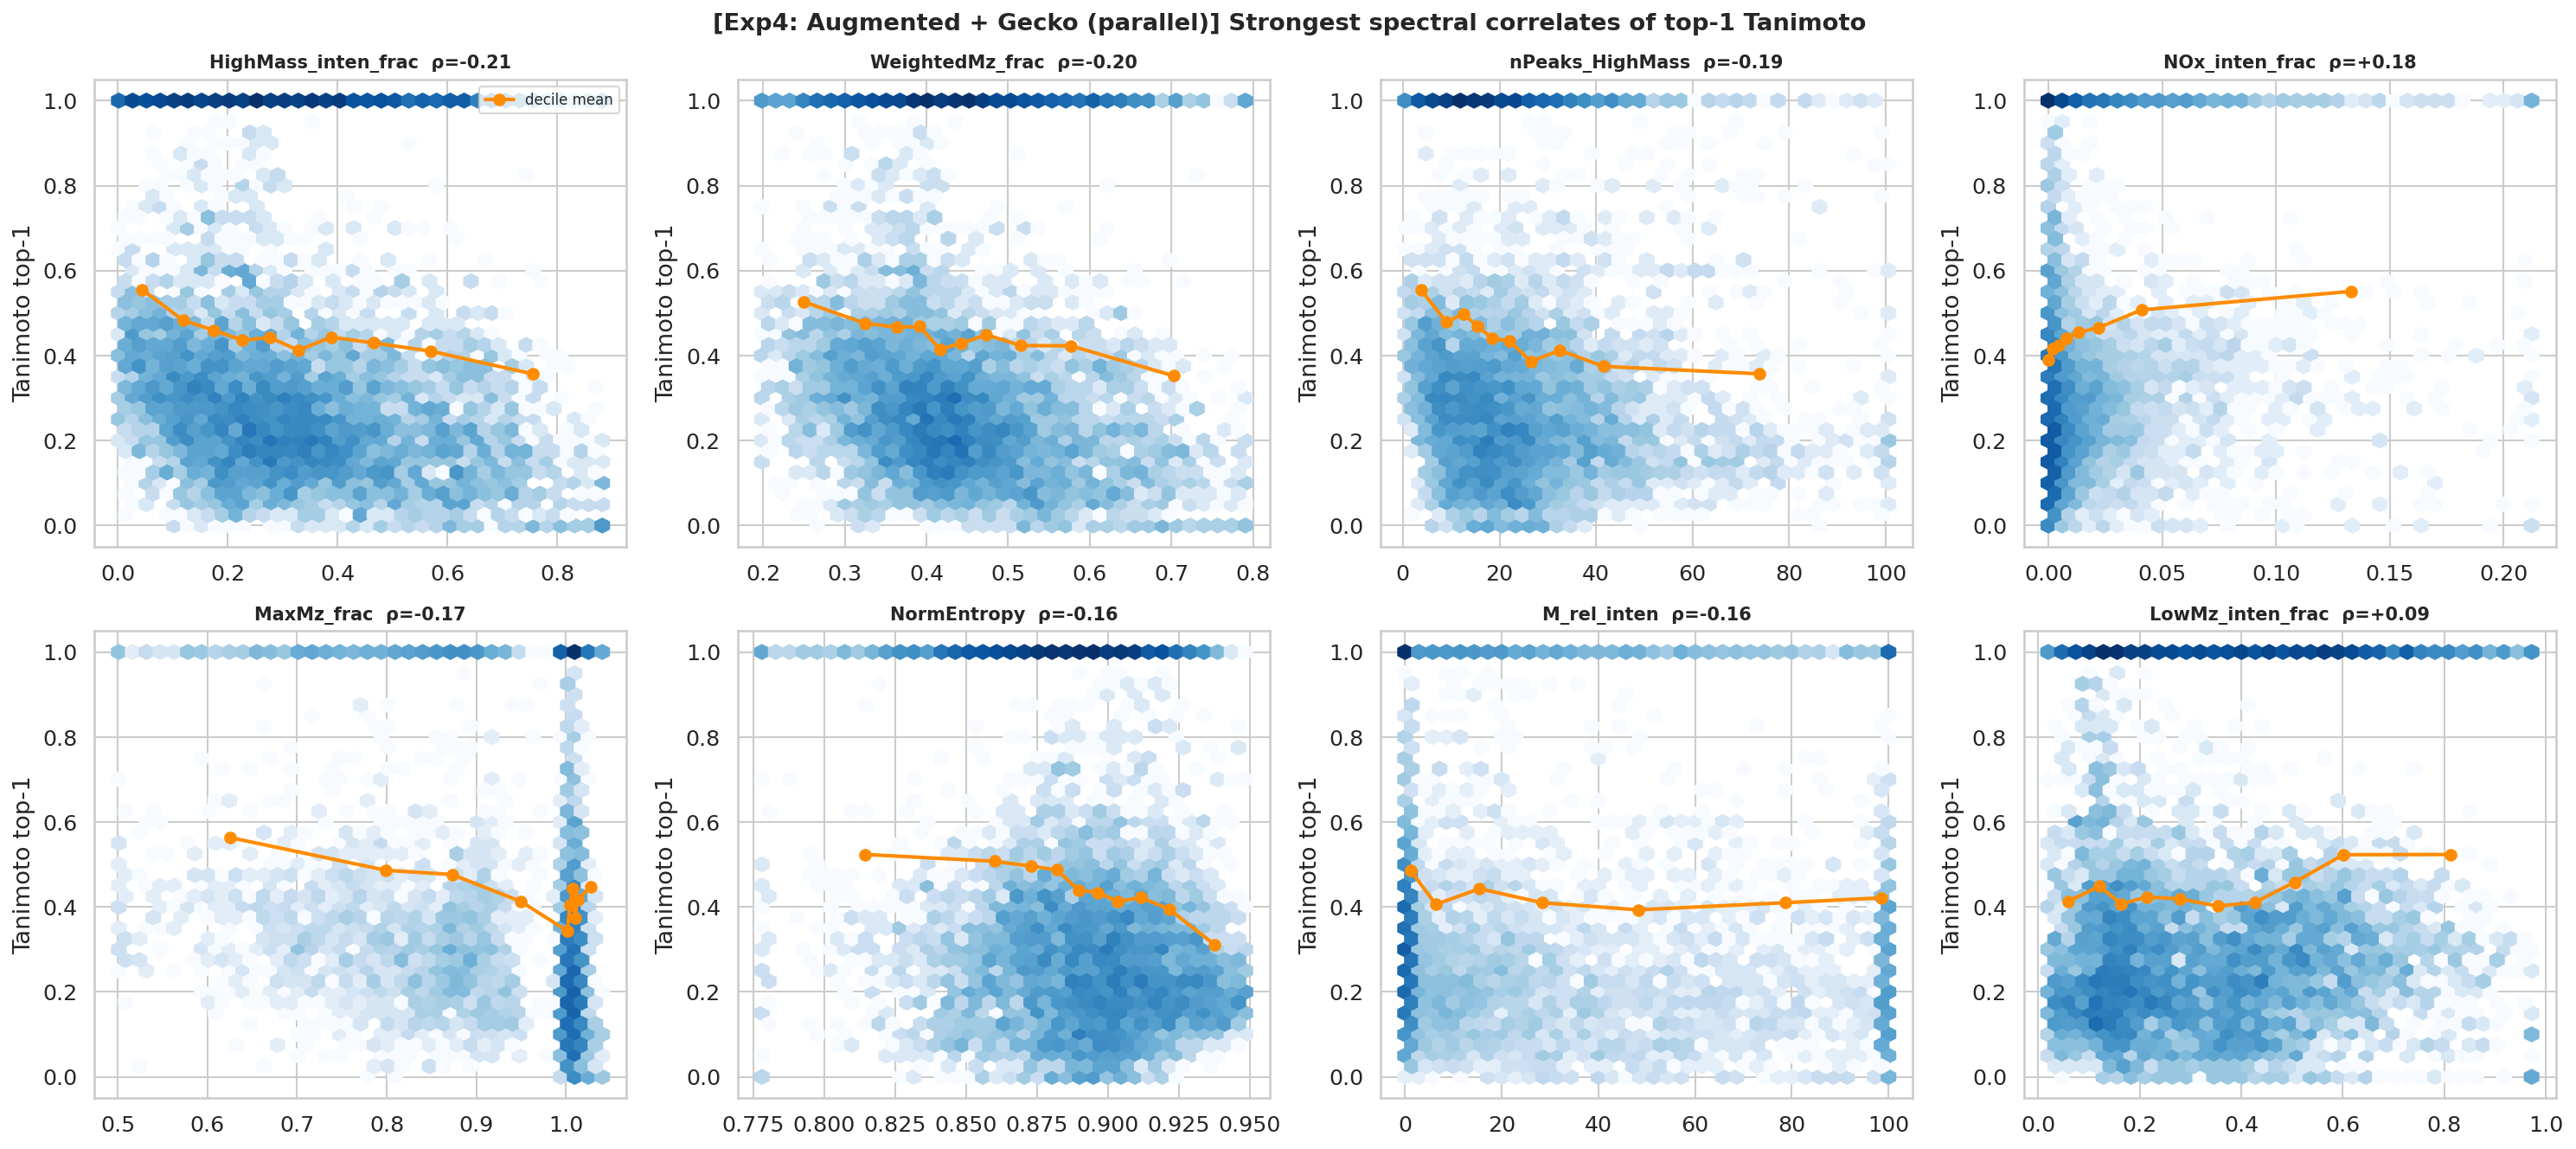

In [7]:
rho_mat = pd.DataFrame({
    e.split(':')[0]: {c: stats.spearmanr(adf[c], adf['tanimoto_top1'], nan_policy='omit')[0] for c in SPEC_COLS}
    for e, adf in exp_dfs.items()
}).loc[SPEC_COLS]
order = rho_mat.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(7, 9), dpi=PLOT_DPI)
lim = np.abs(rho_mat.values).max()
sns.heatmap(rho_mat.loc[order], annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-lim, vmax=lim,
            cbar_kws={'label': 'Spearman ρ with top-1 Tanimoto'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Spectral features vs top-1 Tanimoto', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/tanimoto_rho_heatmap.png', bbox_inches='tight')
plt.show()

# Scatter panels for the strongest features in the best experiment
EXP_SCATTER = 'Exp4: Augmented + Gecko (parallel)'
adf = exp_dfs[EXP_SCATTER]
top_feats = rho_mat[EXP_SCATTER.split(':')[0]].abs().sort_values(ascending=False).index[:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 9), dpi=PLOT_DPI)
for ax, col in zip(axes.flatten(), top_feats):
    lo, hi = np.nanpercentile(adf[col], [0.5, 99.5])
    x = adf[col].clip(lo, hi)
    ax.hexbin(x, adf['tanimoto_top1'], gridsize=35, cmap='Blues', mincnt=1, bins='log')
    # binned mean trend
    q = pd.qcut(x, 10, duplicates='drop')
    trend = adf.groupby(q, observed=True)['tanimoto_top1'].mean()
    ax.plot([iv.mid for iv in trend.index], trend.values, 'o-', color='darkorange', lw=2, label='decile mean')
    ax.set_title(f"{col}  ρ={rho_mat.loc[col, EXP_SCATTER.split(':')[0]]:+.2f}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Tanimoto top-1')
axes[0, 0].legend(fontsize=8)
fig.suptitle(f'[{EXP_SCATTER}] Strongest spectral correlates of top-1 Tanimoto', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Are the spectral effects just molecular size or structure?
The molecular notebook found size (MW, heavy atoms) to be a dominant difficulty factor, and many spectral features
scale with size. We check:
1. how spectral features correlate with RDKit descriptors and with ATMO functional-group counts;
2. **partial** Spearman correlations of each spectral feature with the outcomes, controlling for
   (a) size only (MW, HeavyAtoms) and (b) size plus the full ATMOMACCS fingerprint. A spectral effect that survives (b)
   carries difficulty information that the structural keys do not;
3. hit rate vs MW, stratified by molecular-ion intensity.

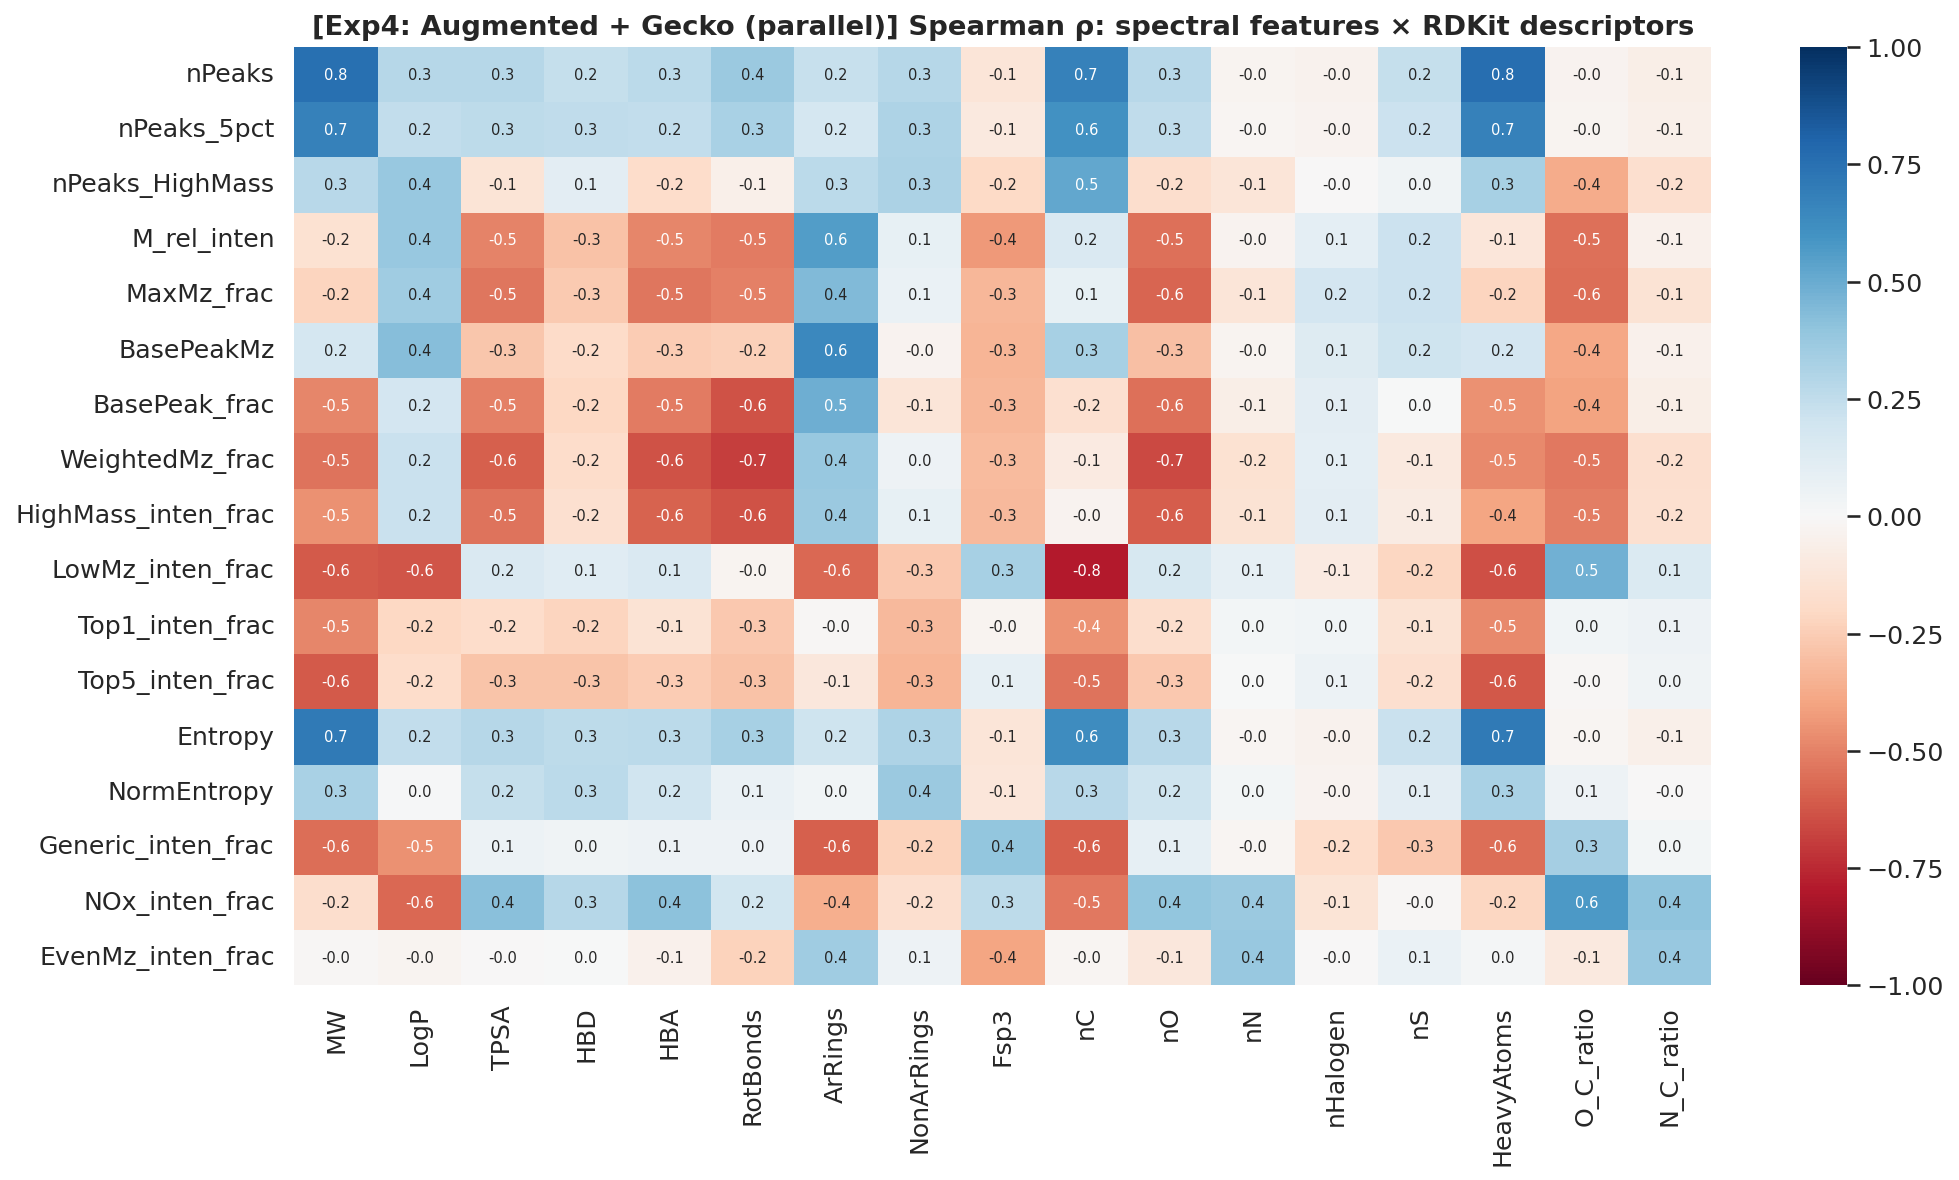

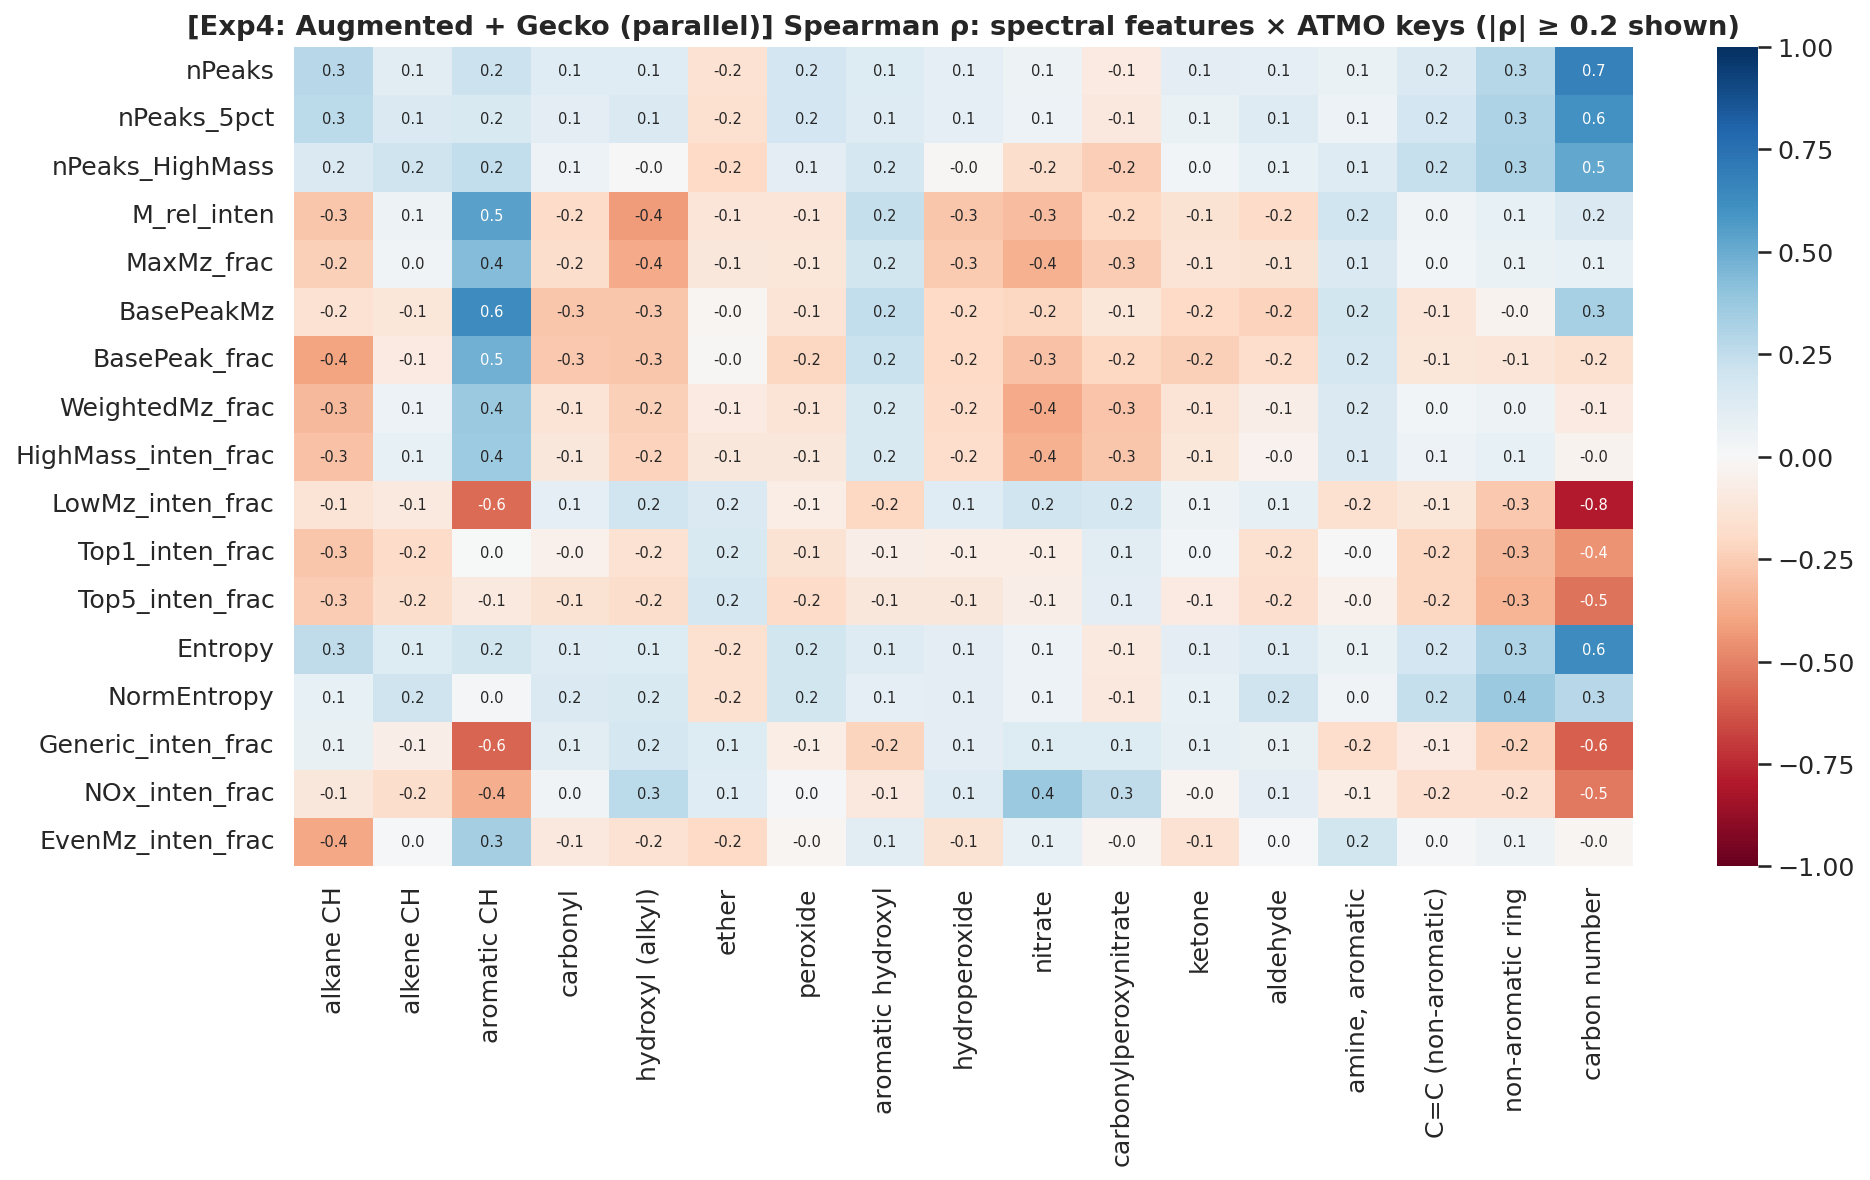

In [8]:
EXP_REF = 'Exp4: Augmented + Gecko (parallel)'
adf = exp_dfs[EXP_REF]
corr = pd.DataFrame({m: [stats.spearmanr(adf[s], adf[m])[0] for s in SPEC_COLS] for m in DESC_COLS}, index=SPEC_COLS)
fig, ax = plt.subplots(figsize=(14, 8), dpi=PLOT_DPI)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='RdBu', center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 7})
ax.set_title(f'[{EXP_REF}] Spearman ρ: spectral features × RDKit descriptors', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/spectral_vs_molecular_corr.png', bbox_inches='tight')
plt.show()

# Spectral features × ATMO functional-group counts (only keys with |ρ| ≥ 0.2 for at least one spectral feature)
corr_atmo = pd.DataFrame({a: [stats.spearmanr(adf[s], adf[a])[0] for s in SPEC_COLS] for a in ATMO_COLS},
                         index=SPEC_COLS).fillna(0)
corr_atmo = corr_atmo.loc[:, corr_atmo.abs().max() >= 0.2]
corr_atmo.columns = [c.replace('ATMO: ', '') for c in corr_atmo.columns]
fig, ax = plt.subplots(figsize=(max(8, 0.55 * corr_atmo.shape[1] + 4), 8), dpi=PLOT_DPI)
sns.heatmap(corr_atmo, annot=True, fmt='.1f', cmap='RdBu', center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 7})
ax.set_title(f'[{EXP_REF}] Spearman ρ: spectral features × ATMO keys (|ρ| ≥ 0.2 shown)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/spectral_vs_atmo_corr.png', bbox_inches='tight')
plt.show()

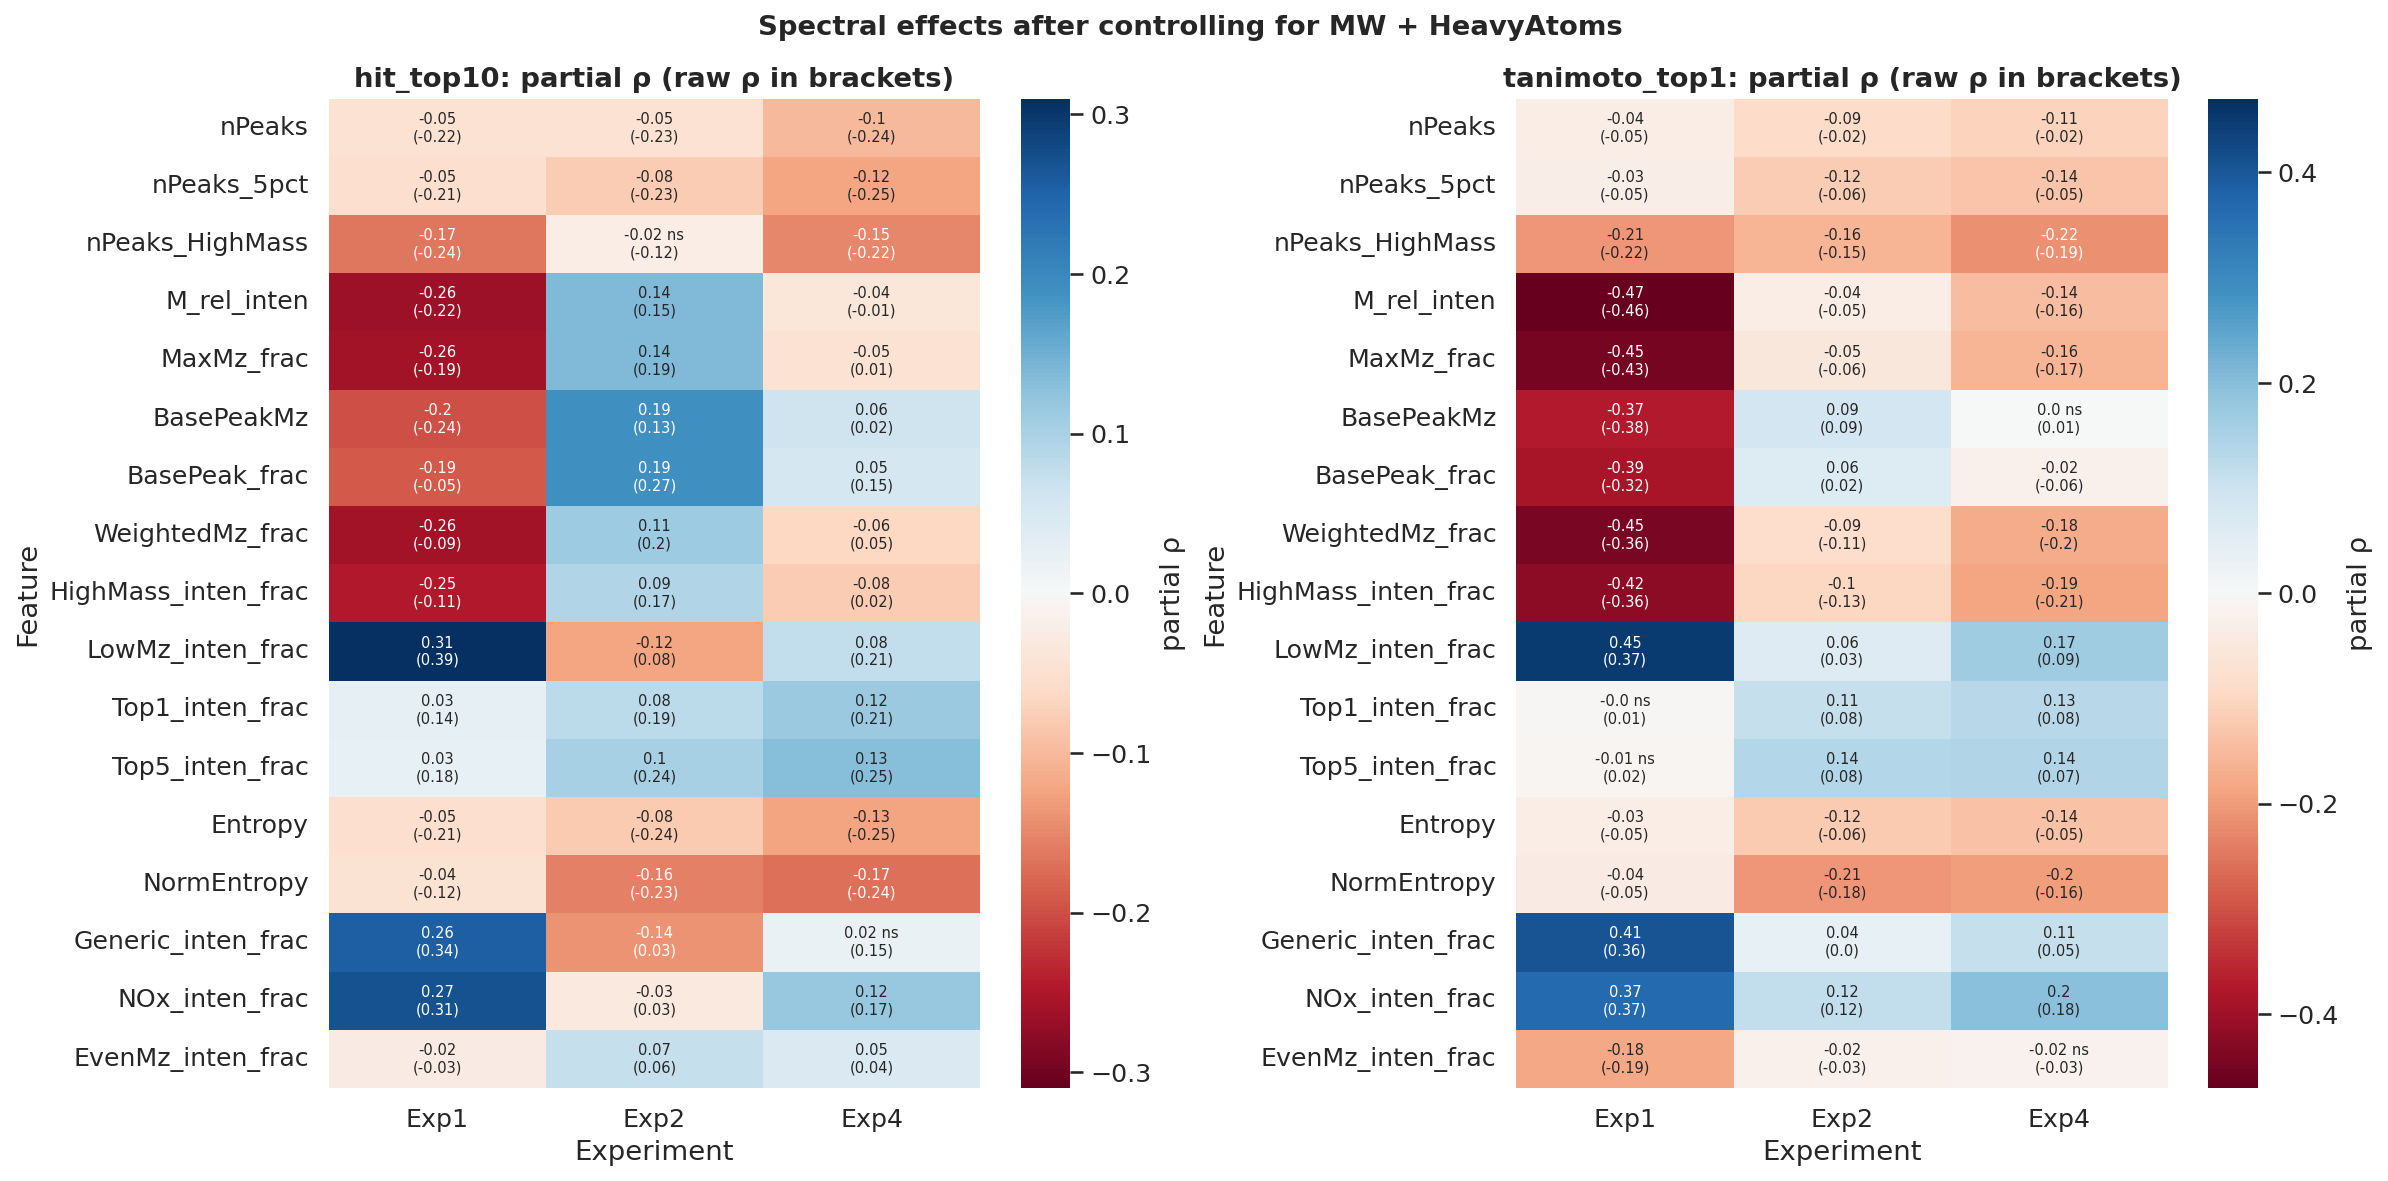

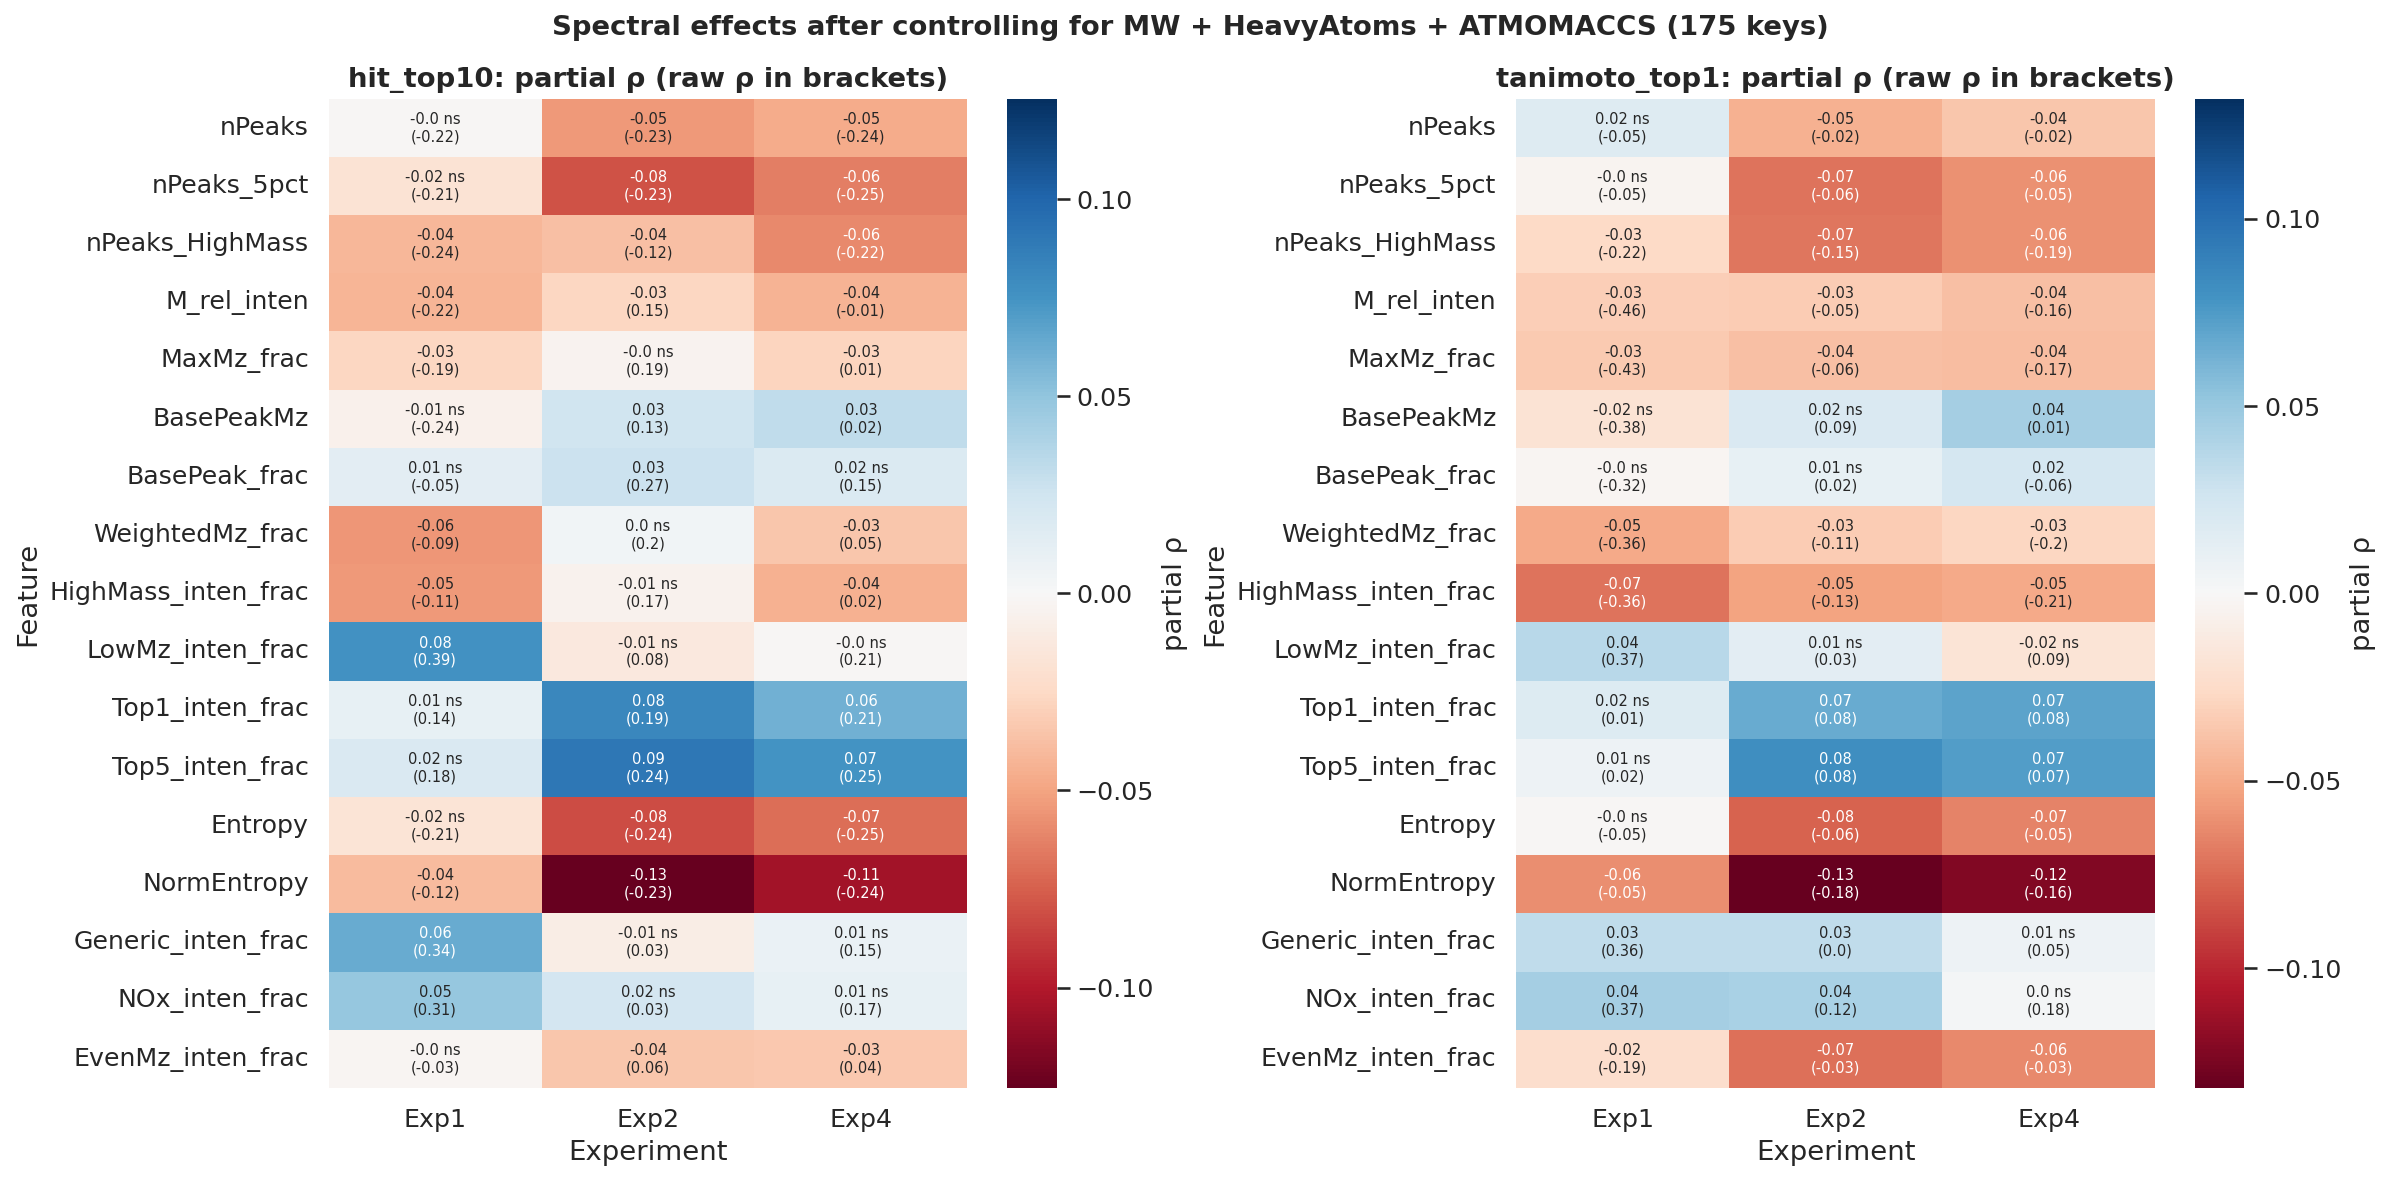

mean |ρ| raw  mean |ρ| | size  \
Outcome       Experiment                                  
hit_top10     Exp1               0.194            0.159   
              Exp2               0.165            0.106   
              Exp4               0.146            0.090   
tanimoto_top1 Exp1               0.239            0.254   
              Exp2               0.075            0.095   
              Exp4               0.104            0.133   

                          mean |ρ| | size + ATMOMACCS  
Outcome       Experiment                               
hit_top10     Exp1                              0.032  
              Exp2                              0.043  
              Exp4                              0.043  
tanimoto_top1 Exp1                              0.028  
              Exp2                              0.053  
              Exp4                              0.047

In [9]:
def rank_design(Z):
    '''Intercept + ranks of each covariate column.'''
    Z = np.asarray(Z, dtype=float)
    return np.column_stack([np.ones(len(Z))] + [stats.rankdata(z) for z in Z.T])

def partial_spearman(x, y, RZ):
    '''Spearman correlation of x and y after linearly removing the covariate ranks RZ from both.'''
    rx, ry = stats.rankdata(x), stats.rankdata(y)
    res = lambda v: v - RZ @ np.linalg.lstsq(RZ, v, rcond=None)[0]
    return stats.pearsonr(res(rx), res(ry))

COVARIATES = ['MW', 'HeavyAtoms']
CONTROLS = {'size': COVARIATES, 'structure': COVARIATES + ATMOMACCS_COLS}
part_rows = []
for exp_name, adf in exp_dfs.items():
    designs = {k: rank_design(adf[cols].values) for k, cols in CONTROLS.items()}
    for col in SPEC_COLS:
        for outcome in [HIT, 'tanimoto_top1']:
            y = adf[outcome].astype(float).values
            row = {'Experiment': exp_name.split(':')[0], 'Feature': col, 'Outcome': outcome,
                   'rho_raw': stats.spearmanr(adf[col], y)[0]}
            row['rho_partial'], row['p_partial'] = partial_spearman(adf[col].values, y, designs['size'])
            row['rho_partial_struct'], row['p_partial_struct'] = partial_spearman(adf[col].values, y, designs['structure'])
            part_rows.append(row)
part_df = pd.DataFrame(part_rows)

CONTROL_PLOTS = {
    'rho_partial': ('p_partial', ' + '.join(COVARIATES), f'partial_correlations_top{TOP_K}.png'),
    'rho_partial_struct': ('p_partial_struct', f'{" + ".join(COVARIATES)} + ATMOMACCS ({len(ATMOMACCS_COLS)} keys)',
                           f'partial_correlations_structure_top{TOP_K}.png'),
}
for rho_col, (p_col, ctrl_label, fname) in CONTROL_PLOTS.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=PLOT_DPI)
    for ax, outcome in zip(axes, [HIT, 'tanimoto_top1']):
        d = part_df[part_df.Outcome == outcome]
        raw = d.pivot(index='Feature', columns='Experiment', values='rho_raw').loc[SPEC_COLS]
        par = d.pivot(index='Feature', columns='Experiment', values=rho_col).loc[SPEC_COLS]
        pv  = d.pivot(index='Feature', columns='Experiment', values=p_col).loc[SPEC_COLS]
        annot = par.round(2).astype(str) + pv.map(lambda p: '' if p < 0.05 else ' ns') + '\n(' + raw.round(2).astype(str) + ')'
        lim = max(np.abs(par.values).max(), 0.05)
        sns.heatmap(par, annot=annot, fmt='', cmap='RdBu', center=0, vmin=-lim, vmax=lim, ax=ax, annot_kws={'fontsize': 7},
                    cbar_kws={'label': 'partial ρ'})
        ax.set_title(f'{outcome}: partial ρ (raw ρ in brackets)', fontweight='bold')
    plt.suptitle(f'Spectral effects after controlling for {ctrl_label}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{fname}', bbox_inches='tight')
    plt.show()

# How much spectral signal is left after each control? (mean |ρ| over the 17 spectral features)
summary = part_df.groupby(['Outcome', 'Experiment'])[['rho_raw', 'rho_partial', 'rho_partial_struct']] \
                 .agg(lambda v: np.abs(v).mean()).round(3)
summary.columns = ['mean |ρ| raw', 'mean |ρ| | size', 'mean |ρ| | size + ATMOMACCS']
display(summary)

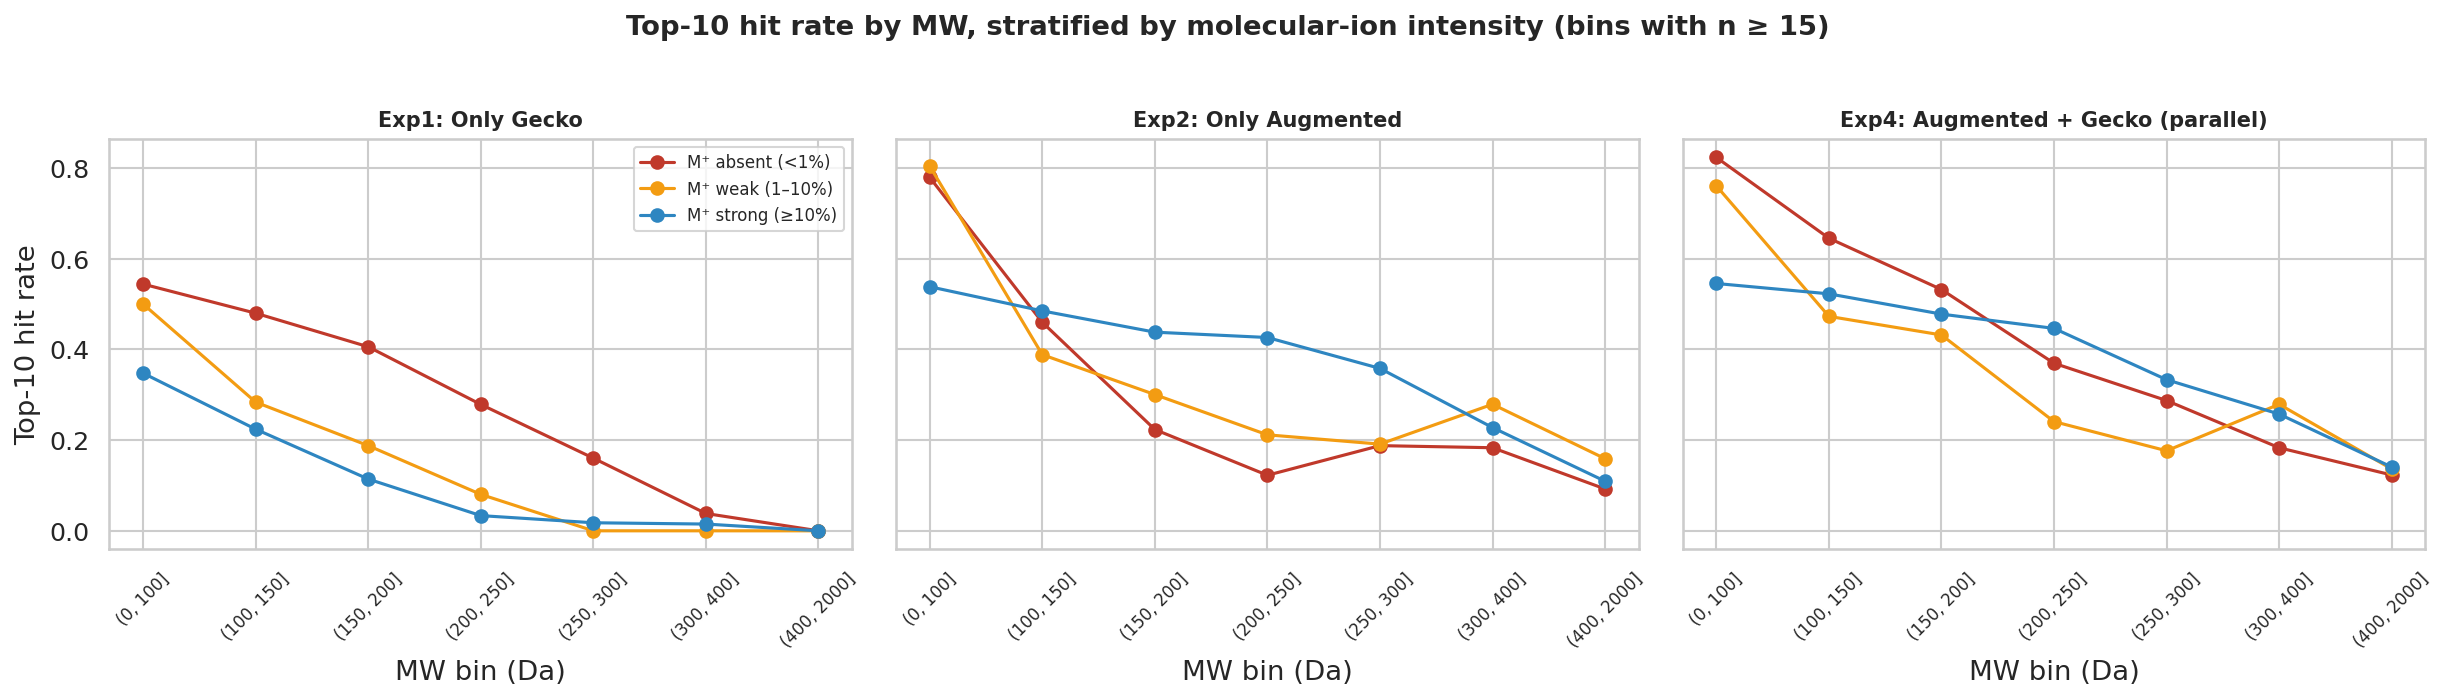

Exp1: Only Gecko


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.372,0.418,165.027
M⁺ weak (1–10%),847,0.187,0.291,167.911
M⁺ strong (≥10%),3789,0.163,0.213,150.068


Exp2: Only Augmented


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.298,0.379,165.027
M⁺ weak (1–10%),847,0.327,0.379,167.911
M⁺ strong (≥10%),3789,0.445,0.406,150.068


Exp4: Augmented + Gecko (parallel)


,n,hit10,tanimoto,MW
Mion,,,,
M⁺ absent (<1%),2852,0.511,0.490,165.027
M⁺ weak (1–10%),847,0.390,0.404,167.911
M⁺ strong (≥10%),3789,0.471,0.416,150.068


In [10]:
# Hit rate vs MW, stratified by molecular-ion intensity
M_BINS   = [-0.01, 1, 10, 100.01]
M_LABELS = ['M⁺ absent (<1%)', 'M⁺ weak (1–10%)', 'M⁺ strong (≥10%)']
MW_BINS  = [0, 100, 150, 200, 250, 300, 400, 2000]

fig, axes = plt.subplots(1, len(exp_dfs), figsize=(5.5 * len(exp_dfs), 4.5), dpi=PLOT_DPI, sharey=True)
for ax, (exp_name, adf) in zip(axes, exp_dfs.items()):
    d = adf.assign(Mion=pd.cut(adf.M_rel_inten, M_BINS, labels=M_LABELS),
                   MWbin=pd.cut(adf.MW, MW_BINS))
    g = d.groupby(['Mion', 'MWbin'], observed=True)[HIT].agg(['mean', 'count']).reset_index()
    for lab, c in zip(M_LABELS, ['#c0392b', '#f39c12', '#2e86c1']):
        s = g[(g.Mion == lab) & (g['count'] >= 15)]
        ax.plot(s.MWbin.astype(str), s['mean'], 'o-', color=c, label=lab)
    ax.set_title(exp_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('MW bin (Da)')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
axes[0].set_ylabel(f'Top-{TOP_K} hit rate')
axes[0].legend(fontsize=8)
plt.suptitle(f'Top-{TOP_K} hit rate by MW, stratified by molecular-ion intensity (bins with n ≥ 15)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/hit_rate_MW_by_Mion_top{TOP_K}.png', bbox_inches='tight')
plt.show()

for exp_name, adf in exp_dfs.items():
    d = adf.assign(Mion=pd.cut(adf.M_rel_inten, M_BINS, labels=M_LABELS))
    print(exp_name)
    display(d.groupby('Mion', observed=True).agg(n=(HIT, 'size'), **{f'hit{TOP_K}': (HIT, 'mean')},
                                                 tanimoto=('tanimoto_top1', 'mean'), MW=('MW', 'median')).round(3))

## 8. Predictive value: molecular vs spectral vs combined
How much of per-molecule difficulty can be predicted from molecular features, spectral summary features, or both?
Feature sets: `descriptors` (17 RDKit descriptors), `ATMOMACCS` (deduplicated MACCS + ATMO counts), `molecular`
(descriptors + ATMOMACCS), `spectral` (17 spectral features) and `combined` (molecular + spectral).
Gradient-boosted trees, 5-fold CV. Metrics: ROC-AUC / average precision for top-`TOP_K` hit, Spearman ρ between
out-of-fold predictions and true top-1 Tanimoto. If `combined` clearly beats `molecular`, the spectrum carries
difficulty information that the structural features don't.

,Experiment,Features,ROC-AUC (hit10),AP (hit10),AP baseline,Spearman (tanimoto)
0,Exp1,descriptors,0.922,0.764,0.245,0.772
1,Exp1,ATMOMACCS,0.950,0.841,0.245,0.810
2,Exp1,molecular,0.950,0.838,0.245,0.810
3,Exp1,spectral,0.847,0.604,0.245,0.638
4,Exp1,combined,0.948,0.830,0.245,0.803
5,Exp2,descriptors,0.906,0.839,0.376,0.671
6,Exp2,ATMOMACCS,0.930,0.875,0.376,0.718
7,Exp2,molecular,0.930,0.877,0.376,0.717
8,Exp2,spectral,0.831,0.727,0.376,0.450
9,Exp2,combined,0.930,0.876,0.376,0.710


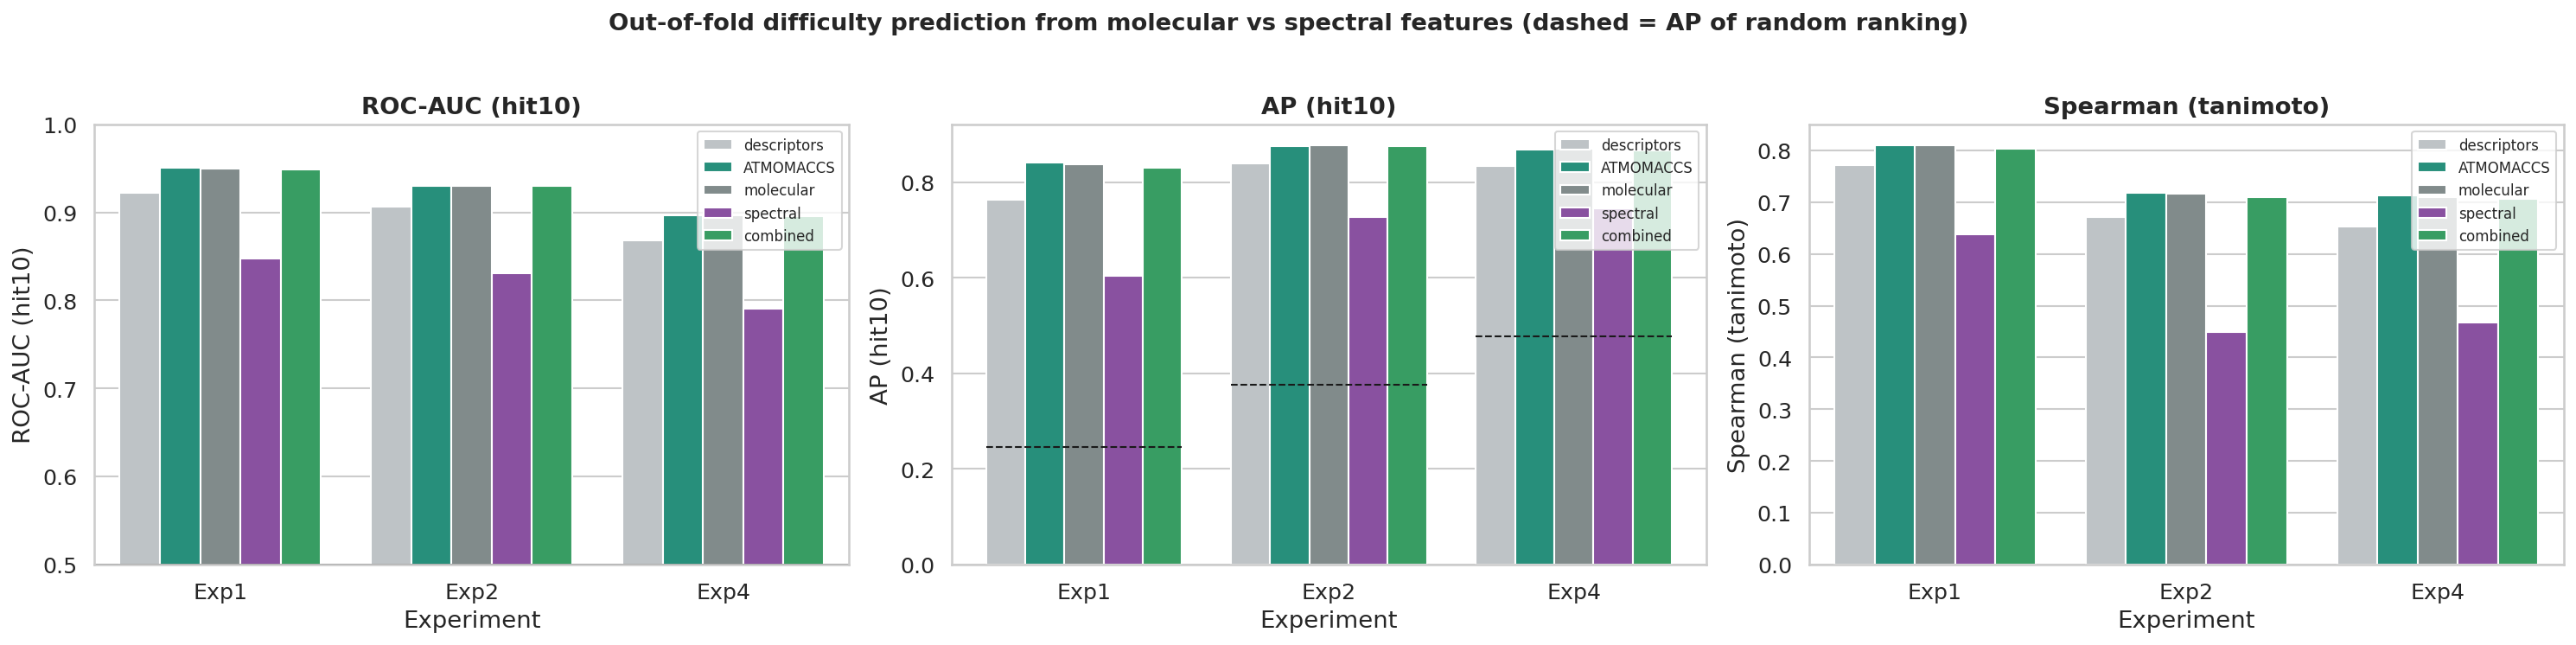

In [11]:
FEATURE_SETS = {'descriptors': DESC_COLS, 'ATMOMACCS': ATMOMACCS_COLS, 'molecular': MOL_COLS,
                'spectral': SPEC_COLS, 'combined': MOL_COLS + SPEC_COLS}
FS_PALETTE = {'descriptors': '#bdc3c7', 'ATMOMACCS': '#16a085', 'molecular': '#7f8c8d',
              'spectral': '#8e44ad', 'combined': '#27ae60'}

ml_rows = []
for exp_name, adf in exp_dfs.items():
    y_hit = adf[HIT].astype(int).values
    y_tan = adf['tanimoto_top1'].values
    for fs_name, cols in FEATURE_SETS.items():
        X = adf[cols].values
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42)
        prob = cross_val_predict(clf, X, y_hit, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 method='predict_proba')[:, 1]
        reg = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                            l2_regularization=1.0, random_state=42)
        pred = cross_val_predict(reg, X, y_tan, cv=KFold(5, shuffle=True, random_state=42))
        ml_rows.append({'Experiment': exp_name.split(':')[0], 'Features': fs_name,
                        f'ROC-AUC (hit{TOP_K})': roc_auc_score(y_hit, prob),
                        f'AP (hit{TOP_K})': average_precision_score(y_hit, prob),
                        'AP baseline': y_hit.mean(),
                        'Spearman (tanimoto)': stats.spearmanr(pred, y_tan)[0]})
ml_df = pd.DataFrame(ml_rows)
display(ml_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), dpi=PLOT_DPI)
for ax, metric in zip(axes, [f'ROC-AUC (hit{TOP_K})', f'AP (hit{TOP_K})', 'Spearman (tanimoto)']):
    sns.barplot(ml_df, x='Experiment', y=metric, hue='Features', ax=ax, palette=FS_PALETTE)
    if metric == f'ROC-AUC (hit{TOP_K})':
        ax.set_ylim(0.5, 1); ax.axhline(0.5, color='k', lw=0.8)
    if metric == f'AP (hit{TOP_K})':
        for i, e in enumerate(ml_df.Experiment.unique()):
            b = ml_df[ml_df.Experiment == e]['AP baseline'].iloc[0]
            ax.hlines(b, i - 0.4, i + 0.4, color='k', ls='--', lw=1)
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Out-of-fold difficulty prediction from molecular vs spectral features (dashed = AP of random ranking)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/difficulty_prediction_top{TOP_K}.png', bbox_inches='tight')
plt.show()

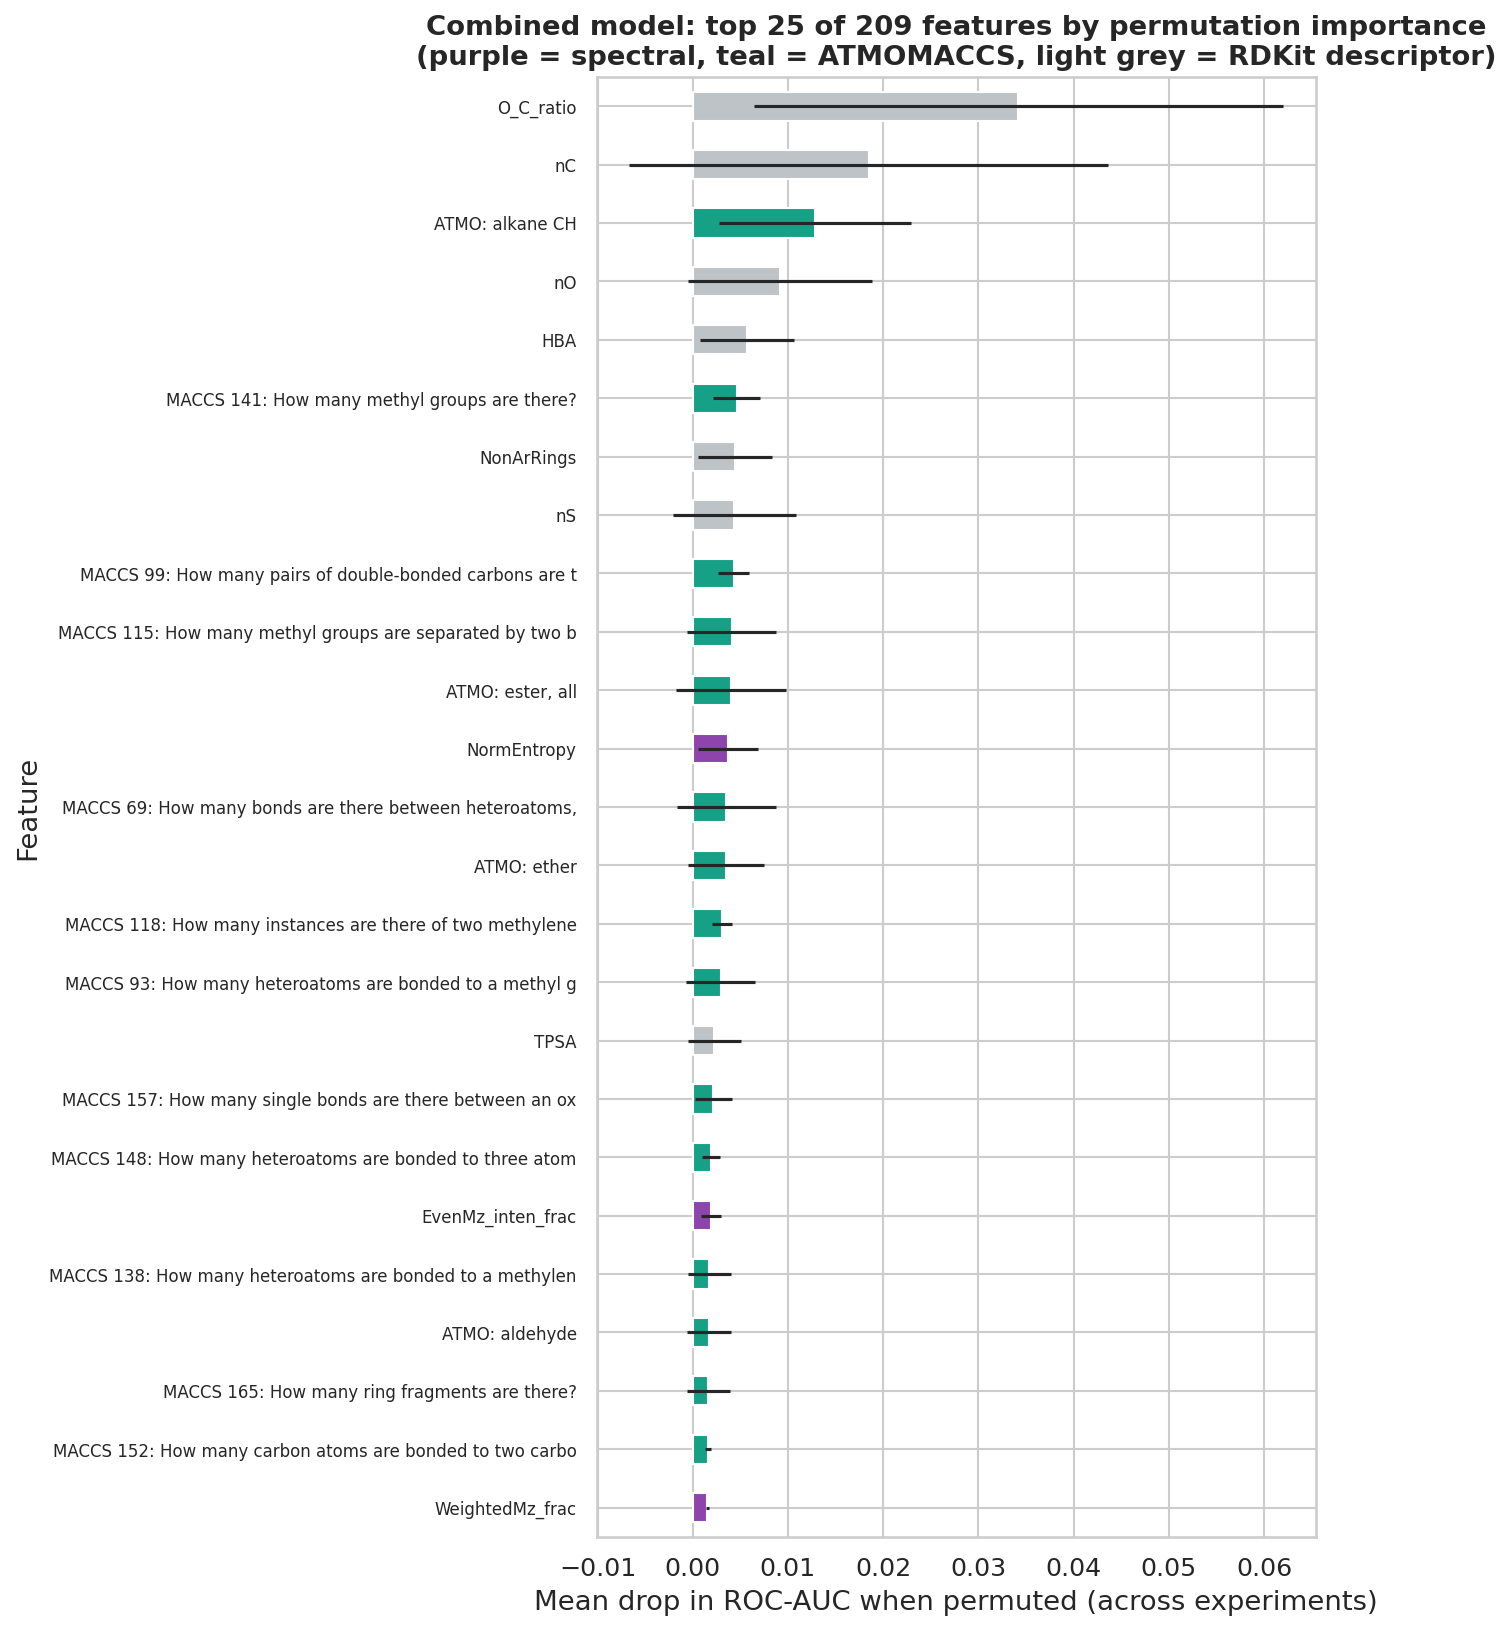

Experiment,Exp1,Exp2,Exp4
O_C_ratio,0.0021,0.0503,0.0502
nC,0.0474,0.0020,0.0060
ATMO: alkane CH,0.0017,0.0156,0.0212
nO,0.0002,0.0079,0.0194
HBA,0.0001,0.0083,0.0087
MACCS 141: How many methyl groups are there?,0.0018,0.0061,0.0060
NonArRings,-0.0000,0.0070,0.0064
nS,0.0118,0.0005,0.0007
MACCS 99: How many pairs of double-bonded carbons are t,0.0051,0.0024,0.0054
MACCS 115: How many methyl groups are separated by two b,0.0009,0.0019,0.0095


Summed permutation importance by feature group:


Feature
ATMOMACCS      0.0810
descriptors    0.0858
spectral       0.0178
dtype: float64

In [12]:
# Which features carry the signal in the combined model? (permutation importance on held-out folds, ROC-AUC)
imp_rows = []
for exp_name, adf in exp_dfs.items():
    cols = FEATURE_SETS['combined']
    X, y = adf[cols].values, adf[HIT].astype(int).values
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=0).split(X, y):
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42).fit(X[tr], y[tr])
        pi = permutation_importance(clf, X[te], y[te], scoring='roc_auc', n_repeats=5, random_state=0)
        imp_rows += [{'Experiment': exp_name.split(':')[0], 'Feature': c, 'importance': v}
                     for c, v in zip(cols, pi.importances_mean)]
imp = pd.DataFrame(imp_rows).groupby(['Experiment', 'Feature'])['importance'].mean().unstack(0)
imp = imp.loc[imp.mean(axis=1).sort_values(ascending=False).index]
group_of = lambda f: 'spectral' if f in SPEC_COLS else 'ATMOMACCS' if f in ATMOMACCS_COLS else 'descriptors'

N_SHOW = 25
top = imp.head(N_SHOW)
fig, ax = plt.subplots(figsize=(9, 11), dpi=PLOT_DPI)
top.mean(axis=1).plot.barh(ax=ax, color=[FS_PALETTE[group_of(f)] for f in top.index], xerr=top.std(axis=1))
ax.set_yticklabels([flabel(f) for f in top.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean drop in ROC-AUC when permuted (across experiments)')
ax.set_title(f'Combined model: top {N_SHOW} of {len(imp)} features by permutation importance\n'
             '(purple = spectral, teal = ATMOMACCS, light grey = RDKit descriptor)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/permutation_importance_top{TOP_K}.png', bbox_inches='tight')
plt.show()
top_tbl = top.copy()
top_tbl.index = [flabel(f) for f in top.index]
display(top_tbl.round(4))
print('Summed permutation importance by feature group:')
display(imp.mean(axis=1).groupby(group_of).sum().round(4))

## 9. Spectral space: PCA + k-means of binned spectra
Spectra are binned to unit m/z (1–`MAX_MZ`), square-root intensity, L2-normalised — the standard representation
for cosine similarity. PCA and k-means are run per experiment, as in the molecular notebook.

With the shared DDP test set the PCA and clusters come out identical for every experiment; only the hit/miss colouring and hit rates differ.

In [13]:
MAX_MZ = 1000

def bin_spectra(specs, max_mz=MAX_MZ):
    '''Vectorised binning of a list of (n,2) arrays → (len(specs), max_mz+1) float32, sqrt-intensity, unit L2.'''
    lens = np.fromiter((len(s) for s in specs), dtype=np.int64, count=len(specs))
    cat  = np.concatenate(specs)
    rows = np.repeat(np.arange(len(specs)), lens)
    cols = np.clip(cat[:, 0].astype(np.int64), 0, max_mz)
    M = np.zeros((len(specs), max_mz + 1), dtype=np.float32)
    np.add.at(M, (rows, cols), cat[:, 1].astype(np.float32))
    M = np.sqrt(M)
    M /= np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return M

test_binned = bin_spectra(list(test_spec['spec']))
print('Binned test spectra:', test_binned.shape)

Binned test spectra: (7536, 1001)


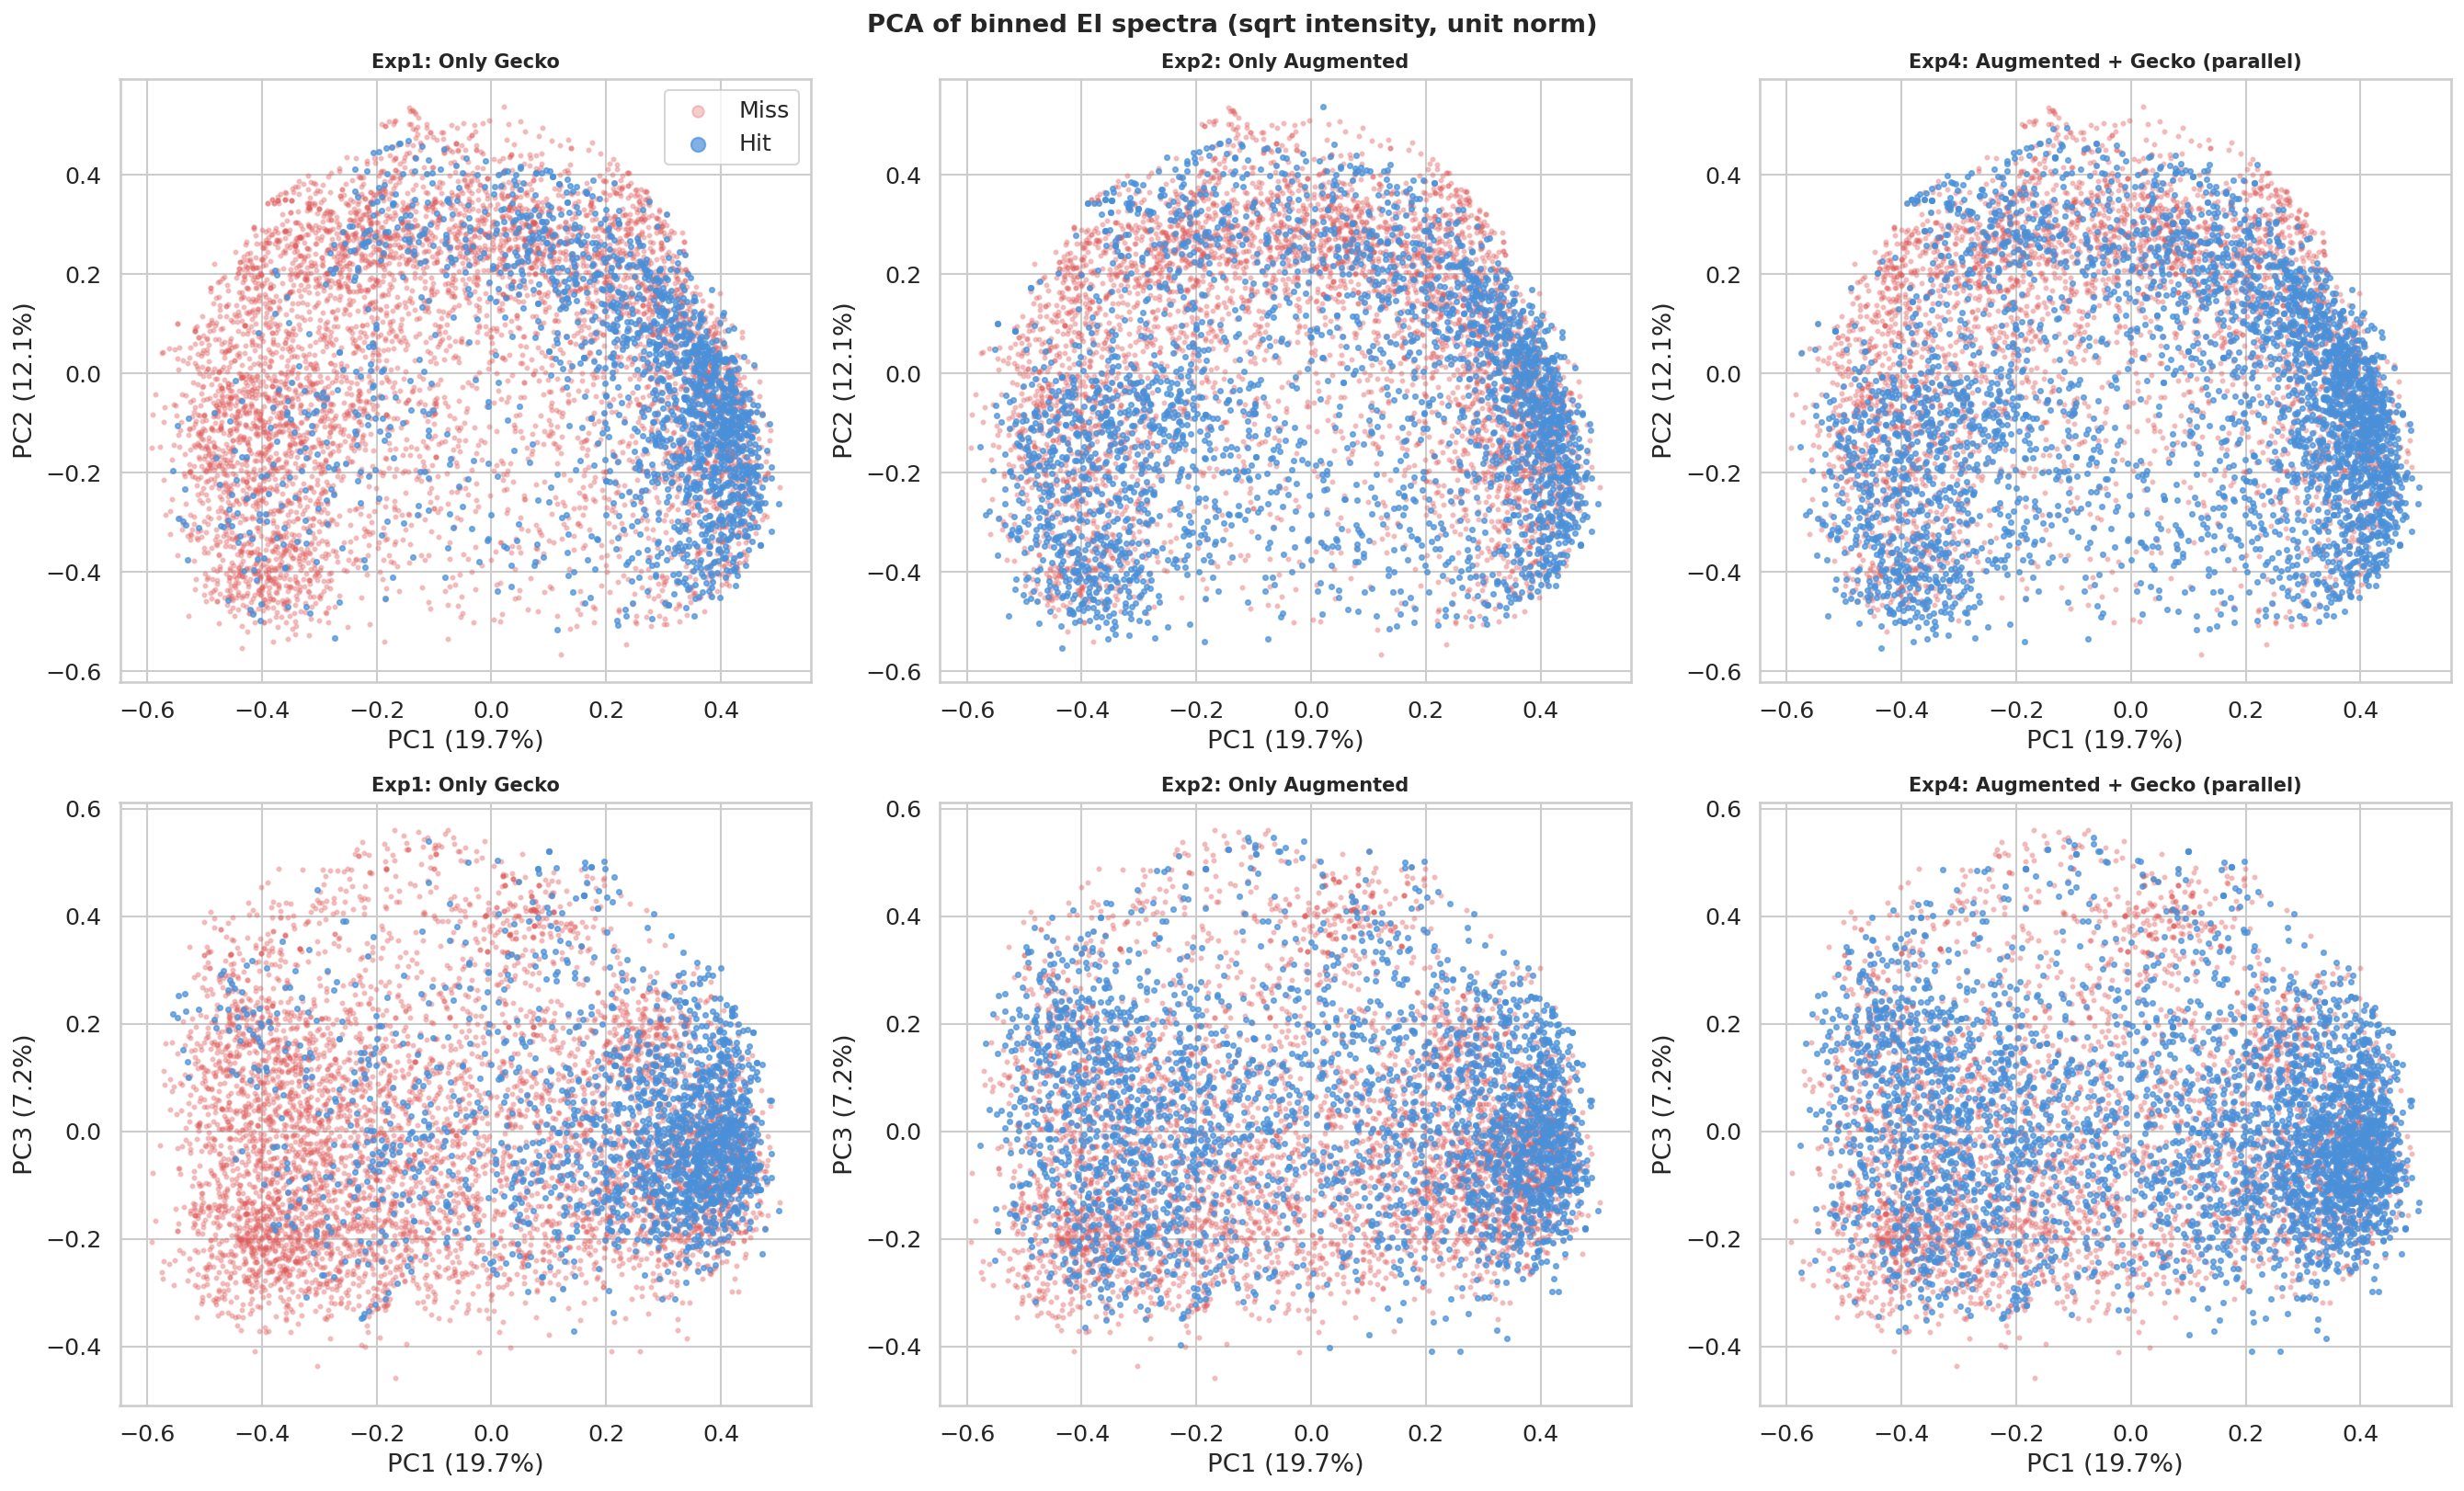

[Exp4: Augmented + Gecko (parallel)] spectral PC loadings


,PC,var,top + m/z,top − m/z,ρ with hit10
0,PC1,0.197,"43, 29, 31, 45, 42, 57, 27, 44","77, 79, 65, 91, 78, 93, 51, 107",0.205
1,PC2,0.121,"69, 55, 83, 70, 71, 56, 57, 84","63, 76, 75, 46, 62, 15, 64, 77",-0.247
2,PC3,0.072,"39, 41, 53, 51, 27, 52, 38, 54","45, 73, 59, 87, 60, 101, 74, 88",0.056
3,PC4,0.040,"57, 39, 89, 103, 102, 56, 87, 115","31, 81, 95, 109, 45, 96, 82, 110",-0.073
4,PC5,0.035,"43, 91, 59, 41, 107, 121, 105, 55","50, 100, 51, 113, 99, 49, 127, 37",-0.058


In [14]:
exp_spec_pca = {}
fig, axes = plt.subplots(2, len(exp_dfs), figsize=(6 * len(exp_dfs), 11), dpi=PLOT_DPI)
for col_i, (exp_name, adf) in enumerate(exp_dfs.items()):
    X = test_binned[adf['spec_idx'].values]
    keep = X.std(axis=0) > 0
    pca = PCA(n_components=10, random_state=42)
    pcs = pca.fit_transform(X[:, keep])
    exp_spec_pca[exp_name] = {'pcs': pcs, 'pca': pca, 'mz': np.arange(MAX_MZ + 1)[keep], 'X': X}
    hit = adf[HIT].values
    for row, (i, j) in enumerate([(0, 1), (0, 2)]):
        ax = axes[row, col_i]
        ax.scatter(pcs[~hit, i], pcs[~hit, j], s=4, alpha=0.3, color=MISS_COLOR, label='Miss', rasterized=True)
        ax.scatter(pcs[hit, i],  pcs[hit, j],  s=6, alpha=0.7, color=HIT_COLOR,  label='Hit',  rasterized=True)
        ev = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC{i+1} ({ev[i]:.1%})'); ax.set_ylabel(f'PC{j+1} ({ev[j]:.1%})')
        ax.set_title(exp_name, fontsize=10, fontweight='bold')
axes[0, 0].legend(markerscale=3)
plt.suptitle('PCA of binned EI spectra (sqrt intensity, unit norm)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/spectral_PCA_top{TOP_K}.png', bbox_inches='tight')
plt.show()

# Loadings: the m/z values that define each PC (same for every experiment up to sign; show the reference exp)
res = exp_spec_pca[EXP_REF]
rows = []
for k in range(5):
    load = res['pca'].components_[k]
    pos = res['mz'][np.argsort(load)[::-1][:8]]
    neg = res['mz'][np.argsort(load)[:8]]
    rho_hit = stats.spearmanr(res['pcs'][:, k], exp_dfs[EXP_REF][HIT])[0]
    rows.append({'PC': f'PC{k+1}', 'var': res['pca'].explained_variance_ratio_[k],
                 'top + m/z': ', '.join(map(str, pos)), 'top − m/z': ', '.join(map(str, neg)),
                 f'ρ with hit{TOP_K}': rho_hit})
print(f'[{EXP_REF}] spectral PC loadings')
display(pd.DataFrame(rows).round(3))

In [15]:
exp_best_k = {}
for exp_name in exp_dfs:
    X = exp_spec_pca[exp_name]['pcs']
    sils = []
    for k in range(2, 11):
        lab = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
        sils.append(silhouette_score(X, lab, sample_size=min(5000, len(X)), random_state=42))
    exp_best_k[exp_name] = int(np.argmax(sils)) + 2
    print(f'{exp_name}: silhouette per k=2..10: {np.round(sils, 3)} → best k = {exp_best_k[exp_name]}')

# Override k per experiment here if needed, e.g. exp_best_k['Exp1: Only Gecko'] = 6
# Silhouette tends to favour very small k; a slightly larger k gives more interpretable spectral families.
K_OVERRIDE = 6
exp_best_k = {e: max(k, K_OVERRIDE) for e, k in exp_best_k.items()}

exp_spec_clusters = {}
for exp_name, adf in exp_dfs.items():
    K = exp_best_k[exp_name]
    km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(exp_spec_pca[exp_name]['pcs'])
    adf['spec_cluster'] = km.labels_
    X = exp_spec_pca[exp_name]['X']
    # Characteristic ions per cluster = largest mean binned intensity
    top_ions = {c: ', '.join(map(str, np.argsort(X[km.labels_ == c].mean(0))[::-1][:6])) for c in range(K)}
    cs = adf.groupby('spec_cluster').agg(
        n=(HIT, 'size'), **{f'hit_rate_top{k}': (f'hit_top{k}', 'mean') for k in K_REPORT},
        tanimoto_top1=('tanimoto_top1', 'mean'), MW=('MW', 'median'), nO=('nO', 'mean'), nN=('nN', 'mean'),
        ArRings=('ArRings', 'mean'), M_rel_inten=('M_rel_inten', 'median'), Entropy=('Entropy', 'median'),
        NOx=('NOx_inten_frac', 'mean'))
    cs['top ions'] = pd.Series(top_ions)
    cs = cs.sort_values(HR)
    exp_spec_clusters[exp_name] = cs
    print(f'\n=== {exp_name}: spectral clusters (k={K}), sorted hardest → easiest ===')
    display(cs.round(3))

Exp1: Only Gecko: silhouette per k=2..10: [0.267 0.252 0.221 0.22  0.209 0.206 0.2   0.199 0.188] → best k = 2
Exp2: Only Augmented: silhouette per k=2..10: [0.267 0.252 0.221 0.22  0.209 0.206 0.2   0.199 0.188] → best k = 2
Exp4: Augmented + Gecko (parallel): silhouette per k=2..10: [0.267 0.252 0.221 0.22  0.209 0.206 0.2   0.199 0.188] → best k = 2

=== Exp1: Only Gecko: spectral clusters (k=6), sorted hardest → easiest ===


,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
2,839,0.043,0.082,0.154,240.046,2.279,0.309,1.373,68.869,4.111,0.003,"51, 63, 50, 77, 69, 75"
0,1083,0.033,0.091,0.166,152.998,1.699,0.441,0.946,62.663,3.738,0.005,"77, 51, 39, 65, 91, 63"
3,1616,0.072,0.128,0.297,216.100,3.577,0.283,0.087,5.906,4.255,0.006,"43, 41, 55, 69, 57, 71"
1,1208,0.094,0.223,0.249,126.123,1.250,0.186,0.036,17.417,3.375,0.009,"41, 43, 55, 39, 57, 27"
5,1803,0.210,0.419,0.423,146.058,3.543,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
4,939,0.243,0.463,0.422,120.079,3.563,0.433,0.001,0.000,3.184,0.069,"43, 29, 45, 27, 31, 44"



=== Exp2: Only Augmented: spectral clusters (k=6), sorted hardest → easiest ===


,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
3,1616,0.106,0.215,0.355,216.100,3.577,0.283,0.087,5.906,4.255,0.006,"43, 41, 55, 69, 57, 71"
1,1208,0.159,0.341,0.330,126.123,1.250,0.186,0.036,17.417,3.375,0.009,"41, 43, 55, 39, 57, 27"
5,1803,0.170,0.373,0.396,146.058,3.543,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
2,839,0.197,0.422,0.421,240.046,2.279,0.309,1.373,68.869,4.111,0.003,"51, 63, 50, 77, 69, 75"
0,1083,0.254,0.493,0.442,152.998,1.699,0.441,0.946,62.663,3.738,0.005,"77, 51, 39, 65, 91, 63"
4,939,0.262,0.526,0.450,120.079,3.563,0.433,0.001,0.000,3.184,0.069,"43, 29, 45, 27, 31, 44"



=== Exp4: Augmented + Gecko (parallel): spectral clusters (k=6), sorted hardest → easiest ===


,n,hit_rate_top1,hit_rate_top10,tanimoto_top1,MW,nO,nN,ArRings,M_rel_inten,Entropy,NOx,top ions
spec_cluster,,,,,,,,,,,,
3,1616,0.134,0.285,0.397,216.100,3.577,0.283,0.087,5.906,4.255,0.006,"43, 41, 55, 69, 57, 71"
1,1208,0.180,0.376,0.342,126.123,1.250,0.186,0.036,17.417,3.375,0.009,"41, 43, 55, 39, 57, 27"
2,839,0.203,0.431,0.427,240.046,2.279,0.309,1.373,68.869,4.111,0.003,"51, 63, 50, 77, 69, 75"
0,1083,0.269,0.517,0.452,152.998,1.699,0.441,0.946,62.663,3.738,0.005,"77, 51, 39, 65, 91, 63"
5,1803,0.295,0.594,0.509,146.058,3.543,0.298,0.001,0.000,3.526,0.027,"43, 41, 57, 29, 45, 42"
4,939,0.357,0.708,0.528,120.079,3.563,0.433,0.001,0.000,3.184,0.069,"43, 29, 45, 27, 31, 44"



=== Exp1: Only Gecko ===
Hardest spectral cluster C2 (hit10 = 0.082) — misses


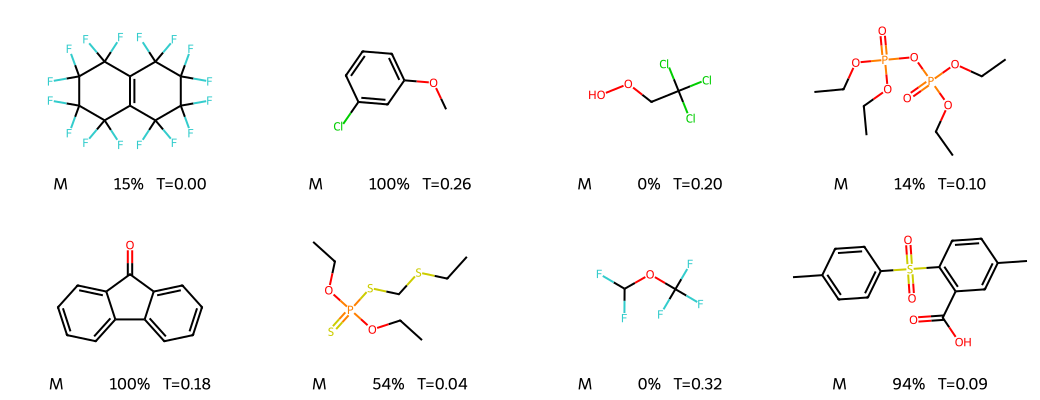

Easiest spectral cluster C4 (hit10 = 0.463) — hits


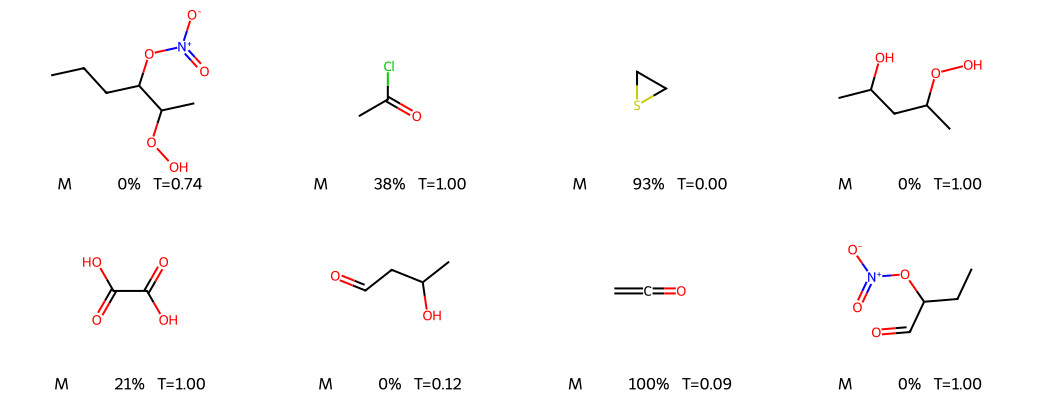


=== Exp2: Only Augmented ===
Hardest spectral cluster C3 (hit10 = 0.215) — misses


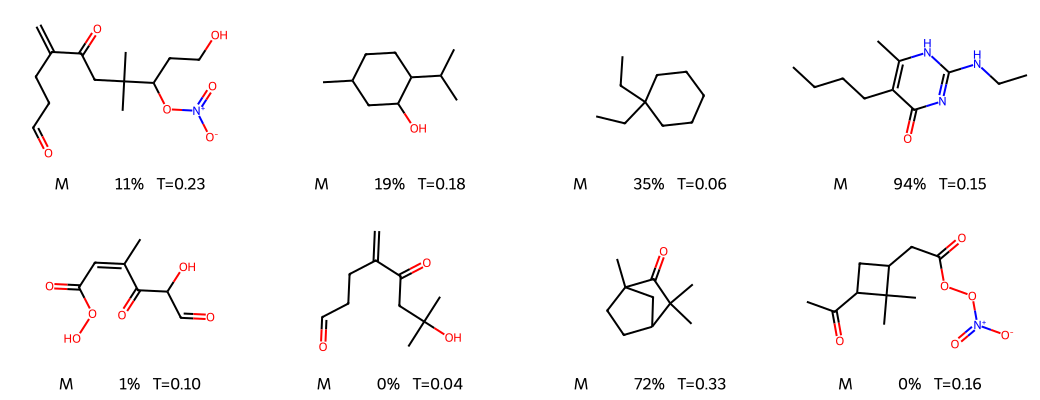

Easiest spectral cluster C4 (hit10 = 0.526) — hits


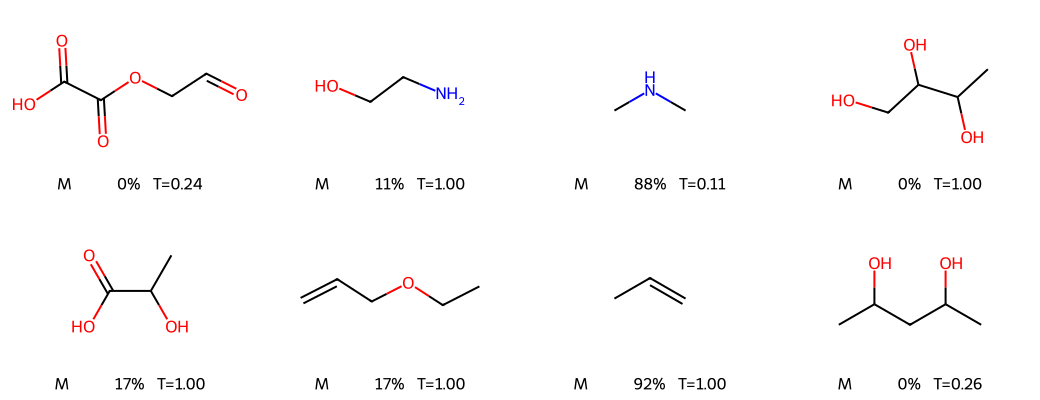


=== Exp4: Augmented + Gecko (parallel) ===
Hardest spectral cluster C3 (hit10 = 0.285) — misses


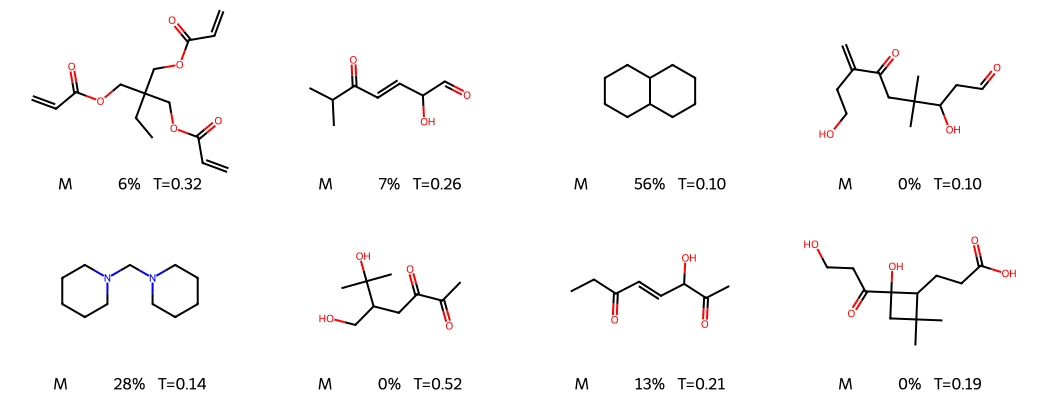

Easiest spectral cluster C4 (hit10 = 0.708) — hits


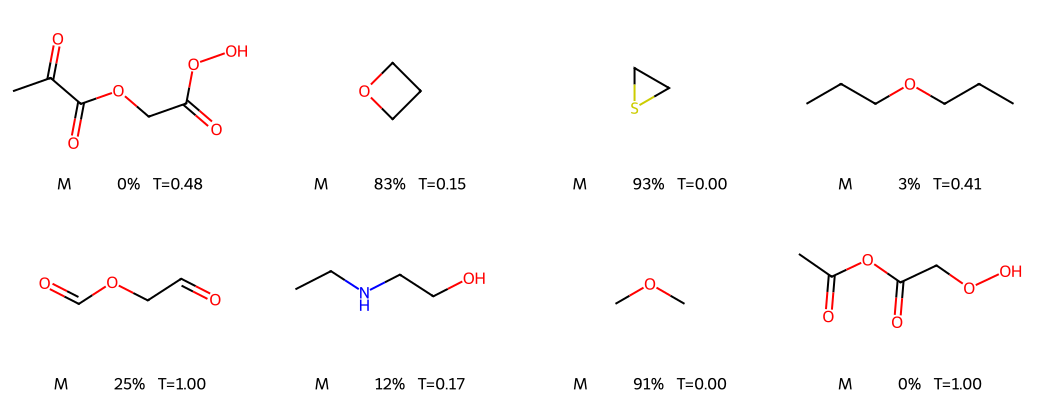

In [16]:
def draw_cluster_examples(adf, cluster_id, hit_filter, n=8, seed=0):
    idx = adf.index[(adf['spec_cluster'] == cluster_id) & (adf[HIT] == hit_filter)].tolist()
    if not idx:
        print('  No molecules found.'); return None
    idx = np.random.default_rng(seed).choice(idx, min(n, len(idx)), replace=False)
    mols = [test_spec['mol'].iloc[adf.loc[i, 'spec_idx']] for i in idx]
    return Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(260, 200),
                                legends=[f"M⁺ {adf.loc[i, 'M_rel_inten']:.0f}%  T={adf.loc[i, 'tanimoto_top1']:.2f}" for i in idx])

for exp_name, adf in exp_dfs.items():
    cs = exp_spec_clusters[exp_name]
    hardest, easiest = cs.index[0], cs.index[-1]
    print(f'\n=== {exp_name} ===\nHardest spectral cluster C{hardest} (hit{TOP_K} = {cs.loc[hardest, HR]:.3f}) — misses')
    img = draw_cluster_examples(adf, hardest, False)
    if img: display(img)
    print(f'Easiest spectral cluster C{easiest} (hit{TOP_K} = {cs.loc[easiest, HR]:.3f}) — hits')
    img = draw_cluster_examples(adf, easiest, True)
    if img: display(img)

## 10. Spectral novelty and ambiguity: nearest neighbours in the training library
For every test spectrum we find its most similar training spectrum (cosine on the binned representation) separately
in the `gecko_new` and `mix_aug` libraries, and compute the **structural** Tanimoto between the test molecule and that
nearest spectral neighbour.

* **NN cosine** — how novel the spectrum is relative to what the model has seen.
* **NN structural Tanimoto** — whether spectral similarity implies structural similarity. A test spectrum whose closest
  training spectrum belongs to a *different* structure is intrinsically ambiguous.

`EXP_TRAIN_LIBS` states which library each experiment was trained on (edit if this assumption is wrong). Only
rows marked `train` in `split_random_guarded.tsv` are used; validation rows and the `mix_aug` spectra the guard
removed for overlapping the test set are excluded. Results are cached.

In [17]:
EXP_TRAIN_LIBS = {
    'Exp1: Only Gecko': ['gecko_new'],
    'Exp2: Only Augmented': ['mix_aug'],
    'Exp3: Augmented + Gecko (sequential)': ['gecko_new', 'mix_aug'],
    'Exp4: Augmented + Gecko (parallel)': ['gecko_new', 'mix_aug'],
}
NN_CACHE = f'{OUT_DIR}/spectral_nn_cache_train.npz'
# The nearest neighbours depend only on the spectra and the split, not on the predictions, so the cache written by
# the non-DDP notebook is reused when present (its length check below still guards against a mismatch)
_nn_cache_nonddp = NN_CACHE.replace(OUT_DIR, 'spectral_difficulty_analysis', 1)
if not os.path.exists(NN_CACHE) and os.path.exists(_nn_cache_nonddp):
    import shutil
    shutil.copy(_nn_cache_nonddp, NN_CACHE)
    print(f'Copied nearest-neighbour cache from {_nn_cache_nonddp}')
CHUNK = 10_000

nn = dict(np.load(NN_CACHE, allow_pickle=True)) if os.path.exists(NN_CACHE) else {}
if nn and all(len(nn[f'{lib}_cos']) == len(test_binned) for lib in REF_PREFIXES):
    print(f'Loaded cached nearest neighbours from {NN_CACHE}')
else:
    nn = {}
    for lib in REF_PREFIXES:
        ref = spec_df[(spec_df['prefix'] == lib) & (spec_df['split'] == 'train')]
        best = np.full(len(test_binned), -1.0, dtype=np.float32)
        arg  = np.zeros(len(test_binned), dtype=np.int64)
        for start in range(0, len(ref), CHUNK):
            R = bin_spectra(list(ref['spec'].iloc[start:start + CHUNK]))
            S = test_binned @ R.T
            j = S.argmax(1)
            s = S[np.arange(len(S)), j]
            upd = s > best
            best[upd], arg[upd] = s[upd], start + j[upd]
        nn[f'{lib}_cos'] = best
        nn[f'{lib}_smiles'] = ref['SMILES'].values[arg].astype(object)
        print(f'{lib}: {len(ref):,} reference spectra, median NN cosine {np.median(best):.3f}')
    np.savez(NN_CACHE, **nn)

# Structural Tanimoto between each test molecule and its nearest spectral neighbour
test_fps = [morgan_fp(m) for m in test_spec['mol']]
for lib in REF_PREFIXES:
    sims = []
    for fp, smi in zip(test_fps, nn[f'{lib}_smiles']):
        m = Chem.MolFromSmiles(smi)
        sims.append(DataStructs.TanimotoSimilarity(fp, morgan_fp(m)) if m else np.nan)
    nn[f'{lib}_tan'] = np.array(sims)
    print(f'{lib}: identical structure found as NN for {(nn[lib + "_tan"] == 1).sum()} test spectra')

for exp_name, adf in exp_dfs.items():
    libs = EXP_TRAIN_LIBS[exp_name]
    cos = np.column_stack([nn[f'{l}_cos'][adf['spec_idx']] for l in libs])
    tan = np.column_stack([nn[f'{l}_tan'][adf['spec_idx']] for l in libs])
    pick = cos.argmax(1)
    adf['NN_cosine']   = cos[np.arange(len(adf)), pick]
    adf['NN_tanimoto'] = tan[np.arange(len(adf)), pick]
    r_cos = stats.spearmanr(adf['NN_cosine'], adf[HIT])[0]
    r_tan = stats.spearmanr(adf['NN_tanimoto'], adf[HIT])[0]
    print(f'{exp_name} (libs: {"+".join(libs)}): median NN cosine={adf.NN_cosine.median():.3f}  '
          f'ρ(NN cosine, hit{TOP_K})={r_cos:+.3f}  ρ(NN tanimoto, hit{TOP_K})={r_tan:+.3f}')

gecko_new: 171,504 reference spectra, median NN cosine 0.893
mix_aug: 282,295 reference spectra, median NN cosine 0.914
gecko_new: identical structure found as NN for 0 test spectra
mix_aug: identical structure found as NN for 55 test spectra
Exp1: Only Gecko (libs: gecko_new): median NN cosine=0.893  ρ(NN cosine, hit10)=+0.309  ρ(NN tanimoto, hit10)=+0.370
Exp2: Only Augmented (libs: mix_aug): median NN cosine=0.914  ρ(NN cosine, hit10)=-0.042  ρ(NN tanimoto, hit10)=+0.262
Exp4: Augmented + Gecko (parallel) (libs: gecko_new+mix_aug): median NN cosine=0.924  ρ(NN cosine, hit10)=-0.010  ρ(NN tanimoto, hit10)=+0.247


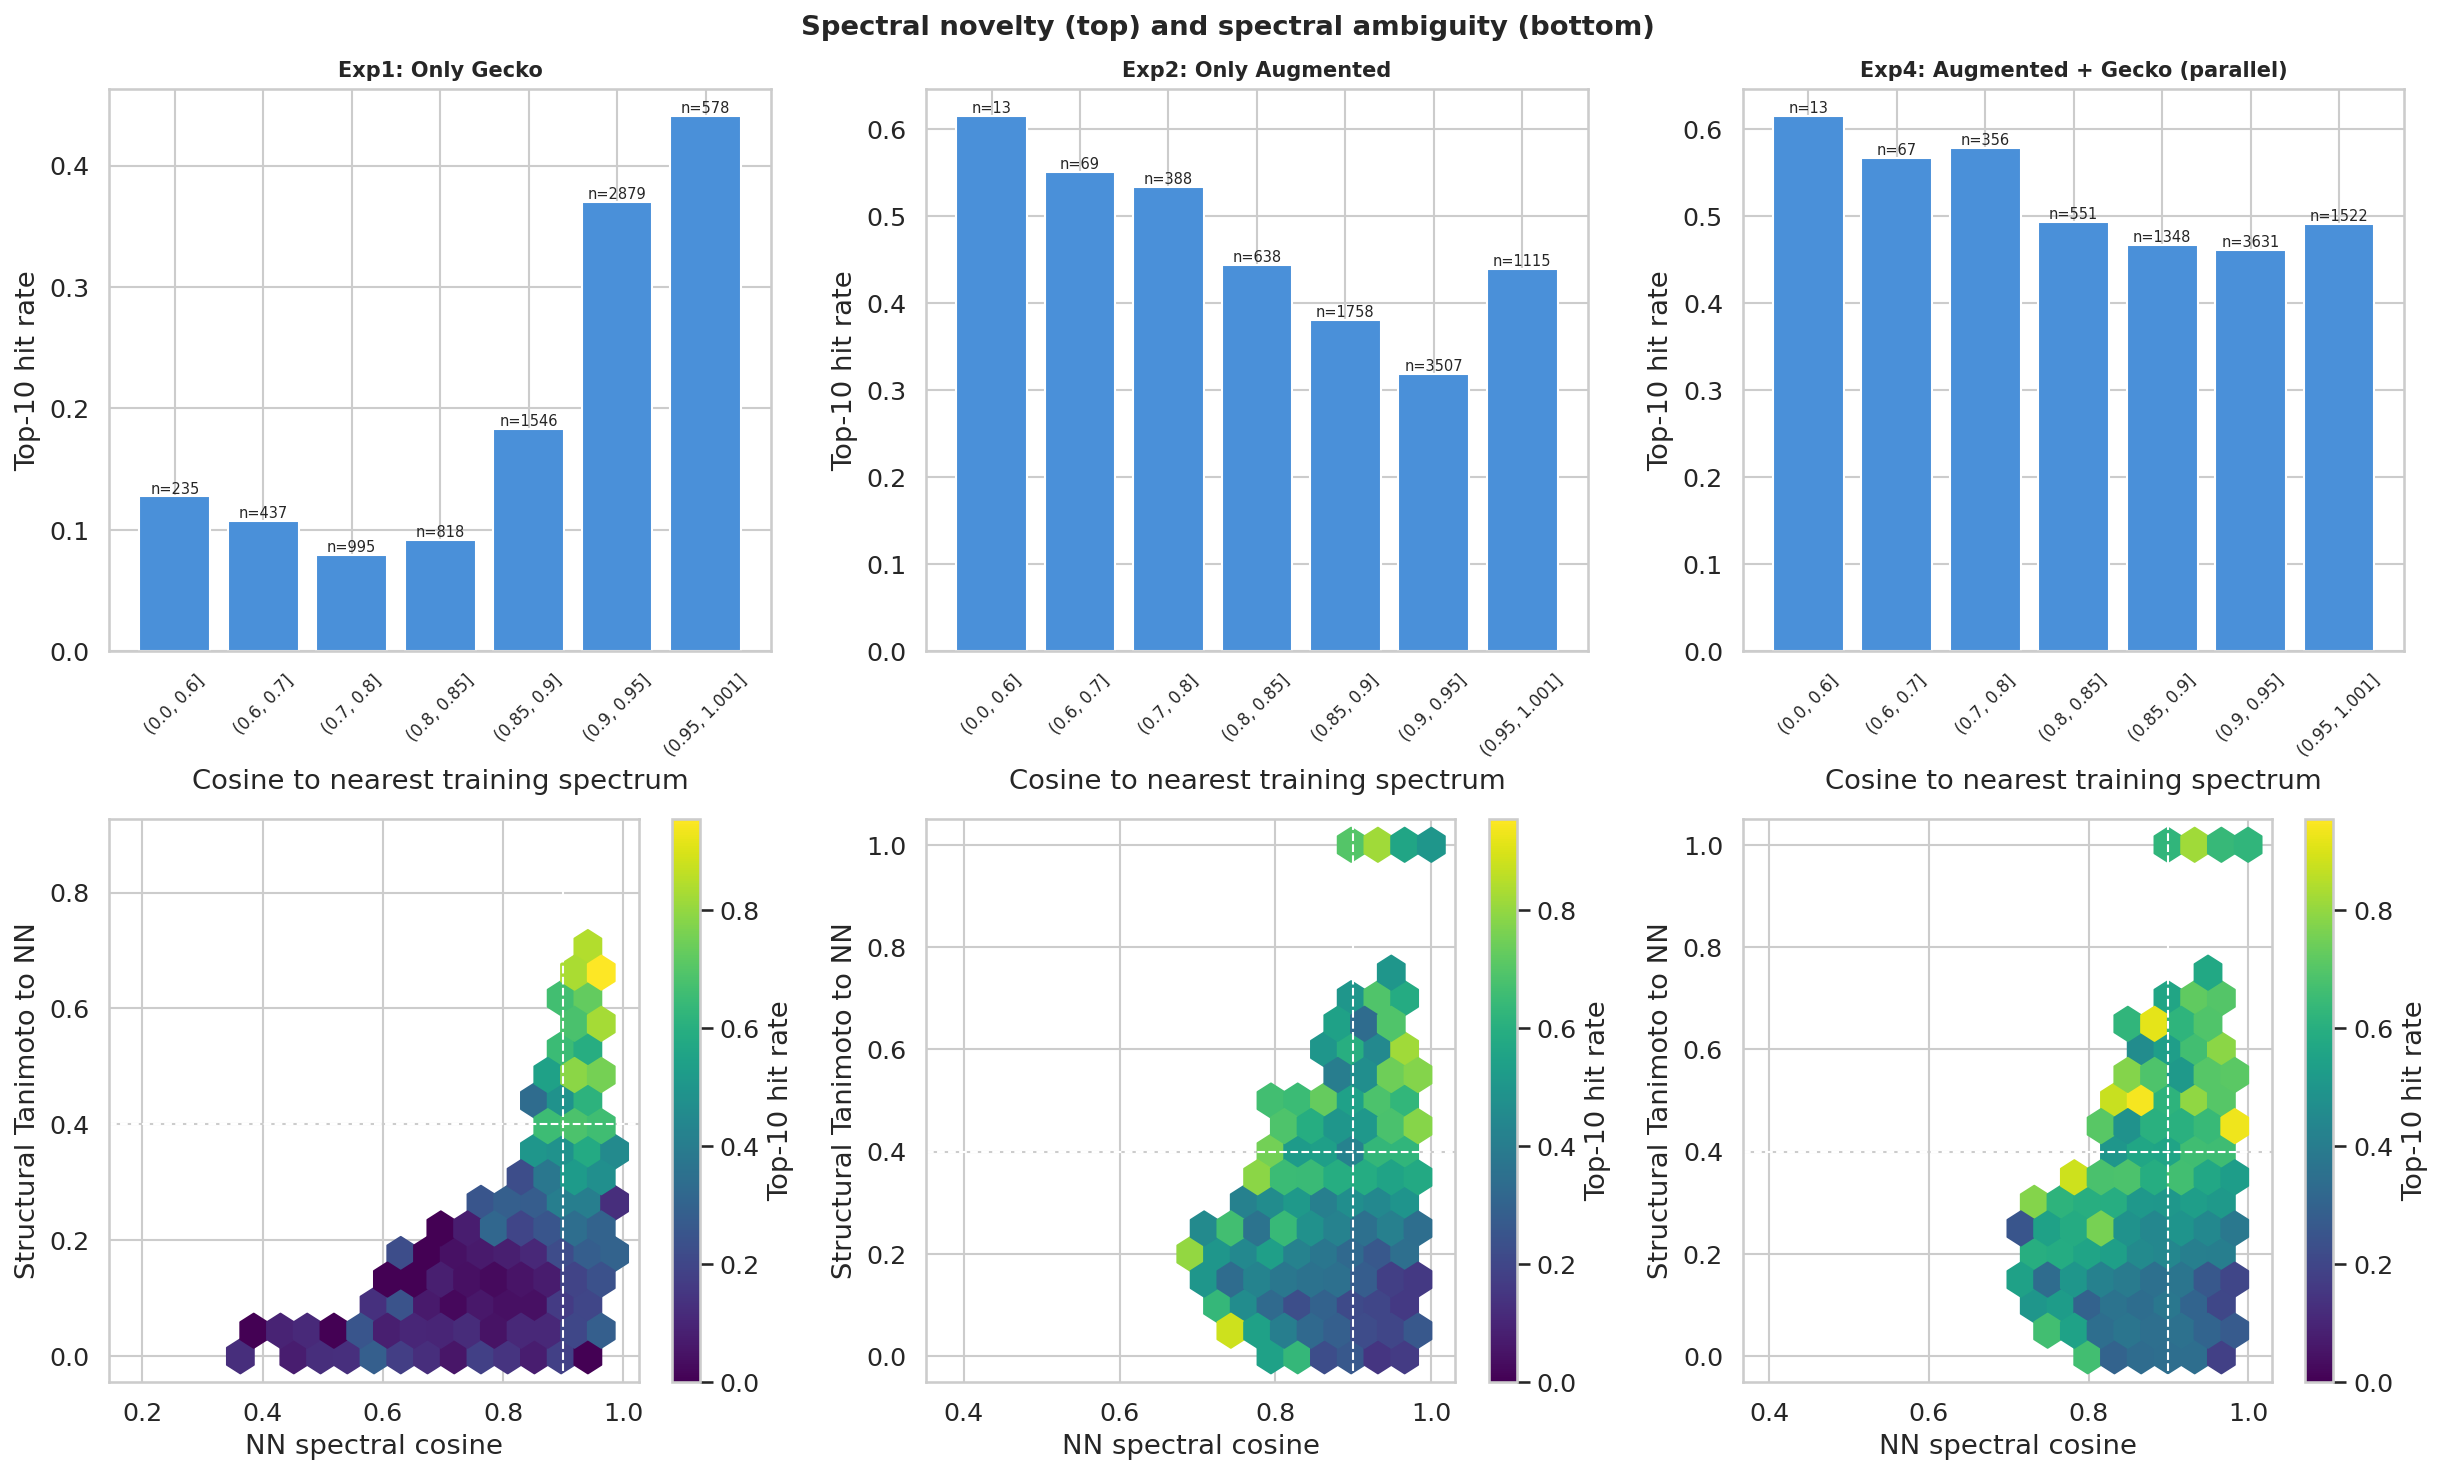

Exp1: Only Gecko


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        2973  0.330     0.373
                         similar structure (T≥0.4)   484  0.702     0.640
far spectrum             different structure        3936  0.116     0.198
                         similar structure (T≥0.4)    95  0.621     0.540

Exp2: Only Augmented


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        3884  0.292     0.330
                         similar structure (T≥0.4)   738  0.644     0.633
far spectrum             different structure        2551  0.400     0.394
                         similar structure (T≥0.4)   315  0.587     0.593

Exp4: Augmented + Gecko (parallel)


n  hit10  tanimoto
spectral                 structure                                       
close spectrum (cos≥0.9) different structure        4085  0.413     0.388
                         similar structure (T≥0.4)  1068  0.687     0.643
far spectrum             different structure        2028  0.472     0.420
                         similar structure (T≥0.4)   307  0.635     0.630

In [18]:
COS_BINS = [0, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.001]
fig, axes = plt.subplots(2, len(exp_dfs), figsize=(5.5 * len(exp_dfs), 10), dpi=PLOT_DPI)
for col_i, (exp_name, adf) in enumerate(exp_dfs.items()):
    # Top: hit rate vs NN cosine
    ax = axes[0, col_i]
    g = adf.groupby(pd.cut(adf.NN_cosine, COS_BINS), observed=True)[HIT].agg(['mean', 'count'])
    ax.bar(range(len(g)), g['mean'], color=HIT_COLOR)
    for i, n in enumerate(g['count']):
        ax.text(i, g['mean'].iloc[i], f'n={n}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(range(len(g))); ax.set_xticklabels([str(iv) for iv in g.index], rotation=45, fontsize=8)
    ax.set_xlabel('Cosine to nearest training spectrum'); ax.set_ylabel(f'Top-{TOP_K} hit rate')
    ax.set_title(exp_name, fontsize=10, fontweight='bold')

    # Bottom: spectral vs structural similarity of the NN, coloured by hit rate
    ax = axes[1, col_i]
    hb = ax.hexbin(adf.NN_cosine, adf.NN_tanimoto, C=adf[HIT].astype(float), reduce_C_function=np.mean,
                   gridsize=18, cmap='viridis', mincnt=8, vmin=0, vmax=min(1.0, 2 * max(d[HIT].mean() for d in exp_dfs.values())))
    ax.axvline(0.9, color='w', ls='--', lw=1); ax.axhline(0.4, color='w', ls='--', lw=1)
    ax.set_xlabel('NN spectral cosine'); ax.set_ylabel('Structural Tanimoto to NN')
    plt.colorbar(hb, ax=ax, label=f'Top-{TOP_K} hit rate')
plt.suptitle('Spectral novelty (top) and spectral ambiguity (bottom)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/nn_novelty_ambiguity_top{TOP_K}.png', bbox_inches='tight')
plt.show()

# Quadrant table: spectrally close/far × structurally close/far
for exp_name, adf in exp_dfs.items():
    q = adf.assign(spectral=np.where(adf.NN_cosine >= 0.9, 'close spectrum (cos≥0.9)', 'far spectrum'),
                   structure=np.where(adf.NN_tanimoto >= 0.4, 'similar structure (T≥0.4)', 'different structure'))
    print(exp_name)
    display(q.groupby(['spectral', 'structure']).agg(n=(HIT, 'size'), **{f'hit{TOP_K}': (HIT, 'mean')},
                                                     tanimoto=('tanimoto_top1', 'mean')).round(3))

In [19]:
# Does NN information add predictive value on top of molecular + spectral summary features?
NN_COLS = ['NN_cosine', 'NN_tanimoto']
FEATURE_SETS_NN = {'molecular': MOL_COLS, 'combined': MOL_COLS + SPEC_COLS,
                   'combined + NN': MOL_COLS + SPEC_COLS + NN_COLS, 'NN only': NN_COLS}
rows = []
for exp_name, adf in exp_dfs.items():
    y = adf[HIT].astype(int).values
    for fs_name, cols in FEATURE_SETS_NN.items():
        clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                             l2_regularization=1.0, random_state=42)
        prob = cross_val_predict(clf, adf[cols].values, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 method='predict_proba')[:, 1]
        rows.append({'Experiment': exp_name.split(':')[0], 'Features': fs_name,
                     'ROC-AUC': roc_auc_score(y, prob), 'AP': average_precision_score(y, prob)})
display(pd.DataFrame(rows).pivot(index='Features', columns='Experiment', values='ROC-AUC')
        .loc[list(FEATURE_SETS_NN)].round(3))

Experiment,Exp1,Exp2,Exp4
Features,,,
molecular,0.950,0.930,0.897
combined,0.948,0.930,0.896
combined + NN,0.946,0.929,0.896
NN only,0.779,0.681,0.654


## 11. Example spectra: hits vs misses of similar mass
Stick spectra of randomly chosen hits and misses in the same MW window, so the contrast isn't driven by size. Dashed line = M.

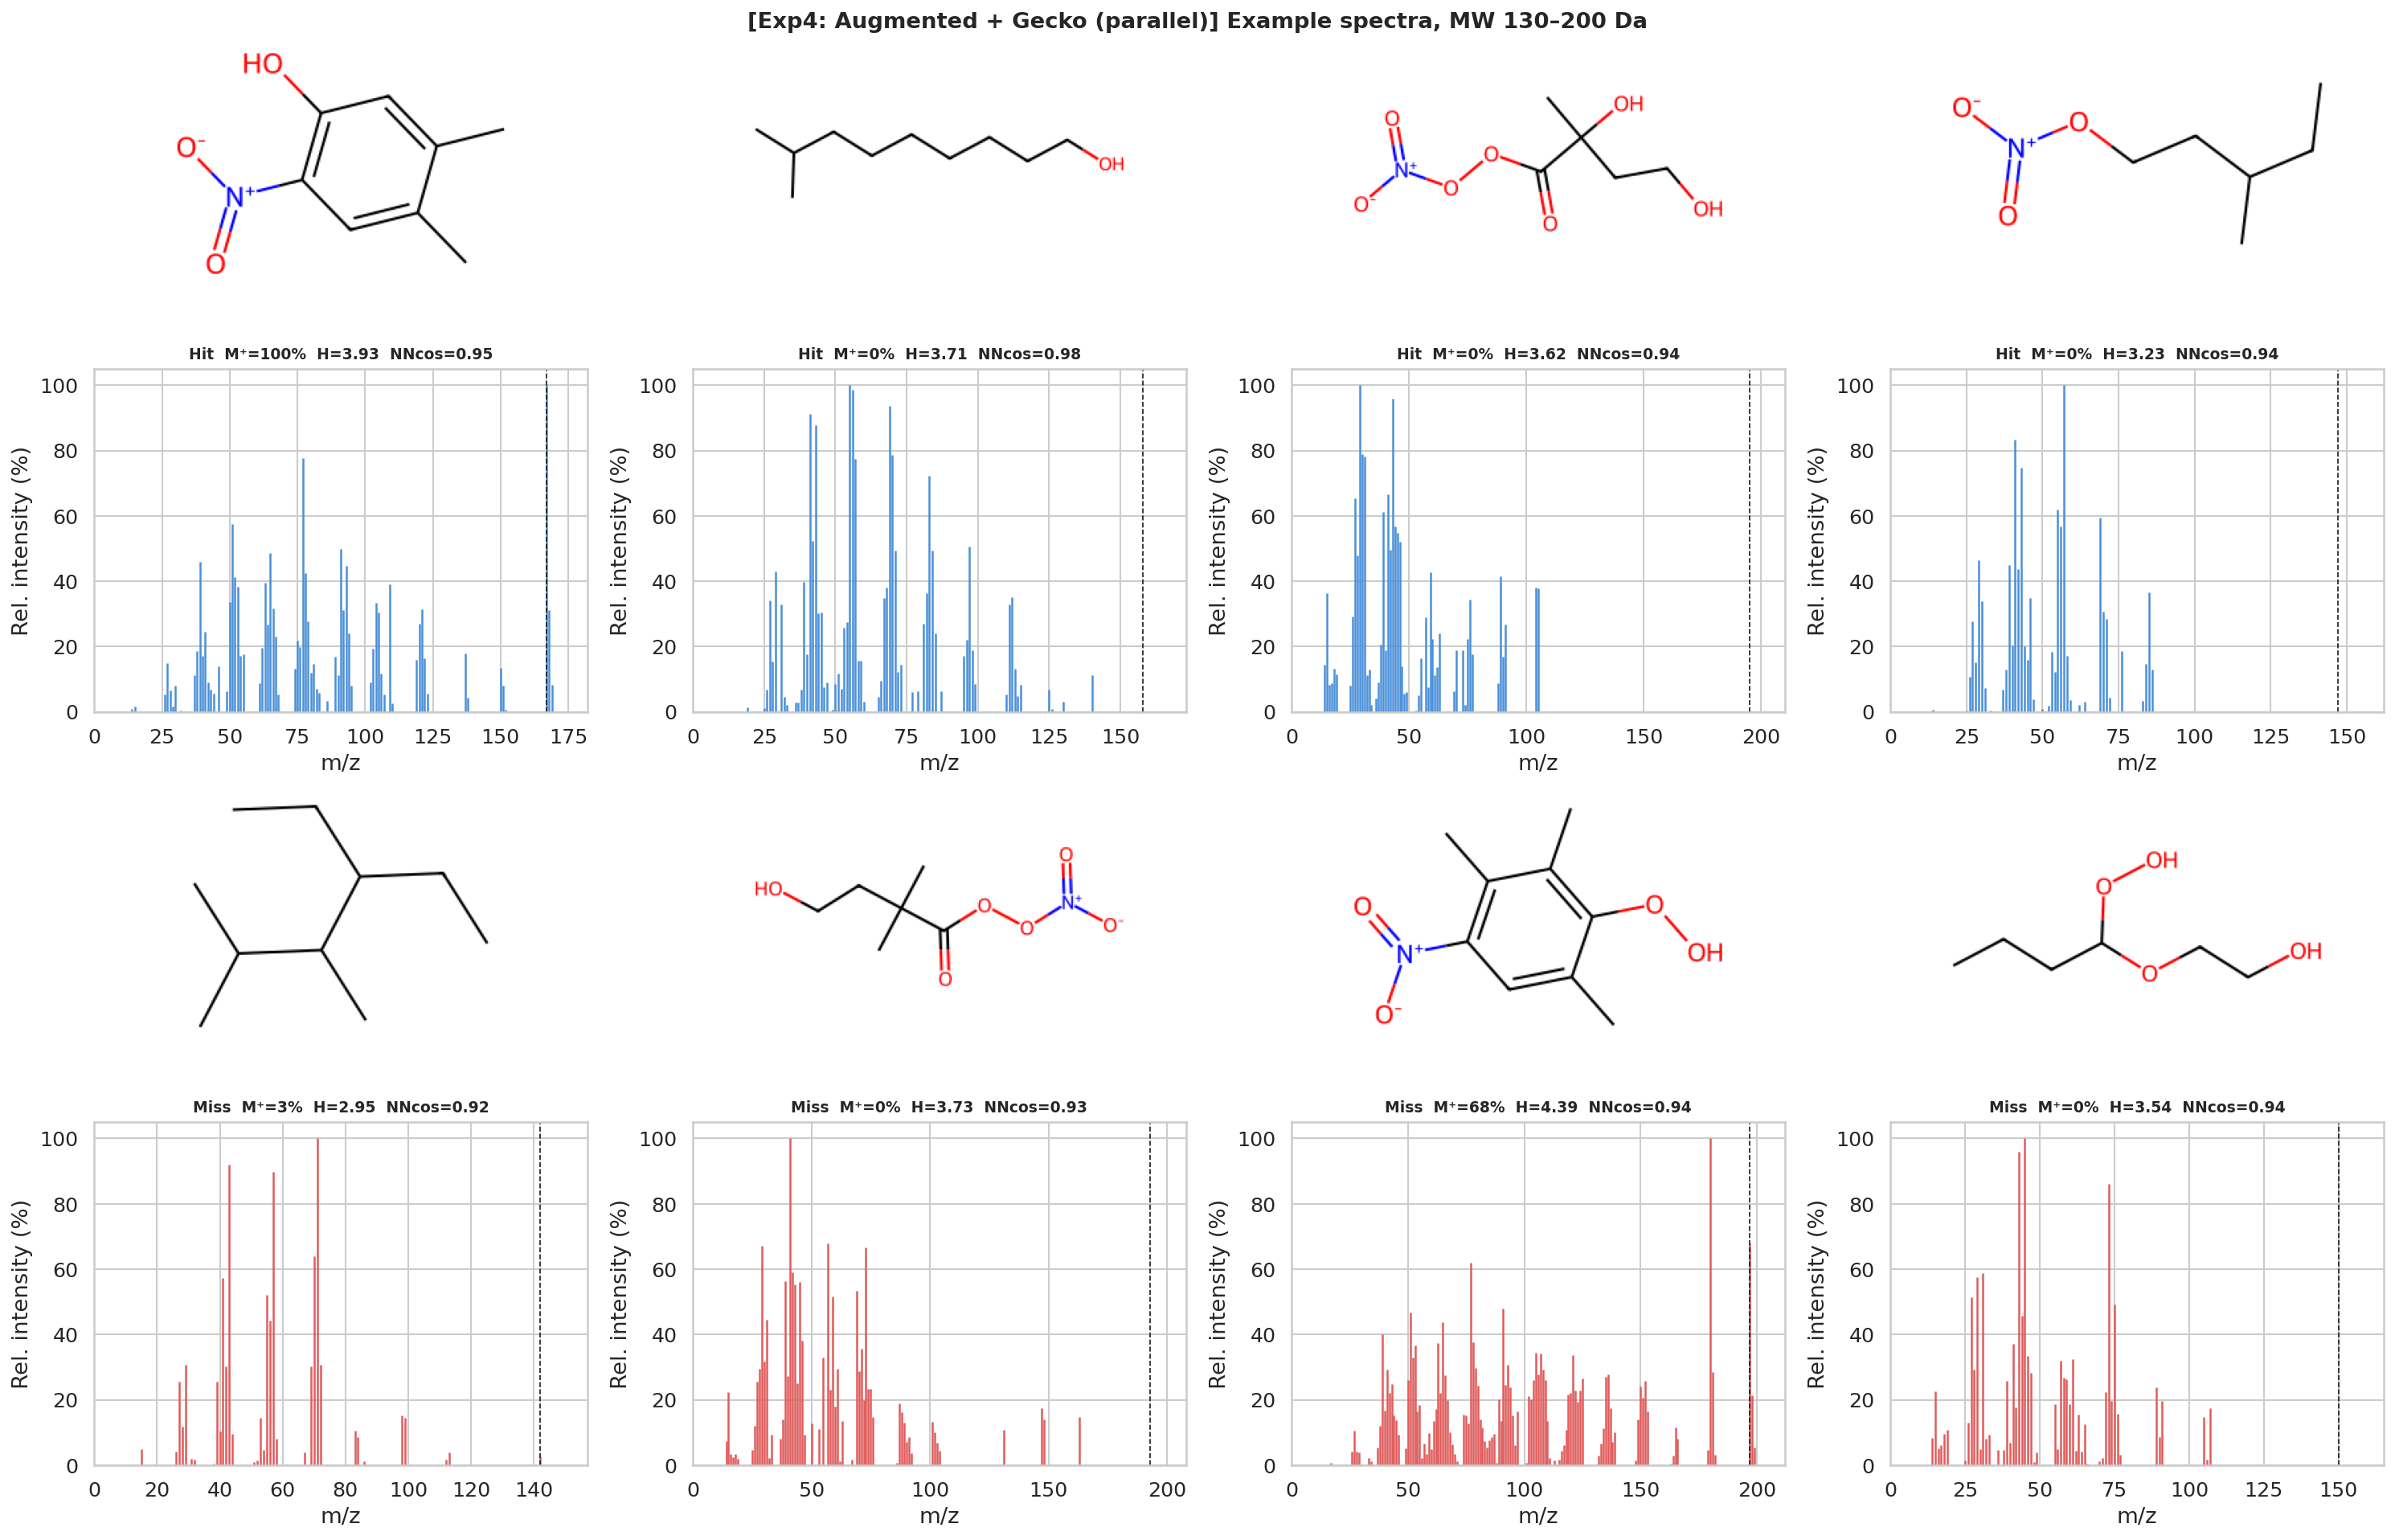

In [20]:
EXAMPLE_EXP = 'Exp4: Augmented + Gecko (parallel)'
MW_WINDOW   = (130, 200)
N_EACH      = 4

adf = exp_dfs[EXAMPLE_EXP]
win = adf[adf.MW.between(*MW_WINDOW)]
rng = np.random.default_rng(1)
picks = {'Hit': rng.choice(win.index[win[HIT]], N_EACH, replace=False),
         'Miss': rng.choice(win.index[~win[HIT]], N_EACH, replace=False)}

fig, axes = plt.subplots(4, N_EACH, figsize=(5 * N_EACH, 13), dpi=PLOT_DPI,
                         gridspec_kw={'height_ratios': [1, 1.4, 1, 1.4]})
for row, (label, idxs) in enumerate(picks.items()):
    for col, i in enumerate(idxs):
        r = adf.loc[i]
        spec, mol = test_spec['spec'].iloc[r.spec_idx], test_spec['mol'].iloc[r.spec_idx]
        ax_mol, ax = axes[2 * row, col], axes[2 * row + 1, col]
        ax_mol.imshow(Draw.MolToImage(mol, size=(300, 180))); ax_mol.axis('off')
        rel = 100 * spec[:, 1] / spec[:, 1].max()
        ax.vlines(spec[:, 0], 0, rel, color=HIT_COLOR if label == 'Hit' else MISS_COLOR, lw=1.2)
        ax.axvline(r.NominalMass, color='k', ls='--', lw=0.8)
        ax.set_xlim(0, r.NominalMass + 15); ax.set_ylim(0, 105)
        ax.set_title(f'{label}  M⁺={r.M_rel_inten:.0f}%  H={r.Entropy:.2f}  NNcos={r.NN_cosine:.2f}', fontsize=9, fontweight='bold')
        ax.set_xlabel('m/z'); ax.set_ylabel('Rel. intensity (%)')
plt.suptitle(f'[{EXAMPLE_EXP}] Example spectra, MW {MW_WINDOW[0]}–{MW_WINDOW[1]} Da', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/example_spectra_top{TOP_K}.png', bbox_inches='tight')
plt.show()

## 12. Save results

In [21]:
for exp_name, adf in exp_dfs.items():
    tag = exp_name.split(':')[0]
    exp_hm_stats[exp_name].to_csv(f'{OUT_DIR}/results_{tag}_spectral_hit_miss_top{TOP_K}.csv')
    exp_spec_clusters[exp_name].to_csv(f'{OUT_DIR}/results_{tag}_spectral_clusters_top{TOP_K}.csv')
    adf.drop(columns=['true_inchikey', 'true_inchi']).to_csv(f'{OUT_DIR}/results_{tag}_per_molecule.csv', index=False)
rho_mat.to_csv(f'{OUT_DIR}/results_spectral_tanimoto_rho.csv')
part_df.to_csv(f'{OUT_DIR}/results_partial_correlations_top{TOP_K}.csv', index=False)
ml_df.to_csv(f'{OUT_DIR}/results_difficulty_prediction_top{TOP_K}.csv', index=False)
print('Saved results to', OUT_DIR)

Saved results to spectral_difficulty_analysis_ddp


## 13. Findings

> **These findings are from the non-DDP runs** (`spectral_difficulty_analysis.ipynb`: 10 candidates per molecule,
> top-10 hits, top-1 Tanimoto on the first *sampled* candidate, partly different test sets per experiment). They are
> kept for reference and need to be re-checked against the DDP results above (100 ranked candidates, top-`TOP_K` hits,
> shared test set) before being reused.


**Data.** Spectra come from the cluster copy of `gecko_new_mixed_augment_atmomaccs_test` (the file the experiment configs
point to); the training libraries in Section 10 use the `train` rows of `split_random_guarded.tsv`. 99.1–99.2 % of test
molecules were linked to their NEIMS spectrum (by canonical SMILES, or by InChIKey for tautomers). The 60 unlinked molecules
have almost no hits, so dropping them does not bias the results. Molecular structure is described by 17 RDKit descriptors
plus 175 ATMOMACCS v5 keys (141 MACCS, 34 ATMO; constant and duplicate keys removed).

**1. Rich, complex spectra are harder, but this is mostly molecular size.** In every experiment, misses have more peaks
(median 63–64 vs 48), higher spectral entropy and a flatter intensity distribution (rank-biserial r ≈ −0.30 to −0.37). After
controlling for MW and heavy-atom count, these effects shrink from ρ ≈ −0.17 to −0.02…−0.10 (Section 7). A complex spectrum
mostly signals a large molecule, and size was already the main difficulty factor in the molecular notebook.

**2. Which spectra count as "easy" depends on the training data.**
* Models trained with GECKO (Exp1, Exp3) do best on spectra dominated by **low-m/z, generic and NO⁺/NO₂⁺ ions (m/z 30, 46)**
  with a weak or absent molecular ion, i.e. small oxygenated/nitrated atmospheric-type compounds. In Exp3 the median M⁺
  intensity of hits is 0 %.
* The augmented-only model (Exp2) shows the opposite pattern. It succeeds on spectra with a **strong molecular ion and
  high-mass signal** (MaxMz_frac r = +0.41; M⁺ absent → 4.1 % hit rate vs 11 % when M⁺ ≥ 10 %).
* Exp4 (parallel) sits between the two and has the flattest profile.
* These effects survive size control (Exp3 partial ρ: LowMz +0.25, NOx +0.21; Exp2: MaxMz_frac +0.17), and Exp2's
  preference for high-mass signal is one of the few effects that partly survives the structure control (point 4).

**3. Top-1 Tanimoto has stronger spectral correlates than exact hits.** Signal at high m/z (M⁺ intensity, MaxMz_frac,
WeightedMz_frac, HighMass fraction) goes with *lower* top-1 similarity (ρ ≈ −0.45 to −0.49 in Exp1/Exp3, ≈ −0.33 in Exp4,
≈ −0.12 in Exp2 after size control). Low-m/z, generic and NOx signal goes with *higher* similarity (+0.3 to +0.5). These
correlations do not shrink under size control, but they disappear under structure control (point 4), so they track
**compound class**.

**4. Once structure is known, almost no spectral signal is left.** Controlling for size *and* the full ATMOMACCS fingerprint
reduces the mean |ρ| over the 17 spectral features from 0.09–0.16 to 0.02–0.04 for top-10 hits, and from 0.09–0.26 to
0.01–0.03 for top-1 Tanimoto. The largest remaining effects are small (|ρ| ≤ 0.08):
* spectra whose intensity is concentrated in a few peaks are slightly easier in every experiment (Top5_inten_frac +0.04…+0.06,
  entropy −0.04…−0.05);
* Exp2 still does slightly better with high-mass signal (MaxMz_frac +0.08, WeightedMz_frac +0.08), and Exp3 with low-m/z
  signal (LowMz_inten_frac +0.08).

So the spectral correlates of difficulty in points 1–3 are almost entirely a reflection of molecular size and functional-group
composition.

**5. Spectral families (k-means on binned spectra, k = 6; the clusters are identical for Exp2–4 because they share a test set):**
| family (characteristic ions) | typical molecules | top-10 hit rate |
|---|---|---|
| 43, 29, 45, 31, 44 (+ NOx) | small O-rich / nitrated aliphatics, M⁺ absent | **easiest in every experiment** (13–30 %) |
| 43, 41, 57, 55, 29 | O-containing aliphatics, M⁺ absent | medium (3–15 %) |
| 41, 43, 55, 39, 27 | small alkenes / cyclics | medium (8–12 %) |
| 77, 51, 91, 65, 39 | mono-aromatics, strong M⁺ | hard (4–9 %) |
| 51, 63, 50, 75, 69 | substituted / halogenated aromatics, strong M⁺ | very hard for Exp1 and Exp3 (2–5 %), second easiest for Exp2 and Exp4 (15–17 %) |
| 43, 41, 55, 69, 57, 71 | long alkyl chains, MW ≈ 220, weak M⁺, high entropy | hardest in 3 of 4 experiments (1.5–7 %) |

The alkyl-chain family matches the long-hydrocarbon ladder in the molecular PCA. The aromatic families explain the negative
M⁺/Tanimoto correlation in point 3: strong M⁺ spectra come from aromatics, which the atmospheric training data covers poorly.

**6. The spectral summary features add no predictive information beyond structure.** Gradient boosting (5-fold CV) predicts
top-10 success with ROC-AUC:
| features | Exp1 | Exp2 | Exp3 | Exp4 |
|---|---|---|---|---|
| RDKit descriptors | 0.886 | 0.902 | 0.891 | 0.854 |
| ATMOMACCS | 0.919 | 0.918 | 0.924 | 0.879 |
| molecular (descriptors + ATMOMACCS) | **0.921** | **0.922** | **0.924** | **0.880** |
| spectral | 0.804 | 0.842 | 0.826 | 0.789 |
| combined (molecular + spectral) | 0.912 | 0.918 | 0.920 | 0.878 |

ATMOMACCS adds clearly to the RDKit descriptors (+0.02–0.03 AUC), whereas adding spectral features to the molecular set
never helps (ROC-AUC −0.002 to −0.009, average precision −0.027 to +0.004, Tanimoto Spearman −0.004 to −0.012). In the combined model the
summed permutation importance is 0.085 for ATMOMACCS, 0.047 for the RDKit descriptors and 0.025 for the spectral features.
The most important individual features are nC, ATMO ester and ether counts, nHalogen and MACCS bond-pattern keys; the only
spectral features in the top 25 are LowMz_inten_frac (Exp3), NOx_inten_frac, NormEntropy and EvenMz_inten_frac.

**7. Spectral novelty and ambiguity matter less than expected.**
* Test spectra are close to the training libraries (median nearest-neighbour cosine 0.88–0.92). How close the nearest
  neighbour is correlates only weakly and inconsistently with success (ρ −0.19…+0.06), and NN features on their own reach
  AUC 0.61–0.70 and add nothing to the combined model.
* Spectral ambiguity is widespread: for 55–60 % of test spectra, the nearest training spectrum has cosine ≥ 0.9 but belongs
  to a structurally different molecule (Tanimoto < 0.4). Unit-mass EI spectra are far from unique.
* When the nearest spectral neighbour *is* structurally similar, success rises. The effect is clearest for Exp1 (26 %
  hit rate vs 5–7 % otherwise) and Exp3 (17 % vs 10 %).
* 55 test molecules have a mix_aug nearest neighbour with Morgan Tanimoto = 1, but the cosine is ≈ 0.96 rather than 1.
  These are isomers that collide in the fingerprint, not the same molecule, so there is no leakage.

**Takeaway.** Across all four models, the spectral correlates of difficulty restate the molecular ones: size (peak
count/entropy), then compound class (aromatic vs oxygenated/nitrated aliphatic, alkyl chains). With size and the ATMOMACCS
fingerprint controlled, only small residual effects remain (|ρ| ≤ 0.08), and spectral features do not improve difficulty
prediction. The main spectrum-specific result is that training data sets what counts as an informative spectrum:
GECKO-trained models rely on low-mass oxygenate/NOx fragments, while the augmented-data model relies on the molecular ion
and high-mass fragments. This suggests the models under-use high-mass information when trained on GECKO, and that more
aromatic and long-chain training spectra are the most direct way to address the hardest spectral families.